In [1]:
%matplotlib inline
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
import matplotlib
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

import shap
shap.initjs()

In [66]:
import numpy as np

In [17]:
!pip install numpy==2.2.0


   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/12.6 MB 12.2 MB/s eta 0:00:01
   -------------- ------------------------- 4.7/12.6 MB 13.0 MB/s eta 0:00:01
   ------------------------ --------------- 7.6/12.6 MB 13.1 MB/s eta 0:00:01
   --------------------------------- ------ 10.5/12.6 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 13.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [3]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sklearn
# this makes is easier for getting dataframes by default as input/output of
# sklearn pipelines
sklearn.set_config(transform_output="pandas")

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV, ParameterGrid, RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

from sklearn.ensemble import RandomForestClassifier

In [4]:
print(sklearn.__version__)

1.7.0


In [5]:
adv = pd.read_csv('adverts.csv')

In [6]:
adv.info

<bound method DataFrame.info of         public_reference   mileage reg_code standard_colour standard_make  \
0        202006039777689       0.0      NaN            Grey         Volvo   
1        202007020778260  108230.0       61            Blue        Jaguar   
2        202007020778474    7800.0       17            Grey         SKODA   
3        202007080986776   45000.0       16           Brown      Vauxhall   
4        202007161321269   64000.0       64            Grey    Land Rover   
...                  ...       ...      ...             ...           ...   
402000   202010315652942    5179.0       69            Grey       Peugeot   
402001   202010315657341  110000.0       59             Red       Peugeot   
402002   202010315659271   52760.0       62           White        Nissan   
402003   202011015662436   10250.0       65             Red        Abarth   
402004   201512149444029   14000.0       14          Silver          Audi   

           standard_model vehicle_condition

In [7]:
adv.columns

Index(['public_reference', 'mileage', 'reg_code', 'standard_colour',
       'standard_make', 'standard_model', 'vehicle_condition',
       'year_of_registration', 'price', 'body_type', 'crossover_car_and_van',
       'fuel_type'],
      dtype='object')

In [8]:
adv.dtypes

public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

In [9]:
adv.shape

(402005, 12)

In [10]:
len(adv)

402005

In [11]:
 adv[['mileage', 'price']].describe().loc[['min', '25%', '50%', '75%', 'max', 'mean']] 

,mileage,price
min,0.000000,1.200000e+02
25%,10481.000000,7.495000e+03
50%,28629.500000,1.260000e+04
75%,56875.750000,2.000000e+04
max,999999.000000,9.999999e+06
mean,37743.595656,1.734197e+04


In [12]:
# Counting NaN values in all columns
nan_count = adv.isnull().sum()

print(nan_count)

public_reference             0
mileage                    127
reg_code                 31857
standard_colour           5378
standard_make                0
standard_model               0
vehicle_condition            0
year_of_registration     33311
price                        0
body_type                  837
crossover_car_and_van        0
fuel_type                  601
dtype: int64


In [13]:
missing_values_percentage = (adv.isnull().sum() / len(adv)) * 100
print(missing_values_percentage)

public_reference         0.000000
mileage                  0.031592
reg_code                 7.924528
standard_colour          1.337794
standard_make            0.000000
standard_model           0.000000
vehicle_condition        0.000000
year_of_registration     8.286215
price                    0.000000
body_type                0.208206
crossover_car_and_van    0.000000
fuel_type                0.149501
dtype: float64


In [14]:
#checking if public reference has any duplicates
boolean = adv['public_reference'].duplicated().any()
print(boolean)

False


In [15]:
adv = adv.set_index('public_reference')

In [16]:
adv.columns

Index(['mileage', 'reg_code', 'standard_colour', 'standard_make',
       'standard_model', 'vehicle_condition', 'year_of_registration', 'price',
       'body_type', 'crossover_car_and_van', 'fuel_type'],
      dtype='object')

In [17]:
adv.sample(5) 

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202010094782464,18143.0,19,Blue,Nissan,Qashqai,USED,2019.0,17000,SUV,False,Petrol
202008102314989,10.0,NaN,Grey,Hyundai,Tucson,NEW,NaN,23795,SUV,False,Diesel
202007081008572,12337.0,19,Grey,Peugeot,2008,USED,2019.0,12900,SUV,False,Petrol
202009254207859,29000.0,18,White,Peugeot,2008,USED,2018.0,12300,SUV,False,Diesel
202010145001138,74505.0,64,Blue,Audi,A5,USED,2014.0,11600,Coupe,False,Diesel


In [18]:
(adv.loc[ adv['reg_code']== 'B' ])


,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202008042070611,49585.0,B,NaN,Ferrari,308,USED,1984.0,54475,Convertible,False,Petrol
201809210743226,3900.0,B,Red,Toyota,Celica,USED,1984.0,23450,Coupe,False,Petrol
202003098187902,73330.0,B,Gold,Jaguar,Mark II,USED,NaN,24990,Saloon,False,Petrol
202009153772843,24000.0,B,Silver,MG,Metro,USED,1984.0,8995,Hatchback,False,Petrol
202010275489288,56109.0,B,Red,Jaguar,E-Type,USED,1964.0,119995,Coupe,False,Petrol
202008272998841,76000.0,B,Black,Rolls-Royce,Silver Spirit,USED,1985.0,8495,Saloon,False,Petrol
202010195173890,123000.0,B,Red,Citroen,2 CV,USED,1984.0,3999,Saloon,False,Petrol
202006170216087,91700.0,B,Red,Porsche,911,USED,1985.0,42995,Coupe,False,Petrol
202010044577681,53600.0,B,Red,Renault,5,USED,1985.0,4800,Hatchback,False,Petrol


In [19]:
adv.loc[[202008242869411]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202008242869411,3000.0,20,Red,Volvo,XC40,USED,2020.0,29895,SUV,False,Petrol


In [20]:
adv.loc[[202009234085081]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202009234085081,18107.0,19,Silver,Volkswagen,Golf,USED,2019.0,16000,Hatchback,False,Petrol


In [21]:
adv.loc[[202010104826185]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202010104826185,5972.0,69,White,Vauxhall,Corsa,USED,2019.0,10000,Hatchback,False,Petrol


In [22]:
adv.loc[[202002067009819]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202002067009819,0.0,NaN,Black,Fiat,500X,NEW,NaN,22300,SUV,False,Petrol


In [23]:
adv.columns

Index(['mileage', 'reg_code', 'standard_colour', 'standard_make',
       'standard_model', 'vehicle_condition', 'year_of_registration', 'price',
       'body_type', 'crossover_car_and_van', 'fuel_type'],
      dtype='object')

In [24]:
adv = adv.set_axis([
    'Mileage', 'Regcode', 'Colour', 'Make', 'Model',
       'Vehicle condition', 'Year of Registration', 'Price', 'Bodytype',
       'Crossover car and van', 'Fueltype'
], axis='columns')
#year_of_registration'

In [25]:
num_unique_instances = adv['Make'].nunique()
num_unique_instances

110

In [26]:
num_unique_instances

110

In [27]:
num_unique_instances1 = adv['Model'].nunique()

In [28]:
num_unique_instances1

1168

In [29]:
unique_years = sorted(adv['Year of Registration'].unique())
print(unique_years)

[np.float64(999.0), np.float64(1006.0), np.float64(1007.0), np.float64(1008.0), np.float64(1009.0), np.float64(1010.0), np.float64(1015.0), np.float64(1016.0), np.float64(1017.0), np.float64(1018.0), np.float64(1063.0), np.float64(1515.0), np.float64(1909.0), np.float64(1933.0), np.float64(1934.0), np.float64(1950.0), np.float64(1952.0), np.float64(1954.0), np.float64(1955.0), np.float64(1956.0), np.float64(1957.0), np.float64(1958.0), np.float64(1959.0), np.float64(1960.0), np.float64(1961.0), np.float64(1962.0), np.float64(1963.0), np.float64(1964.0), np.float64(1965.0), np.float64(1966.0), np.float64(1967.0), np.float64(1968.0), np.float64(1969.0), np.float64(1970.0), np.float64(1971.0), np.float64(1972.0), np.float64(1973.0), np.float64(1974.0), np.float64(1975.0), np.float64(1976.0), np.float64(1977.0), np.float64(1978.0), np.float64(1979.0), np.float64(1981.0), np.float64(1982.0), np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), 

In [30]:
adv['Year of Registration'].value_counts().tail(50)

Year of Registration
1986.0    37
1973.0    29
1985.0    29
1972.0    25
1980.0    24
1970.0    24
1971.0    22
1979.0    22
1982.0    21
1984.0    19
1969.0    19
1968.0    17
1983.0    16
1978.0    15
1964.0    14
1965.0    14
1981.0    12
1976.0    12
1977.0    12
1962.0    10
1974.0     9
1967.0     9
1966.0     8
1961.0     7
1963.0     7
1975.0     6
1960.0     5
1957.0     5
1954.0     4
999.0      3
1955.0     3
1959.0     3
1956.0     3
1007.0     3
1958.0     3
1933.0     2
1009.0     2
1952.0     2
1515.0     1
1063.0     1
1016.0     1
1909.0     1
1010.0     1
1934.0     1
1008.0     1
1950.0     1
1018.0     1
1017.0     1
1006.0     1
1015.0     1
Name: count, dtype: int64

In [31]:
adv[adv[['Regcode','Year of Registration']].isna().all(1)]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
201911043995897,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
202008272998331,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
202001306737473,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
202003178531910,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
202010024501227,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
202010104843364,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
202010134960554,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol


In [32]:
adv['Year of Registration'] = adv.groupby('Model')['Year of Registration'].ffill().bfill()

In [33]:
nan_count = adv.isnull().sum()

print(nan_count)

Mileage                    127
Regcode                  31857
Colour                    5378
Make                         0
Model                        0
Vehicle condition            0
Year of Registration         0
Price                        0
Bodytype                   837
Crossover car and van        0
Fueltype                   601
dtype: int64


In [34]:
aq = len(adv['Vehicle condition'])
print(aq)

402005


In [35]:
adv['Vehicle condition'].unique()

array(['NEW', 'USED'], dtype=object)

In [36]:
adv['Vehicle condition'].value_counts()

Vehicle condition
USED    370756
NEW      31249
Name: count, dtype: int64

In [37]:
(adv['Vehicle condition'].value_counts() / aq) *100

Vehicle condition
USED    92.226714
NEW      7.773286
Name: count, dtype: float64

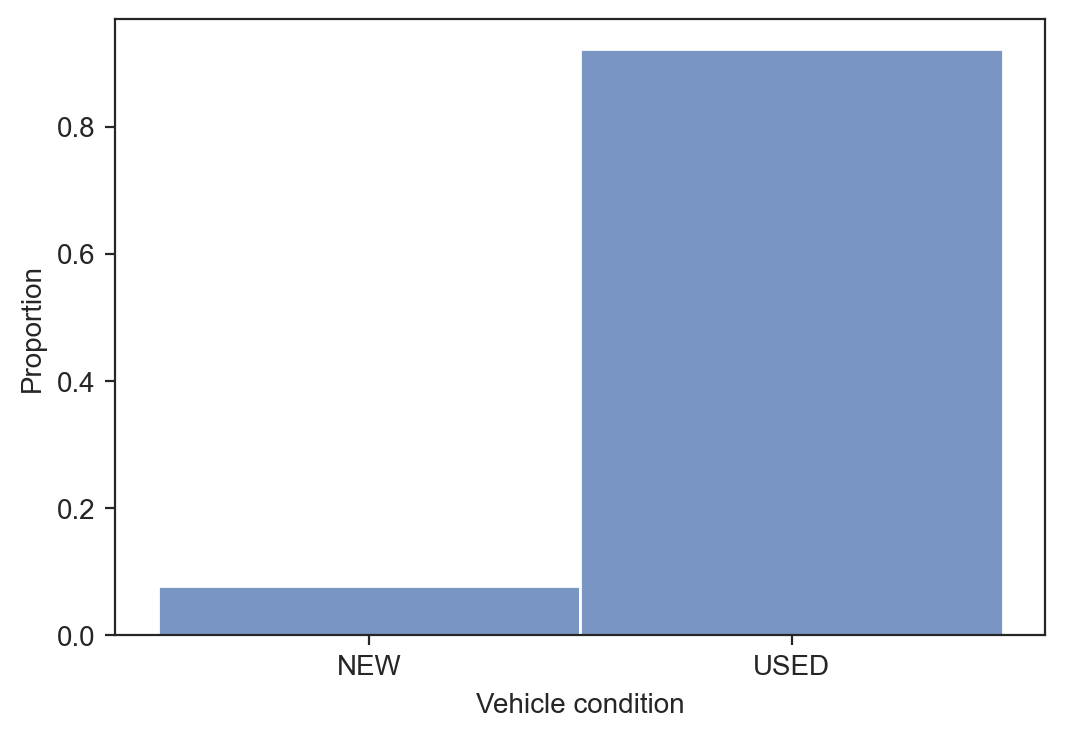

In [38]:
sns.histplot(adv['Vehicle condition'], stat='proportion');
plt.savefig("a.jpeg")

In [39]:
adv.head()

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,2011.0,73970,SUV,False,Petrol Plug-in Hybrid
202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [40]:
adv.dtypes

Mileage                  float64
Regcode                   object
Colour                    object
Make                      object
Model                     object
Vehicle condition         object
Year of Registration     float64
Price                      int64
Bodytype                  object
Crossover car and van       bool
Fueltype                  object
dtype: object

In [41]:
adv = (adv.loc[ adv['Year of Registration']>=1900 ])

In [42]:
adv['Year of Registration'].value_counts().tail(40) # set the treshold from 1986

Year of Registration
1988.0    71
1987.0    50
1986.0    38
1985.0    31
1973.0    29
1970.0    27
1972.0    26
1980.0    24
1971.0    23
1979.0    23
1982.0    21
1969.0    20
1984.0    19
1964.0    18
1968.0    17
1978.0    17
1983.0    16
1976.0    14
1965.0    14
1977.0    13
1981.0    12
1967.0    12
1962.0    10
1974.0     9
1966.0     9
1963.0     8
1961.0     7
1975.0     6
1954.0     5
1957.0     5
1960.0     5
1955.0     4
1933.0     3
1956.0     3
1959.0     3
1958.0     3
1952.0     2
1909.0     1
1934.0     1
1950.0     1
Name: count, dtype: int64

In [43]:
adv = adv[(adv['Year of Registration'] >= 1986)]

In [44]:
adv.loc[[202008242869411]]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202008242869411,3000.0,20,Red,Volvo,XC40,USED,2020.0,29895,SUV,False,Petrol


In [45]:
adv.loc[[202009234085081]]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202009234085081,18107.0,19,Silver,Volkswagen,Golf,USED,2019.0,16000,Hatchback,False,Petrol


In [46]:
adv.loc[[202010104826185]]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010104826185,5972.0,69,White,Vauxhall,Corsa,USED,2019.0,10000,Hatchback,False,Petrol


In [47]:
#adv.loc[[202002067009819]]

In [48]:
adv['Fueltype'].unique()

array(['Petrol Plug-in Hybrid', 'Diesel', 'Petrol', 'Diesel Hybrid',
       'Petrol Hybrid', 'Electric', 'Diesel Plug-in Hybrid', nan,
       'Bi Fuel', 'Natural Gas'], dtype=object)

In [49]:
adv['Fueltype'].value_counts()

Fueltype
Petrol                   216492
Diesel                   158104
Petrol Hybrid             13601
Petrol Plug-in Hybrid      6159
Electric                   4783
Diesel Hybrid              1403
Bi Fuel                     221
Diesel Plug-in Hybrid       185
Natural Gas                   1
Name: count, dtype: int64

In [50]:
adv.loc[ adv['Fueltype']=='Natural Gas']

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010315647990,160000.0,55,White,Iveco,Daily,USED,2005.0,3795,Combi Van,True,Natural Gas


In [51]:
adv['Bodytype'].unique() 

array(['SUV', 'Saloon', 'Hatchback', 'Convertible', 'Limousine', 'Estate',
       'MPV', 'Coupe', nan, 'Pickup', 'Combi Van', 'Panel Van', 'Minibus',
       'Window Van', 'Camper', 'Car Derived Van', 'Chassis Cab'],
      dtype=object)

In [52]:
adv['Bodytype'].value_counts()

Bodytype
Hatchback          167280
SUV                115851
Saloon              36538
Estate              24682
Coupe               23148
MPV                 16026
Convertible         15897
Pickup                610
Combi Van             214
Limousine             157
Minibus               149
Camper                 67
Panel Van              59
Window Van             41
Chassis Cab             3
Car Derived Van         2
Name: count, dtype: int64

In [53]:
(adv.loc[ adv['Bodytype']=='Combi Van' ]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202011015668810,151000.0,59,Black,Volkswagen,Transporter Sportline,USED,2009.0,13000,Combi Van,True,Diesel
202010205209275,149000.0,05,White,Volkswagen,Transporter,USED,2005.0,8200,Combi Van,True,Diesel
202010145004133,96000.0,64,Grey,Volkswagen,Transporter,USED,2014.0,18750,Combi Van,True,Diesel
202008142497419,2658.0,69,White,Peugeot,Boxer,USED,2020.0,20058,Combi Van,False,Diesel
202002107163702,56000.0,62,Gold,Peugeot,Expert Tepee,USED,2012.0,6500,Combi Van,True,Diesel
202008293075951,31700.0,66,Grey,Fiat,Talento,USED,2016.0,13995,Combi Van,True,Diesel
202010215268466,65000.0,15,Grey,Vauxhall,Vivaro,USED,2015.0,23500,Combi Van,True,Diesel
201910163376428,12.0,NaN,Black,Nissan,e-NV200,NEW,2009.0,32990,Combi Van,True,Electric
202010185136529,102000.0,09,Black,Volkswagen,Transporter Sportline,USED,2009.0,13295,Combi Van,True,Diesel


In [54]:
adv.loc[ adv['Bodytype']=='Car Derived Van']

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010175103802,193000.0,13,White,MINI,Clubvan,USED,2013.0,3995,Car Derived Van,True,Diesel
202006290651056,103000.0,NaN,White,Toyota,Granvia,USED,2012.0,10495,Car Derived Van,False,Diesel


In [55]:
adv['Colour'].value_counts()

Colour
Black          86255
White          70482
Grey           68208
Blue           59713
Silver         49291
Red            41929
Green           4470
Orange          4082
Yellow          2087
Brown           2003
Multicolour     1848
Beige           1531
Bronze          1327
Purple          1210
Gold             811
Pink             409
Turquoise        306
Maroon           158
Burgundy          63
Magenta           15
Navy               7
Indigo             1
Name: count, dtype: int64

In [56]:
domain_red = ['Red', 'Burgundy', 'Maroon']
domain_blue = ['Blue', 'Navy', 'Indigo', 'Turquoise']
domain_yellow = ['Yellow', 'Beige']
domain_purple = ['Purple', 'Magenta']

red_map = dict.fromkeys(domain_red, 'Red')
blue_map = dict.fromkeys(domain_blue, 'Blue')
yellow_map = dict.fromkeys(domain_yellow, 'Yellow')
purple_map = dict.fromkeys(domain_purple, 'Purple')
colour_scheme_map = {
    **red_map,
    **blue_map,
    **yellow_map,
    **purple_map,
    'Grey': 'Grey',
    #'Blue': 'Blue',
'Brown':'Brown',
#'Red':'Red',
'Bronze':'Bronze',
'Black':'Black',
'White':'White',
'Silver':'Silver',
#'Purple':'Purple',
'Green':'Green',
'Orange':'Orange',
#'Yellow':'Yellow',
'Gold':'Gold',
'Multicolour':'Multicolour',
'Pink':'Pink'
    

}
adv['Colour'] = adv['Colour'].map(colour_scheme_map)

In [57]:
adv['Colour'].value_counts().tail(50)

Colour
Black          86255
White          70482
Grey           68208
Blue           60027
Silver         49291
Red            42150
Green           4470
Orange          4082
Yellow          3618
Brown           2003
Multicolour     1848
Bronze          1327
Purple          1225
Gold             811
Pink             409
Name: count, dtype: int64

In [58]:
adv['Make'].value_counts().tail(50)

Make
Proton            25
Daimler           21
Caterham          20
Cadillac          15
Daewoo            10
Perodua           10
Hummer             9
LEVC               9
Austin             9
Bugatti            8
Replica            7
Lincoln            7
Westfield          6
Great Wall         6
Iveco              5
GMC                5
Holden             4
Maybach            4
Corvette           4
AC                 3
Ariel              3
Opel               3
Tiger              3
Lancia             2
Triumph            2
Dax                2
Zenos              2
Pilgrim            2
Aixam              2
BAC                2
Noble              2
Panther            1
Bristol            1
Carbodies          1
Reliant            1
Morris             1
Pagani             1
Beauford           1
Ultima             1
Mev                1
Datsun             1
Plymouth           1
AK                 1
Buick              1
Sebring            1
Radical            1
Pontiac            1
Jensen  

In [59]:
adv['Model'].value_counts().tail(50)

Model
Park Ward       1
19              1
Space Wagon     1
DB2             1
President       1
3500            1
Shuttle         1
Riviera         1
Formentor       1
MXR             1
Patrol GR       1
Clubvan         1
Primastar       1
Silver Cloud    1
Pajero Mini     1
Turbo RT        1
Plus Six        1
QX50            1
420             1
YRV             1
Z06             1
QX56            1
Ulysse          1
STS             1
Cuore           1
MX-6            1
Sunny           1
Tribute         1
Replica         1
Tempra          1
MPV             1
Sera            1
240             1
Stagea          1
GS F            1
Maxima QX       1
Crossline       1
340R            1
Airtrek         1
TR6             1
Series 3        1
Syclone         1
Xantia          1
ZT-T            1
EQV             1
126             1
959             1
57              1
Satria          1
480             1
Name: count, dtype: int64

In [60]:
(adv.loc[ adv['Model']== 'Discovery' ])

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010054616217,42333.0,17,Silver,Land Rover,Discovery,USED,2017.0,38990,SUV,False,Diesel
202010215258812,6679.0,68,Black,Land Rover,Discovery,USED,2019.0,54495,SUV,False,Diesel
202007171339614,92235.0,51,Gold,Land Rover,Discovery,USED,2001.0,5495,SUV,False,Diesel
202009284315780,61125.0,67,White,Land Rover,Discovery,USED,2017.0,36000,SUV,False,Diesel
202010134943201,10.0,NaN,Grey,Land Rover,Discovery,NEW,2017.0,69499,SUV,False,Diesel
...,...,...,...,...,...,...,...,...,...,...,...
202010225312729,30000.0,17,Black,Land Rover,Discovery,USED,2017.0,35799,SUV,False,Diesel
202009113606969,33700.0,67,White,Land Rover,Discovery,USED,2018.0,40000,SUV,False,Diesel
202004078885601,4351.0,69,White,Land Rover,Discovery,USED,2020.0,44490,SUV,False,Diesel


In [61]:
adv['Milesperyear'] = adv['Mileage'] / (2020 - adv['Year of Registration']).replace(0, 1)

In [62]:
adv['Crossover car and van'] = adv['Crossover car and van'].astype(int)

In [63]:
(adv.loc[ adv['Crossover car and van']==1 ]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear
public_reference,,,,,,,,,,,,
202006300703207,7066.0,67,Purple,Volkswagen,Caddy Life,USED,2017.0,17975,MPV,1,Petrol,2355.333333
202010275504469,2879.0,20,Black,Nissan,Navara,USED,2020.0,29990,Pickup,1,Diesel,2879.000000
202010285515479,281500.0,06,Silver,Volkswagen,Caravelle,USED,2006.0,7650,MPV,1,Diesel,20107.142857
202011015668810,151000.0,59,Black,Volkswagen,Transporter Sportline,USED,2009.0,13000,Combi Van,1,Diesel,13727.272727
202005209437331,0.0,NaN,Blue,SsangYong,Musso,NEW,2012.0,25631,Pickup,1,Diesel,0.000000
202010074714694,108000.0,06,Silver,Isuzu,Rodeo,USED,2006.0,7500,Pickup,1,Diesel,7714.285714
202008102303002,72252.0,55,Green,Isuzu,Rodeo,USED,2005.0,3750,Pickup,1,Diesel,4816.800000
202008192681009,165000.0,D,Blue,Land Rover,90,USED,1987.0,10489,SUV,1,Diesel,5000.000000
202003017882700,3238.0,69,Silver,Mercedes-Benz,V Class,USED,2019.0,44000,MPV,1,Diesel,3238.000000


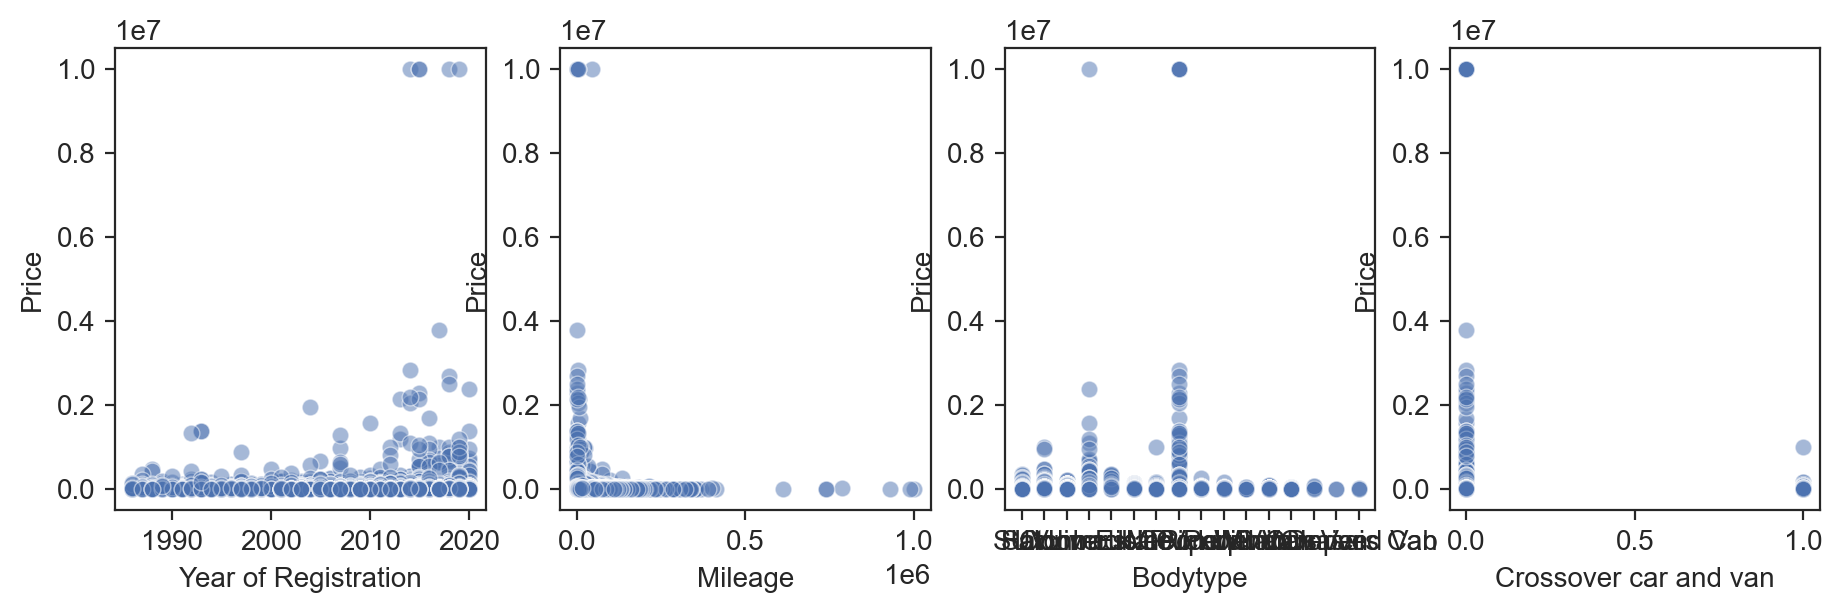

In [64]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(11,3))
sns.scatterplot(data=adv, x='Year of Registration', y='Price', alpha=0.5, ax=axs[0])
sns.scatterplot(data=adv, x='Mileage', y='Price', alpha=0.5, ax=axs[1])
sns.scatterplot(data=adv, x='Bodytype', y='Price', alpha=0.5, ax=axs[2])
sns.scatterplot(data=adv, x='Crossover car and van', y='Price', alpha=0.5, ax=axs[3]);


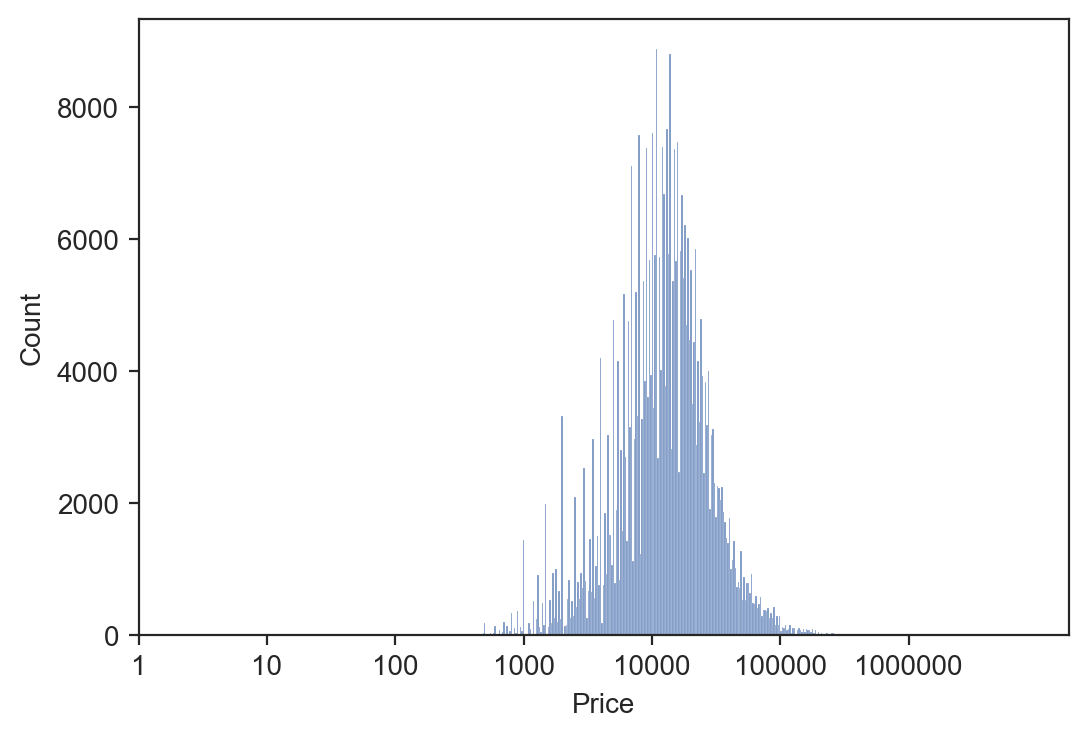

In [67]:
ax = sns.histplot(np.log10(adv.loc[ adv['Price']>0, 'Price']))
ax.set_xticks(range(0,7))
ax.set_xticklabels(np.power(10, range(0,7)));
#appearsto be somewhat normally distributed

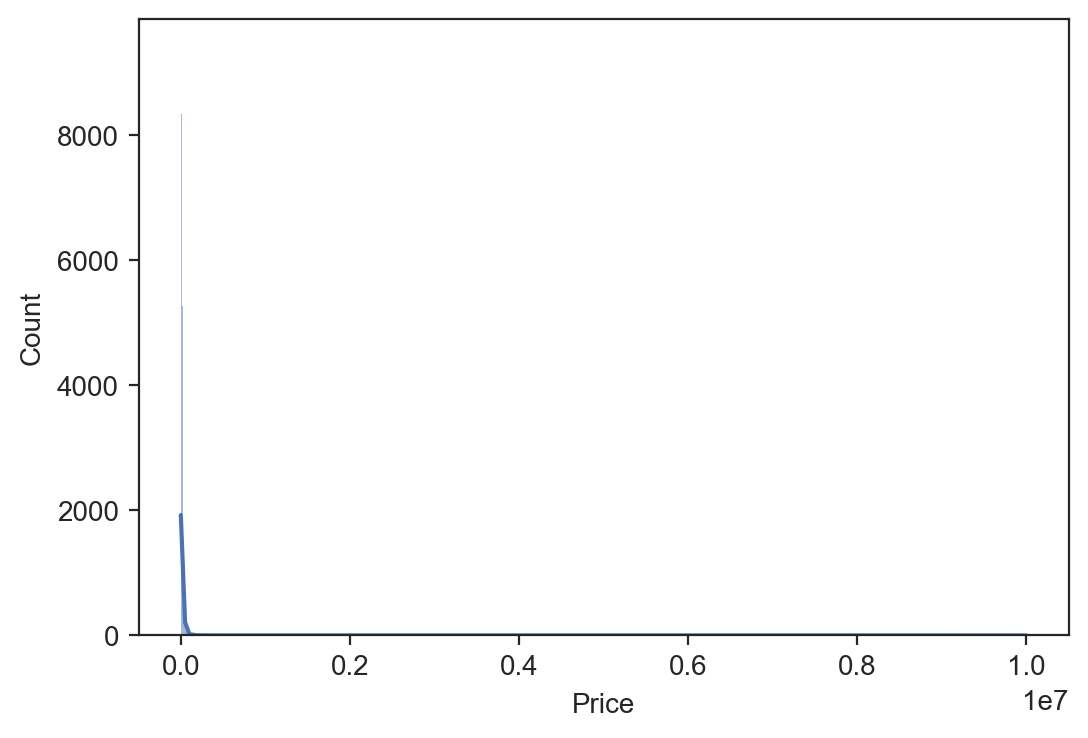

In [68]:
sns.histplot(data=adv.query("Price>100"), x='Price',
             common_norm=False, kde=True);

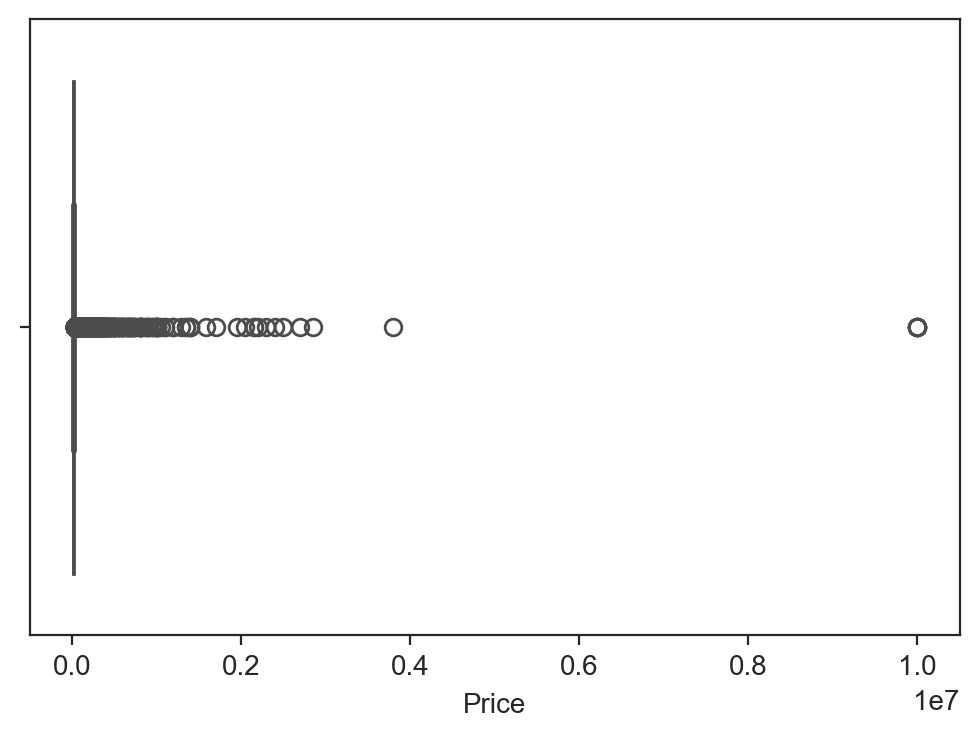

In [69]:
sns.boxplot(data=adv, x='Price');
plt.savefig('box.jpeg')

In [70]:
num_samples = 10000
bootstrap_samples = np.empty((num_samples, len(adv)))
print(bootstrap_samples.shape)

MemoryError: Unable to allocate 29.9 GiB for an array with shape (10000, 401526) and data type float64

In [ ]:
rng = np.random.default_rng(seed=42)

In [ ]:
for i in range(0, num_samples):
    bootstrap_samples[i] = rng.choice(adv['Price'], len(adv))


In [ ]:
bootstrap_means = bootstrap_samples.mean(axis=1)
# just a quick look to see if it makes sense
bootstrap_means[:20], len(bootstrap_means)

In [ ]:
fig, ax = plt.subplots(figsize=(7,3))
ax = sns.histplot(x=bootstrap_means, stat='proportion', bins=20)
sns.rugplot(x=bootstrap_means, ax=ax, color="aqua", height=0.05, linewidth=0.5);

ax.axvline(bootstrap_means.mean(), color="lightsalmon", linewidth=0.5)
ax.axvline(np.percentile(bootstrap_means, 2.5), color="fuchsia", linewidth=0.5)
ax.axvline(np.percentile(bootstrap_means, 50), color="fuchsia", linewidth=0.5)
ax.axvline(np.percentile(bootstrap_means, 97.5), color="fuchsia", linewidth=0.5)

In [ ]:
#So, these are the mean and the confidence interval (at 95% level) of
print(adv['Price'].mean())
print(np.percentile(bootstrap_means, 2.5))
print(np.percentile(bootstrap_means, 97.5))
print(np.percentile(bootstrap_means, 50))

In [ ]:
pq005 = adv['Price'].quantile(0.025)
pq995 = adv['Price'].quantile(0.975)
print(pq005,pq995)

In [71]:
adv.sort_values(['Price'], ascending=[False]).head(100)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear
public_reference,,,,,,,,,,,,
202009103539048,100.0,NaN,Grey,Maserati,3500,USED,2018.0,9999999,Convertible,0,Petrol,50.000000
202001226429470,950.0,NaN,Black,Ferrari,LaFerrari,USED,2015.0,9999999,Coupe,0,Petrol,190.000000
202006180262926,4400.0,NaN,White,Porsche,959,USED,2015.0,9999999,Coupe,0,Petrol,880.000000
201812223434109,3600.0,NaN,Grey,Lamborghini,Miura,USED,2014.0,9999999,Coupe,0,Petrol,600.000000
202008112331147,46300.0,NaN,Blue,Ferrari,275,USED,2019.0,9999999,Coupe,0,Petrol,46300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
202006300684047,286.0,17,NaN,McLaren,675LT,USED,2017.0,449990,Convertible,0,Petrol,95.333333
201908080939230,38100.0,E,Red,Aston Martin,V8,USED,1988.0,445000,Convertible,0,Petrol,1190.625000
202005299637905,1942.0,J,Red,Jaguar,XJ220,USED,1992.0,445000,Coupe,0,Petrol,69.357143


In [72]:
ci1 = adv[(adv['Price'] >= pq005) & (adv['Price'] <= pq995)] #95% ci

NameError: name 'pq005' is not defined

In [73]:
sns.boxplot(data=ci1, x='Price');
#5% confidence interval

NameError: name 'ci1' is not defined

In [74]:
pq006 = adv['Price'].quantile(0.005)
pq996 = adv['Price'].quantile(0.995)
print(pq006,pq996)

899.0 119950.0


In [75]:
ci2 = adv[(adv['Price'] >= pq005) & (adv['Price'] <= pq996)] #99% ci

NameError: name 'pq005' is not defined

In [76]:
sns.boxplot(data=ci2, x='Price');

NameError: name 'ci2' is not defined

In [77]:
pq007 = adv['Price'].quantile(0.0005)
pq997 = adv['Price'].quantile(0.9995)
print(pq007,pq997)

495.0 299950.0


In [78]:
ci3 = adv[(adv['Price'] >= pq007) & (adv['Price'] <= pq997)] #99.9% ci

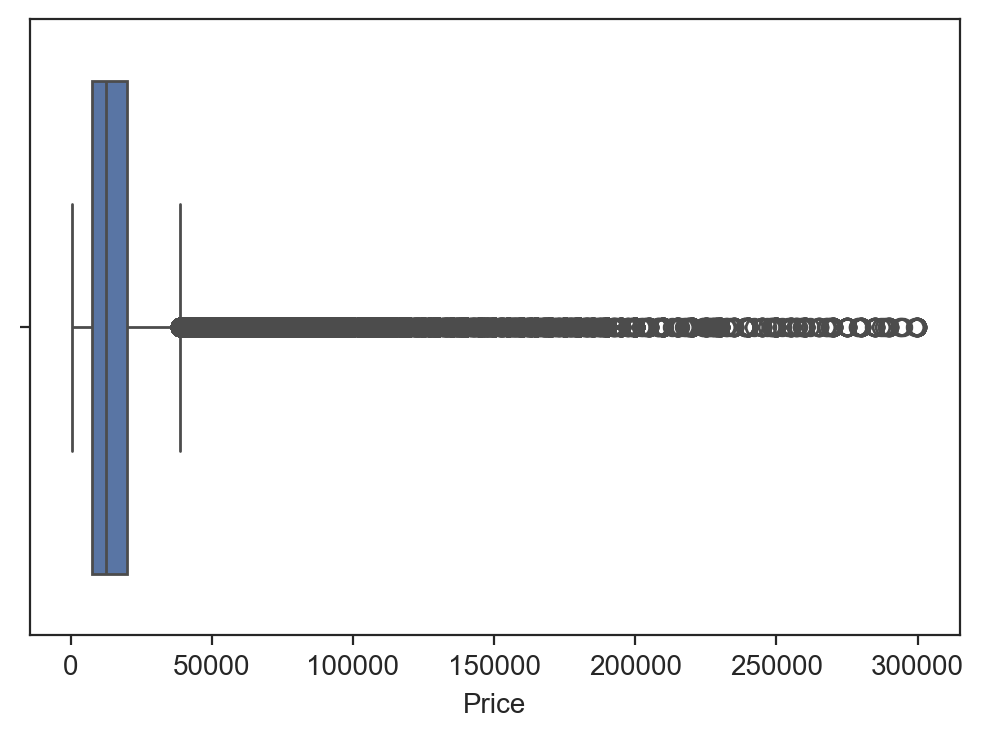

In [79]:
sns.boxplot(data=ci3, x='Price');

In [80]:
adv = adv[(adv['Price'] >= pq005) & (adv['Price'] <= pq995)] 
print(pq005,pq995)

NameError: name 'pq005' is not defined

In [ ]:
sns.boxplot(data=adv, x='Price');
plt.title('Boxplot of price')
plt.xlabel("Price (Pounds)")
plt.savefig('boxsfs.jpeg')


In [ ]:
adv['Price'].describe().loc[['min', '25%', '50%', '75%', 'max']]

In [81]:
adv.sort_values(['Price'], ascending=[False]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear
public_reference,,,,,,,,,,,,
202009103539048,100.0,NaN,Grey,Maserati,3500,USED,2018.0,9999999,Convertible,0,Petrol,50.000000
202001226429470,950.0,NaN,Black,Ferrari,LaFerrari,USED,2015.0,9999999,Coupe,0,Petrol,190.000000
202006180262926,4400.0,NaN,White,Porsche,959,USED,2015.0,9999999,Coupe,0,Petrol,880.000000
201812223434109,3600.0,NaN,Grey,Lamborghini,Miura,USED,2014.0,9999999,Coupe,0,Petrol,600.000000
202008112331147,46300.0,NaN,Blue,Ferrari,275,USED,2019.0,9999999,Coupe,0,Petrol,46300.000000
202008252907180,300.0,17,NaN,Ferrari,LaFerrari,USED,2017.0,3799995,NaN,0,NaN,100.000000
202002257718775,4400.0,14,Black,Bugatti,Veyron,USED,2014.0,2850000,Coupe,0,Petrol,733.333333
202006039766650,189.0,NaN,Black,McLaren,P1,USED,2018.0,2695000,Coupe,0,Petrol Plug-in Hybrid,94.500000
202007081011555,1000.0,67,Blue,Bugatti,Chiron,USED,2018.0,2500000,Coupe,0,Petrol,500.000000


In [82]:
max_price = adv['Price'].max()
min_price = adv['Price'].min()

In [83]:
sdd = adv['Price'].quantile(0.875)
print(sdd)

28850.0


In [84]:
adv['Category'] = pd.cut(
    adv['Price'],
    bins=[min_price, 7750.00, 12599.00, 19600.00, 26991.0, max_price+0.1],
    labels=['Cheap', 'Lower', 'Medium', 'Upper','Expensive'],
    right=False, 
    include_lowest=True)

In [85]:
adv.columns

Index(['Mileage', 'Regcode', 'Colour', 'Make', 'Model', 'Vehicle condition',
       'Year of Registration', 'Price', 'Bodytype', 'Crossover car and van',
       'Fueltype', 'Milesperyear', 'Category'],
      dtype='object')

In [86]:
adv.sample(5)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Category
public_reference,,,,,,,,,,,,,
202006140114057,60892.0,65,Grey,Land Rover,Range Rover Sport,USED,2015.0,31591,SUV,0,Diesel,12178.400000,Expensive
202010225287619,13799.0,68,Grey,Vauxhall,Grandland X,USED,2018.0,14000,SUV,0,Petrol,6899.500000,Medium
202010205217311,15440.0,19,White,Peugeot,208,USED,2019.0,10490,Hatchback,0,Petrol,15440.000000,Lower
202009103546451,59000.0,63,Black,Audi,A7,USED,2013.0,14750,Hatchback,0,Diesel,8428.571429,Medium
202009103565682,3836.0,19,NaN,Citroen,C1,USED,2019.0,10490,Hatchback,0,Petrol,3836.000000,Lower


In [87]:
adv['Vehicle condition'] = adv['Vehicle condition'].replace('USED', '0')
adv['Vehicle condition'] = adv['Vehicle condition'].replace('NEW', '1')

In [88]:
adv['Vehicle condition'] = adv['Vehicle condition'].astype(int)

In [89]:
adv["AvgModelUsed"] = adv[adv['Vehicle condition'] == 0].groupby(['Model'])['Price'].transform('mean')

In [90]:
adv["AvgModelUsed"] = adv["AvgModelUsed"].fillna(adv.groupby('Model')['AvgModelUsed'].transform("mean"))

In [91]:
adv["AvgModelUsed"].describe().loc[['min', '25%', '50%', '75%', 'max']]

min    4.950000e+02
25%    8.761359e+03
50%    1.272768e+04
75%    1.818697e+04
max    9.999999e+06
Name: AvgModelUsed, dtype: float64

In [92]:
adv["AvgModelNew"] = adv[adv['Vehicle condition'] == 1].groupby(['Model'])['Price'].transform('mean')

In [93]:
adv["AvgModelNew"] = adv["AvgModelNew"].fillna(adv.groupby("Model")['AvgModelNew'].transform("mean"))

In [94]:
adv["AvgModelNew"].describe().loc[['min', '25%', '50%', '75%', 'max']]

min      9512.260417
25%     21254.368421
50%     26516.515152
75%     38635.151515
max    183198.000000
Name: AvgModelNew, dtype: float64

In [95]:
adv["AvgMakeNew"] = adv[adv['Vehicle condition'] == 1].groupby(['Make'])['Price'].transform('mean')

In [96]:
adv["AvgMakeNew"] = adv["AvgMakeNew"].fillna(adv.groupby("Make")['AvgMakeNew'].transform("mean"))

In [97]:
adv["AvgMakeNew"].describe().loc[['min', '25%', '50%', '75%', 'max']]

min    14444.967857
25%    23496.605464
50%    25455.058239
75%    47108.668668
max    74245.000000
Name: AvgMakeNew, dtype: float64

In [98]:
adv["AvgMakeUsed"] = adv[adv['Vehicle condition'] == 0].groupby(['Make'])['Price'].transform('mean')

In [99]:
adv["AvgMakeUsed"] = adv["AvgMakeUsed"].fillna(adv.groupby("Make")['AvgMakeUsed'].transform("mean"))

In [100]:
adv["AvgMakeUsed"].describe().loc[['min', '25%', '50%', '75%', 'max']]

min    7.727000e+02
25%    1.059248e+04
50%    1.234608e+04
75%    1.837804e+04
max    2.400000e+06
Name: AvgMakeUsed, dtype: float64

In [101]:
adv.sample(5)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Category,AvgModelUsed,AvgModelNew,AvgMakeNew,AvgMakeUsed
public_reference,,,,,,,,,,,,,,,,,
202010034564746,11905.0,19,White,Volkswagen,Tiguan,0,2019.0,22995,SUV,0,Petrol,11905.000000,Upper,18427.002864,30430.034247,25083.754628,13039.551604
202003238706760,3000.0,69,Blue,Vauxhall,Grandland X,0,2019.0,20990,SUV,0,Diesel,3000.000000,Upper,16891.256308,29870.648780,21866.669734,7769.073075
202010084740580,5031.0,68,Grey,Toyota,AYGO,0,2018.0,9000,Hatchback,0,Petrol,2515.500000,Lower,6491.328301,12198.608696,26418.514076,10667.204701
202010104829979,19091.0,17,Grey,Volkswagen,Scirocco,0,2017.0,18500,Coupe,0,Diesel,6363.666667,Medium,11697.996237,NaN,25083.754628,13039.551604
202006220405913,6900.0,69,Blue,MINI,Hatch,0,2019.0,17395,Hatchback,0,Petrol,6900.000000,Medium,11248.508144,23538.298343,26424.092262,11895.681690


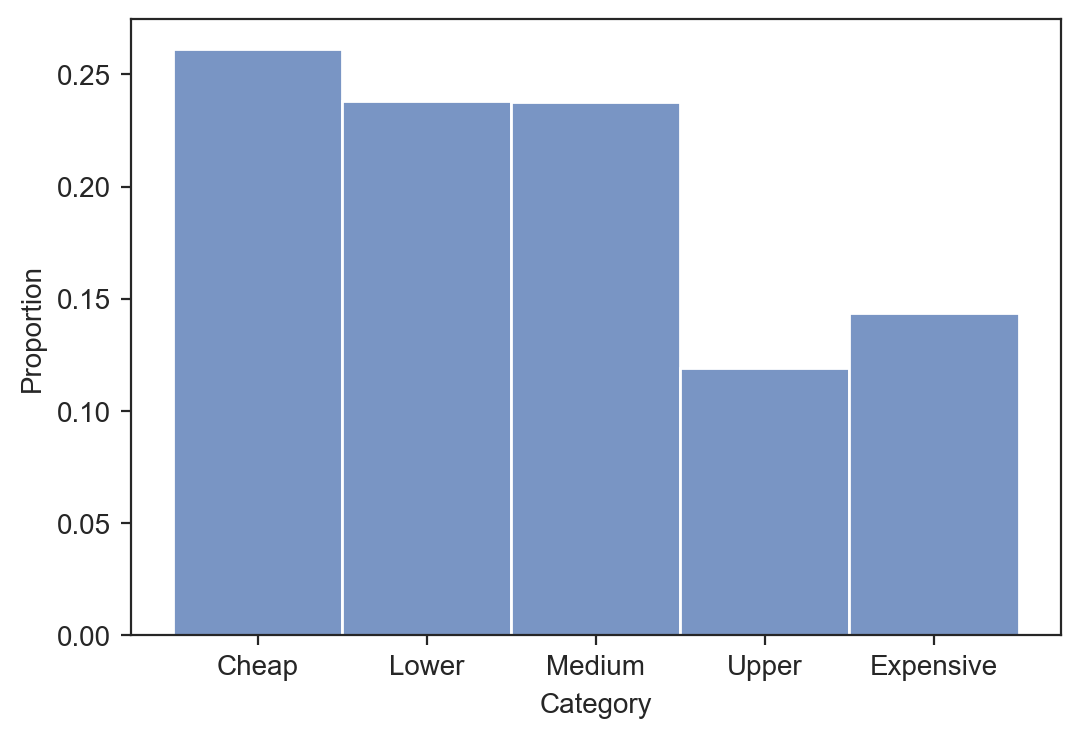

In [102]:
sns.histplot(adv['Category'], stat='proportion');
#reason we are going to do cars by make and not actual price is that different factors can determine the price - 

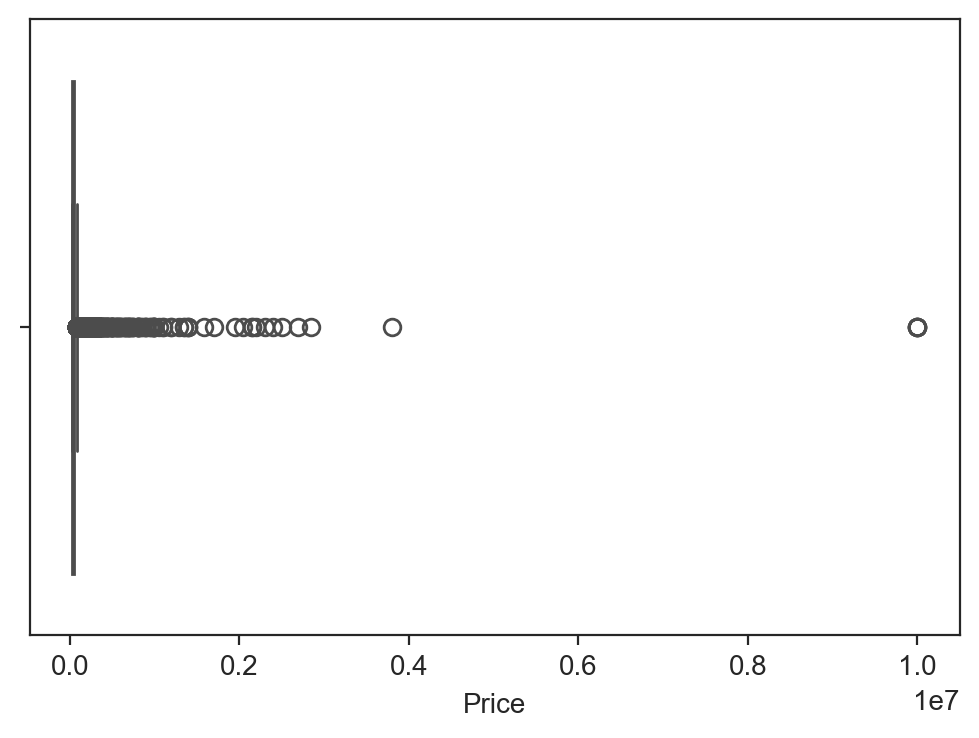

In [103]:
sns.boxplot(data=(adv.loc[ adv['Category']=='Expensive']), x='Price');
#going to have to reduce distribution even further

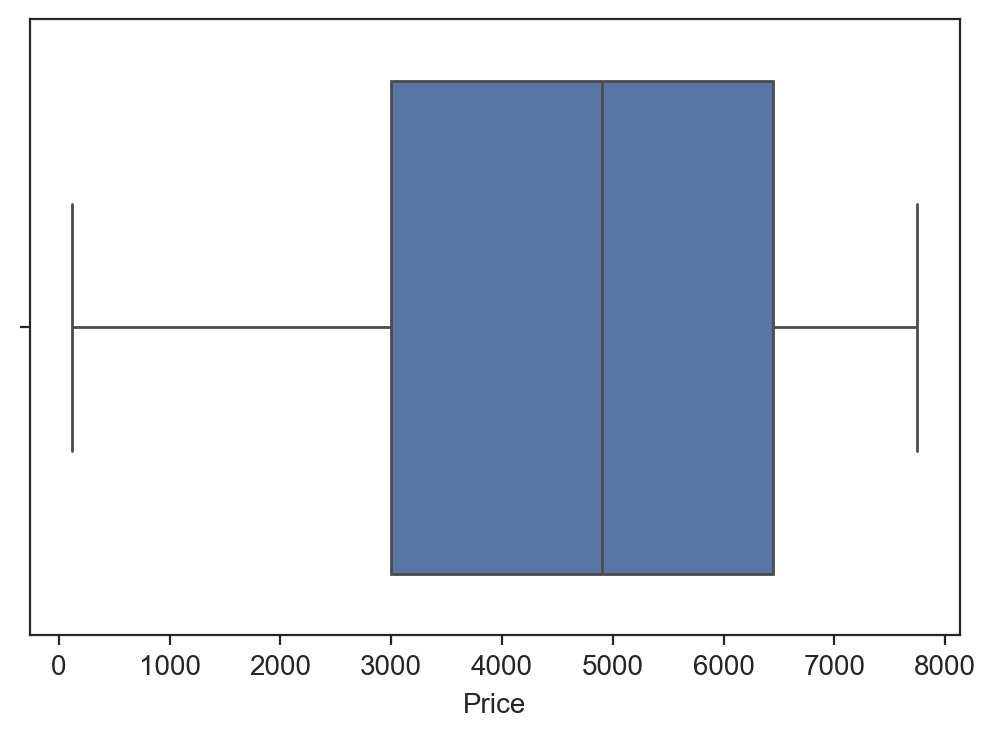

In [104]:
sns.boxplot(data=(adv.loc[ adv['Category']=='Cheap']), x='Price');

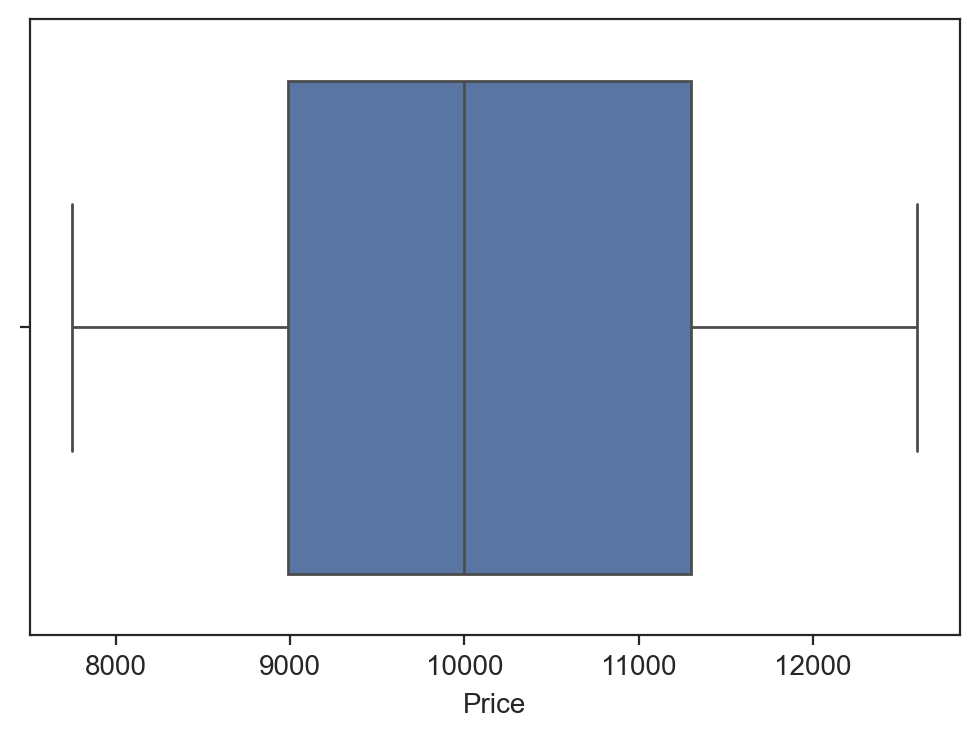

In [105]:
sns.boxplot(data=(adv.loc[ adv['Category']=='Lower']), x='Price');

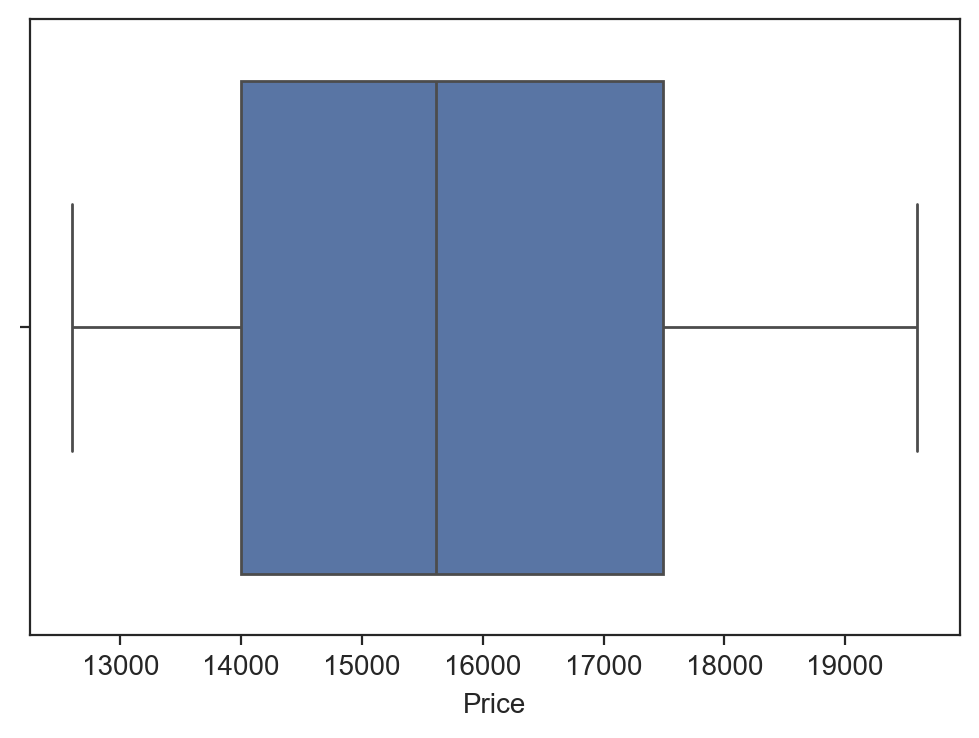

In [106]:
sns.boxplot(data=(adv.loc[ adv['Category']=='Medium']), x='Price');

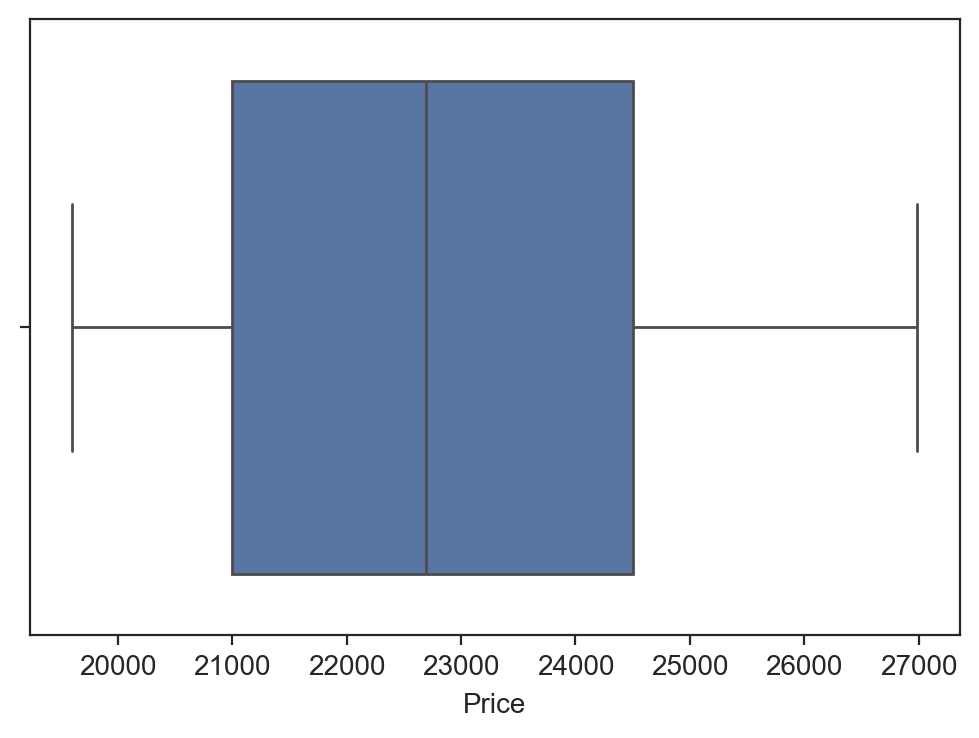

In [107]:
sns.boxplot(data=(adv.loc[ adv['Category']=='Upper']), x='Price');

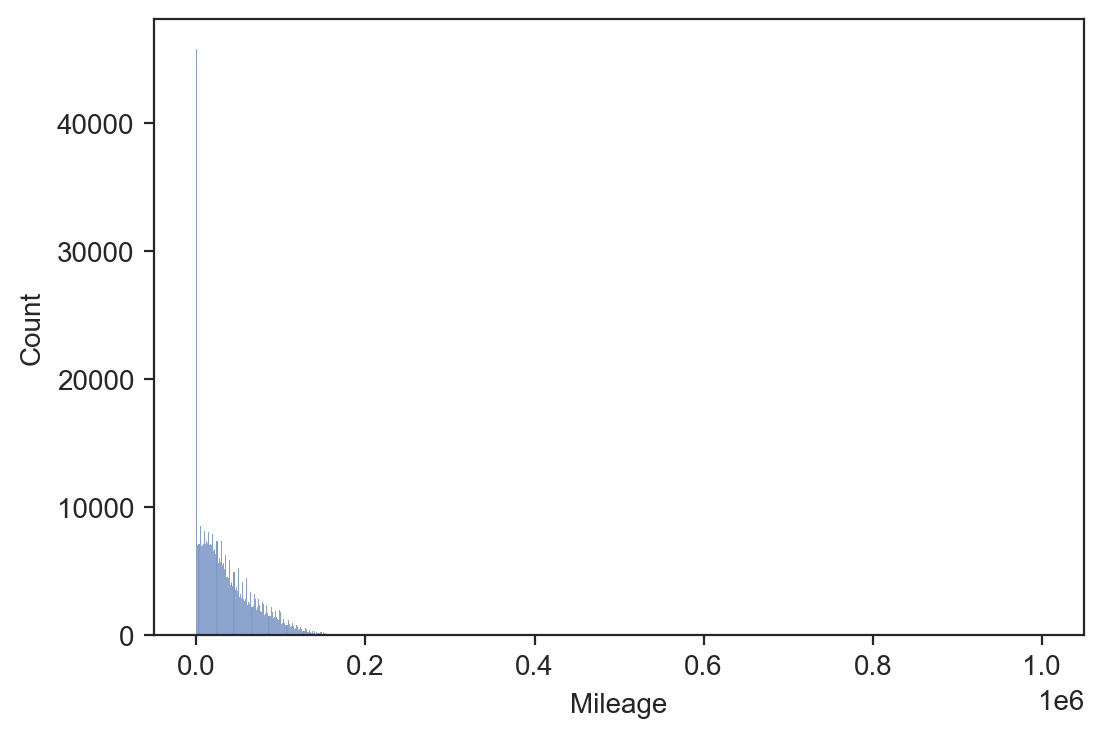

In [108]:
sns.histplot(data=adv, x='Mileage');

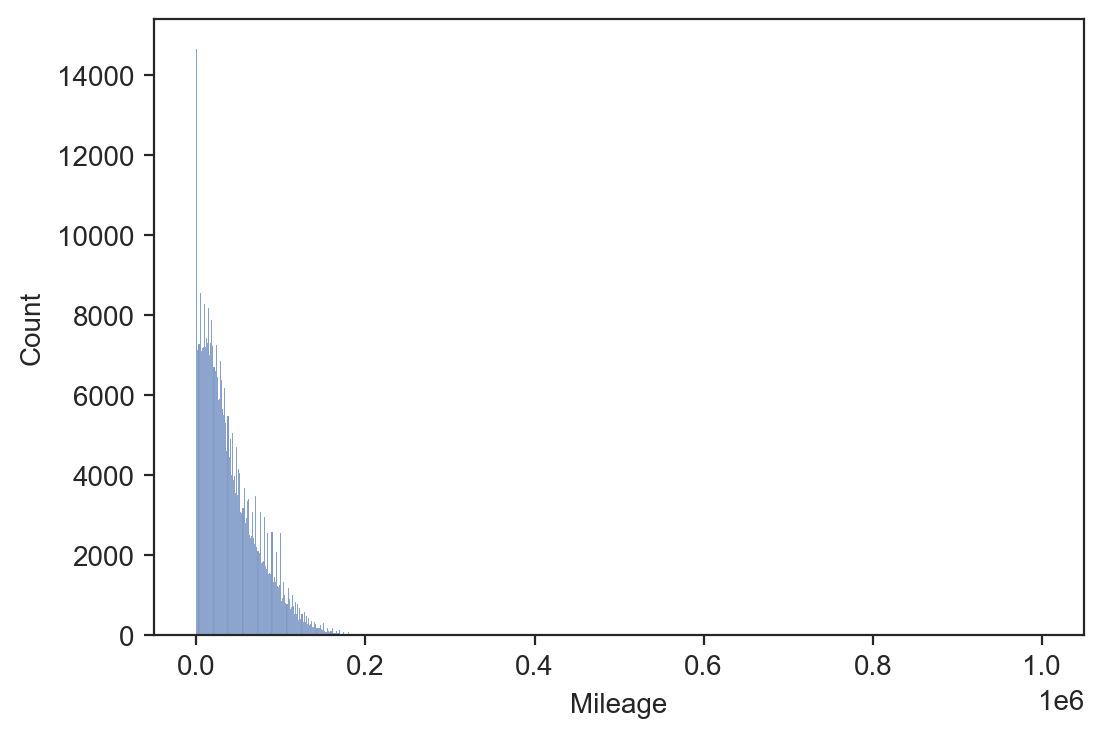

In [109]:
sns.histplot(data=(adv.loc[ adv['Vehicle condition']==0]), x='Mileage');

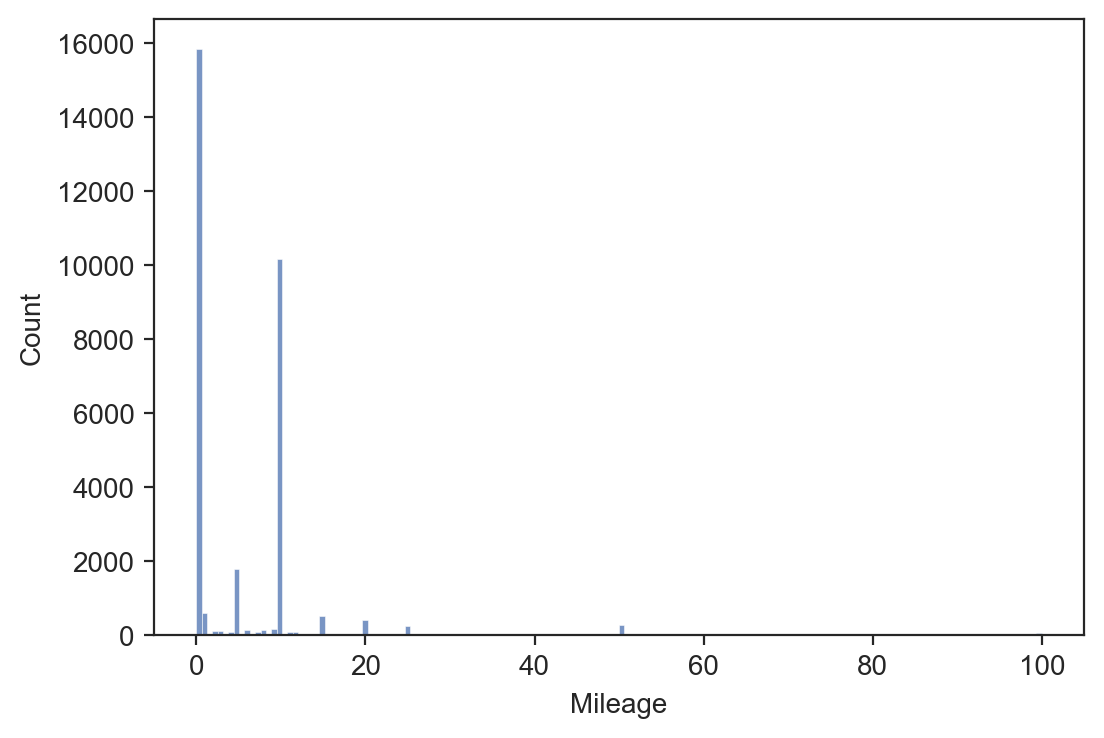

In [110]:
sns.histplot(data=(adv.loc[ adv['Vehicle condition']==1]), x='Mileage');
#cars that have 25 milegage are still classified as new. this lets us know that vehicle condition is not based off number of miles drivien but if the car has bee owned before


In [111]:
new_cars = (adv.loc[ adv['Vehicle condition']==1])

In [112]:
used_cars = (adv.loc[ adv['Vehicle condition']==0])

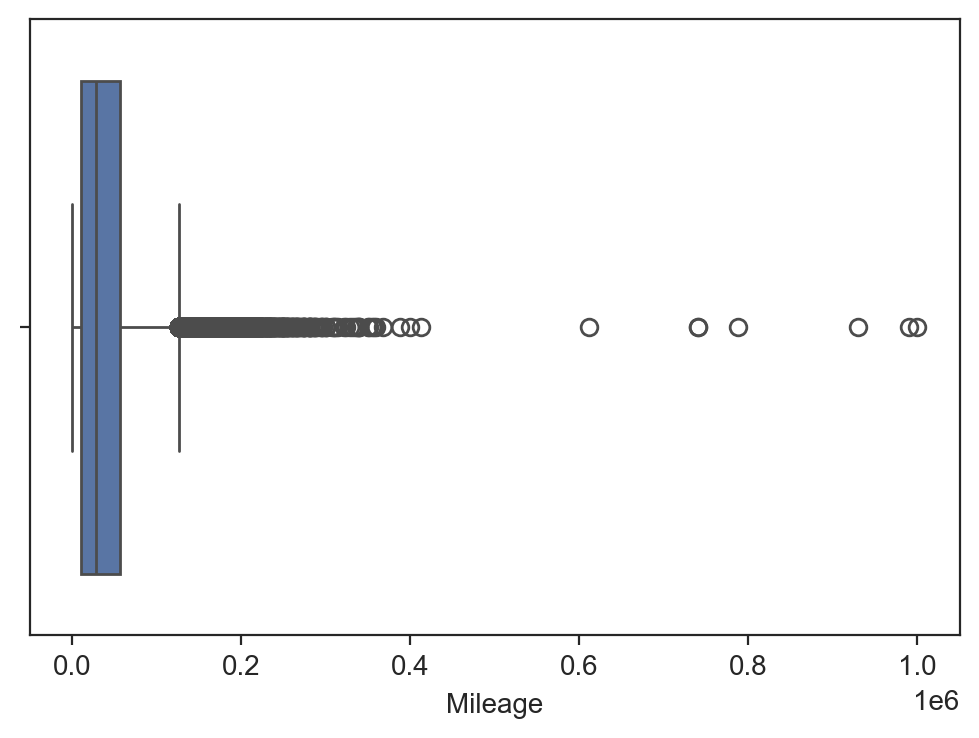

In [113]:
sns.boxplot(data=adv, x='Mileage');

In [114]:
adv.sort_values(['Mileage'], ascending=[False]).head(70)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Category,AvgModelUsed,AvgModelNew,AvgMakeNew,AvgMakeUsed
public_reference,,,,,,,,,,,,,,,,,
202008122406434,999999.0,63,White,Vauxhall,Astra,0,2013.0,9999,Hatchback,0,Diesel,142857.000000,Lower,7532.005007,19314.638889,21866.669734,7769.073075
202010235350884,990000.0,07,Red,Vauxhall,Zafira,0,2007.0,1200,MPV,0,Diesel,76153.846154,Cheap,2927.669706,NaN,21866.669734,7769.073075
202010285542410,930000.0,56,Blue,BMW,1 Series,0,2006.0,2500,Hatchback,0,Petrol,66428.571429,Cheap,12727.681516,31220.186813,54452.703331,18378.042909
202010064664710,788072.0,68,Blue,MINI,Countryman,0,2018.0,22875,SUV,0,Petrol,394036.000000,Upper,14511.001742,31498.220339,26424.092262,11895.681690
202009244163289,740000.0,11,White,Mercedes-Benz,E Class,0,2011.0,10500,Convertible,0,Diesel,82222.222222,Lower,19398.300019,50528.382353,43961.294872,20608.798081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202006160184142,265000.0,56,Silver,Toyota,Land Cruiser Amazon,0,2006.0,11490,SUV,0,Diesel,18928.571429,Lower,16008.970588,NaN,26418.514076,10667.204701
202008313129537,264000.0,Y,Silver,Mercedes-Benz,SLK,0,2001.0,1200,Convertible,0,Petrol,13894.736842,Cheap,9521.898515,NaN,43961.294872,20608.798081
202010175126300,264000.0,R,Green,Toyota,Land Cruiser Colorado,0,1999.0,1995,SUV,0,Diesel,12571.428571,Cheap,5195.000000,NaN,26418.514076,10667.204701


In [115]:
#So, these are the mean and the confidence interval (at 95% level) of
print(adv['Price'].mean())
print(np.percentile(bootstrap_means, 2.5))
print(np.percentile(bootstrap_means, 97.5))
print(np.percentile(bootstrap_means, 50))

17256.717921130887


NameError: name 'bootstrap_means' is not defined

In [ ]:
m007 = adv['Mileage'].quantile(0.0005)
m997 = adv['Mileage'].quantile(0.9995)
print(m007,m997)
mi3 = adv[(adv['Price'] <= pq997)]

In [ ]:
m006 = adv['Mileage'].quantile(0.005)
m996 = adv['Mileage'].quantile(0.995)
print(m006,m996)

In [ ]:
adv = (adv.loc[ adv['Mileage']<=m996])

In [ ]:
sns.boxplot(data=adv, x='Mileage');

In [ ]:
sns.histplot(data=adv, x='Milesperyear');
#appeas somewhat normally distrubted where values arent 0
#may need to remove 0

In [ ]:
sns.boxplot(data=adv, x='Milesperyear');

In [ ]:

sns.histplot(data=adv.query("Milesperyear>10"), x='Milesperyear',
             common_norm=False, kde=True);


In [ ]:
adv.sample(5) 

In [ ]:
adv['Age'] = (2020 - adv['Year of Registration']).replace(0, 1)

In [ ]:
features_to_corr = [ "Mileage",
        "Year of Registration",
        "Vehicle condition",
        "Price", 'Age',
                    "Milesperyear", 'AvgModelUsed',
       'AvgModelNew', 'AvgMakeNew',
       'AvgMakeUsed'
                
                   ]

In [ ]:
plt.subplots(figsize=(8,6))
sns.heatmap(adv[features_to_corr].corr(), cmap="YlGnBu", annot=True)
plt.tight_layout()
plt.savefig('heatmap1.jpeg')

In [ ]:
ewe = adv.groupby('Year of Registration')['Price'].mean()

In [ ]:
ewe.head(5)

In [ ]:
ewe = ewe.reset_index()

In [ ]:
ewe = ewe.set_index('Year of Registration')

In [ ]:
ewe.head(50)

In [ ]:
ax = ewe['Price'].plot.line(marker='o', legend=False, color='blue', linestyle='solid', markerfacecolor='blue')
ax.set_title('Average Car Price Per Year')
ax.set_xlabel('Year of Registration')
ax.set_ylabel('Price (Pounds)');
plt.xlim(1994, 2021)
plt.savefig('adad.jpeg')

In [ ]:
#categorical quantitative

In [ ]:
df = pd.DataFrame(adv.groupby(['Colour'])['Price'].mean().sort_values(ascending = False))
df.plot.bar(color='purple', legend=False,)
plt.title('Colour vs Average Price')
plt.xlabel("Colours")
plt.ylabel("Average Price (Pounds)");
plt.savefig('sfdss.jpeg', dpi=300, bbox_inches = "tight")
plt.show()

In [ ]:
plt.figure(figsize=(25, 6))

df = pd.DataFrame(adv.groupby(['Fueltype'])['Price'].mean().sort_values(ascending = False))
df.plot.bar()
plt.title('Fuel Type vs Average Price')
plt.xlabel("Fuel Type")
plt.ylabel("Average Price (Pounds)")
#plt.tight_layout()
plt.savefig('sads.jpeg', dpi=300, bbox_inches = "tight")



In [ ]:
ad3 = adv.groupby('Make')['Mileage'].mean()
ad3.head(5)

In [ ]:
ad4 = adv.groupby('Make')['Price'].mean()
ad4.head(5)

In [ ]:
Carmake = pd.concat([ad4, ad3], axis='columns')
Carmake

In [ ]:
Carmake = Carmake.reset_index()

In [ ]:
Carmake.columns

In [ ]:
Carmake = Carmake.set_axis([
    'Make', 'Price', 'AvgMileage'
], axis='columns')

In [ ]:
Carmake.head(10) 

In [116]:
#create scatter plot of x vs. y
ax = Carmake.plot(kind='scatter', x='AvgMileage', y='Price')
ax.set_title('Average Price vs Average Mileage')
ax.set_xlabel('AvgMileage')
ax.set_ylabel('Price (Pounds)');
#label each point in scatter plot
for idx, row in Carmake.iterrows():
    ax.annotate(row['Make'], (row['AvgMileage'], row['Price']))
    #https://www.statology.org/pandas-scatter-plot-label-points/
#this works for standard_makes

NameError: name 'Carmake' is not defined

In [117]:
ad6 = adv.groupby('Model')['AvgModelNew'].mean()
ad6.head(5)

Model
1 Series    31220.186813
100                  NaN
1007                 NaN
106                  NaN
107                  NaN
Name: AvgModelNew, dtype: float64

In [118]:
ad7 = adv.groupby('Model')['AvgModelUsed'].mean()
ad7.head(5)

Model
1 Series    12727.681516
100          1999.000000
1007         1366.100000
106          1910.200000
107          2710.193256
Name: AvgModelUsed, dtype: float64

In [119]:
ad8 = adv.groupby('Model')['Mileage'].mean()
ad8.head(5)

Model
1 Series    45292.232524
100         25014.000000
1007        57065.450000
106         68578.100000
107         59987.272374
Name: Mileage, dtype: float64

In [120]:
Carmodel = pd.concat([ad7, ad6, ad8], axis='columns')
Carmodel.head(50)

,AvgModelUsed,AvgModelNew,Mileage
Model,,,
1 Series,1.272768e+04,31220.186813,45292.232524
100,1.999000e+03,NaN,25014.000000
1007,1.366100e+03,NaN,57065.450000
106,1.910200e+03,NaN,68578.100000
107,2.710193e+03,NaN,59987.272374
108,6.755648e+03,10894.629213,18941.982906
11,2.097500e+03,NaN,90704.750000
110,1.217312e+04,NaN,104789.125000
124 Spider,1.607845e+04,NaN,15286.376712


In [121]:
Carmodel['differences'] = Carmodel['AvgModelNew']- Carmodel['AvgModelUsed']

In [122]:
Carmodel.head(50)

,AvgModelUsed,AvgModelNew,Mileage,differences
Model,,,,
1 Series,1.272768e+04,31220.186813,45292.232524,18492.505298
100,1.999000e+03,NaN,25014.000000,NaN
1007,1.366100e+03,NaN,57065.450000,NaN
106,1.910200e+03,NaN,68578.100000,NaN
107,2.710193e+03,NaN,59987.272374,NaN
108,6.755648e+03,10894.629213,18941.982906,4138.981053
11,2.097500e+03,NaN,90704.750000,NaN
110,1.217312e+04,NaN,104789.125000,NaN
124 Spider,1.607845e+04,NaN,15286.376712,NaN


In [123]:
Carmodel = Carmodel.reset_index()

In [124]:
Carmodel.columns

Index(['Model', 'AvgModelUsed', 'AvgModelNew', 'Mileage', 'differences'], dtype='object')

In [125]:
Carmodel = Carmodel.set_axis([
    'Model', 'AvgModelUsed', 'AvgModelNew', 'AvgMileage', 'Differences'
], axis='columns')

In [126]:
Carmodel.sample(5)

,Model,AvgModelUsed,AvgModelNew,AvgMileage,Differences
199,Alpina B7,5.599700e+04,NaN,18765.000000,NaN
44,275,9.999999e+06,NaN,46300.000000,NaN
477,G,1.258667e+04,NaN,42381.666667,NaN
200,Alpina D3,8.352636e+03,NaN,109590.909091,NaN
23,2 Series Gran Coupe,3.050725e+04,34046.0,1758.662921,3538.75


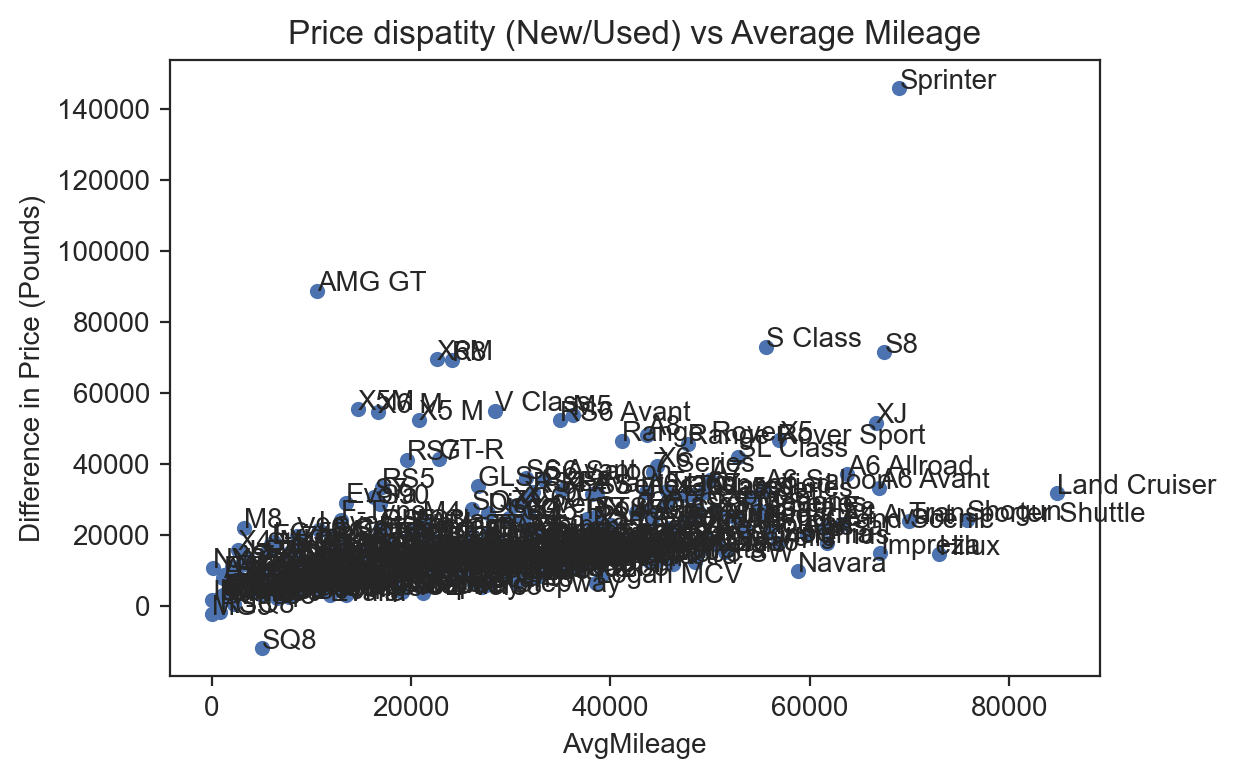

In [127]:
#create scatter plot of x vs. y
ax = Carmodel.plot(kind='scatter', x='AvgMileage', y='Differences')
ax.set_title('Price dispatity (New/Used) vs Average Mileage')
ax.set_xlabel('AvgMileage')
ax.set_ylabel('Difference in Price (Pounds)');
#label each point in scatter plot
for idx, row in Carmodel.iterrows():
    ax.annotate(row['Model'], (row['AvgMileage'], row['Differences']))
    #https://www.statology.org/pandas-scatter-plot-label-points/
#which cars retain the most value
#cannot be done for car manufacturers as may be more used supercars than new budget cars


In [128]:
sds = (adv
 .groupby(['Year of Registration', 'Vehicle condition'])
 .size()
)
sds

Year of Registration  Vehicle condition
1986.0                0                       37
                      1                        1
1987.0                0                       43
                      1                        7
1988.0                0                       68
                                           ...  
2018.0                1                     4140
2019.0                0                    39490
                      1                     5168
2020.0                0                    28880
                      1                     5481
Length: 69, dtype: int64

In [129]:
sds1 = (adv
 .groupby(['Year of Registration'])
 .size()
)
sds1

Year of Registration
1986.0       38
1987.0       50
1988.0       71
1989.0       83
1990.0       80
1991.0       89
1992.0       82
1993.0       73
1994.0      112
1995.0      117
1996.0      154
1997.0      226
1998.0      265
1999.0      313
2000.0      464
2001.0      713
2002.0     1132
2003.0     1806
2004.0     2640
2005.0     3546
2006.0     4976
2007.0     6974
2008.0     7607
2009.0     9522
2010.0    11431
2011.0    13351
2012.0    16205
2013.0    20338
2014.0    25248
2015.0    31156
2016.0    46827
2017.0    74155
2018.0    42663
2019.0    44658
2020.0    34361
dtype: int64

In [130]:
sds2 = sds / sds1 
sds2.tail(50)

Year of Registration  Vehicle condition
1996.0                0                    0.961039
                      1                    0.038961
1997.0                0                    0.951327
                      1                    0.048673
1998.0                0                    0.943396
                      1                    0.056604
1999.0                0                    0.942492
                      1                    0.057508
2000.0                0                    0.969828
                      1                    0.030172
2001.0                0                    0.953717
                      1                    0.046283
2002.0                0                    0.964664
                      1                    0.035336
2003.0                0                    0.965116
                      1                    0.034884
2004.0                0                    0.954545
                      1                    0.045455
2005.0                0 

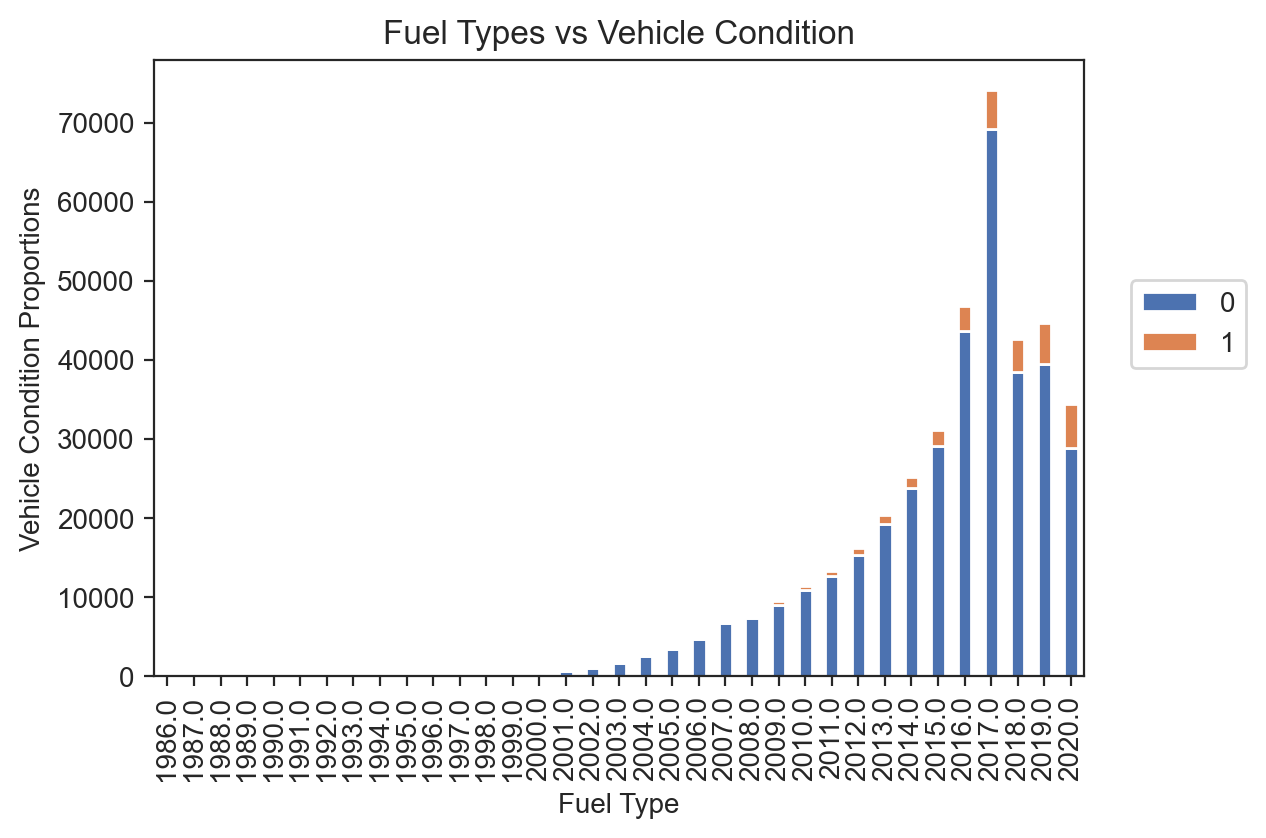

In [131]:
sds.unstack().plot.bar(stacked=True);
plt.title('Fuel Types vs Vehicle Condition')
plt.xlabel("Fuel Type")
plt.ylabel("Vehicle Condition Proportions")
plt.legend(loc=(1.05, 0.5))


In [132]:
adv['Vehicle condition'].value_counts().tail(50)

Vehicle condition
0    370287
1     31239
Name: count, dtype: int64

In [133]:
#categorical categorical
fuels = (adv
 .groupby(['Fueltype', 'Vehicle condition'])
 .size()
)
fuels

Fueltype               Vehicle condition
Bi Fuel                0                        75
                       1                       146
Diesel                 0                    151893
                       1                      6211
Diesel Hybrid          0                       921
                       1                       482
Diesel Plug-in Hybrid  0                       175
                       1                        10
Electric               0                      3266
                       1                      1517
Natural Gas            0                         1
Petrol                 0                    197320
                       1                     19172
Petrol Hybrid          0                     11623
                       1                      1978
Petrol Plug-in Hybrid  0                      4597
                       1                      1562
dtype: int64

In [134]:
fuelsize = (adv
 .groupby(['Fueltype'])
 .size()
)
fuelsize
#they aint making new diesal cars - driving zones clean air

Fueltype
Bi Fuel                     221
Diesel                   158104
Diesel Hybrid              1403
Diesel Plug-in Hybrid       185
Electric                   4783
Natural Gas                   1
Petrol                   216492
Petrol Hybrid             13601
Petrol Plug-in Hybrid      6159
dtype: int64

In [135]:
Fuelprop = fuels / fuelsize
Fuelprop

Fueltype               Vehicle condition
Bi Fuel                0                    0.339367
                       1                    0.660633
Diesel                 0                    0.960716
                       1                    0.039284
Diesel Hybrid          0                    0.656450
                       1                    0.343550
Diesel Plug-in Hybrid  0                    0.945946
                       1                    0.054054
Electric               0                    0.682835
                       1                    0.317165
Natural Gas            0                    1.000000
Petrol                 0                    0.911442
                       1                    0.088558
Petrol Hybrid          0                    0.854570
                       1                    0.145430
Petrol Plug-in Hybrid  0                    0.746387
                       1                    0.253613
dtype: float64

In [136]:
adv.sample(5)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Category,AvgModelUsed,AvgModelNew,AvgMakeNew,AvgMakeUsed
public_reference,,,,,,,,,,,,,,,,,
202010285531244,17526.0,18,Grey,Volkswagen,Polo,0,2018.0,13791,Hatchback,0,Petrol,8763.0,Medium,9358.587050,17616.236842,25083.754628,13039.551604
202002026850085,7409.0,69,White,Kia,XCeed,0,2019.0,18895,SUV,0,Petrol,7409.0,Medium,19186.648936,23831.344262,24684.201389,12106.301888
202009264224330,9418.0,69,Blue,Renault,Clio,0,2019.0,12634,Hatchback,0,Petrol,9418.0,Medium,7034.372993,17297.902386,24229.020742,8912.962059
202010024522062,52998.0,64,Grey,Nissan,Juke,0,2014.0,8288,SUV,0,Petrol,8833.0,Lower,9640.940448,21464.630094,23496.605464,10838.683337
202009153753739,11565.0,18,Red,Suzuki,Swift,0,2018.0,9995,Hatchback,0,Petrol Hybrid,5782.5,Lower,7016.910991,15625.343023,18933.115108,8516.594111


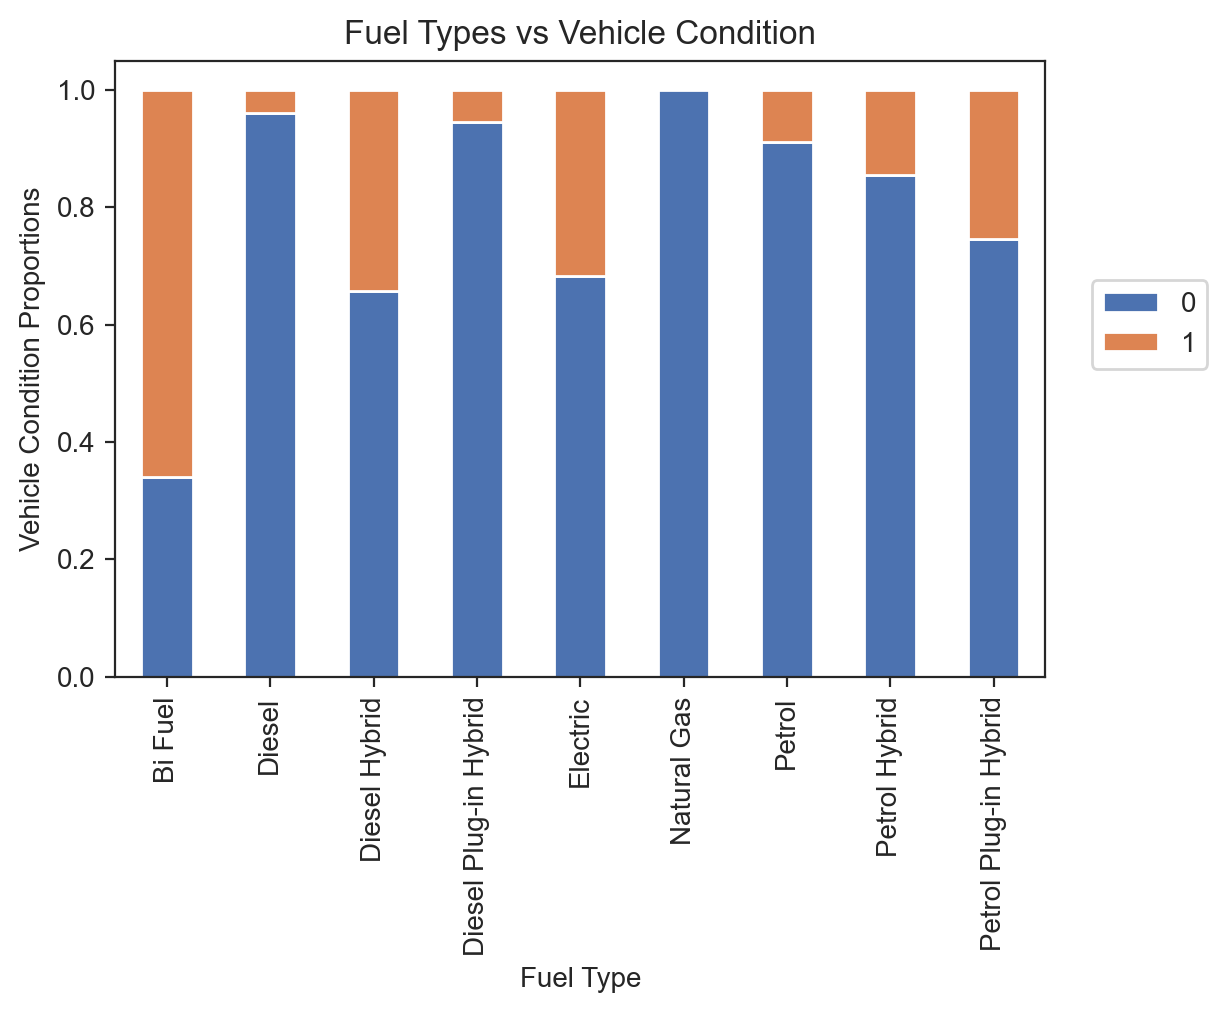

In [137]:
Fuelprop.unstack().plot.bar(stacked=True);
plt.title('Fuel Types vs Vehicle Condition')
plt.xlabel("Fuel Type")
plt.ylabel("Vehicle Condition Proportions")
plt.legend(loc=(1.05, 0.5))
plt.savefig('fsfnsjfnsj.jpeg', dpi=300, bbox_inches = "tight")
#need to order it

#the used car market vs the new car market are effecitvely two differnt places
#traditional fuel types (petrol, diesel) are being replaced by sustainable
#diesel cars are being phased out at a quicker rate than petrol
plt.savefig('fsfnsjfnsj.jpeg', dpi=300, bbox_inches = "tight")

In [138]:
dist_sex_survived2 = (adv
 .groupby(['Category', 'Bodytype'])
 .size()
)
dist_sex_survived2.head(50)

Category  Bodytype       
Cheap     Camper                 4
          Car Derived Van        1
          Chassis Cab            1
          Combi Van             46
          Convertible         4559
          Coupe               4310
          Estate              5784
          Hatchback          67153
          Limousine             32
          MPV                 6200
          Minibus               13
          Panel Van             13
          Pickup                66
          SUV                10026
          Saloon              6662
          Window Van            11
Lower     Camper                 9
          Car Derived Van        1
          Chassis Cab            1
          Combi Van             32
          Convertible         2383
          Coupe               3150
          Estate              5576
          Hatchback          50796
          Limousine             40
          MPV                 4213
          Minibus               16
          Panel Van          

In [139]:
dist_sex2 = (adv
 .groupby(['Category'])
 .size()
)
dist_sex2
#they aint making new diesal cars - driving zones clean air

Category
Cheap        105000
Lower         95599
Medium        95398
Upper         47759
Expensive     57770
dtype: int64

In [140]:
survived_cond_on_sex2 = dist_sex_survived2 / dist_sex2
survived_cond_on_sex2.head(50)

Category  Bodytype       
Cheap     Camper             0.000038
          Car Derived Van    0.000010
          Chassis Cab        0.000010
          Combi Van          0.000438
          Convertible        0.043419
          Coupe              0.041048
          Estate             0.055086
          Hatchback          0.639552
          Limousine          0.000305
          MPV                0.059048
          Minibus            0.000124
          Panel Van          0.000124
          Pickup             0.000629
          SUV                0.095486
          Saloon             0.063448
          Window Van         0.000105
Lower     Camper             0.000094
          Car Derived Van    0.000010
          Chassis Cab        0.000010
          Combi Van          0.000335
          Convertible        0.024927
          Coupe              0.032950
          Estate             0.058327
          Hatchback          0.531344
          Limousine          0.000418
          MPV           

In [141]:
aa =survived_cond_on_sex2.to_frame()

In [142]:
aa.columns = ["proportions"]
aa

proportions
Category  Bodytype                    
Cheap     Camper              0.000038
          Car Derived Van     0.000010
          Chassis Cab         0.000010
          Combi Van           0.000438
          Convertible         0.043419
...                                ...
Expensive Panel Van           0.000173
          Pickup              0.002008
          SUV                 0.516929
          Saloon              0.122399
          Window Van          0.000069

[80 rows x 1 columns]

In [143]:
aa.head()

proportions
Category Bodytype                    
Cheap    Camper              0.000038
         Car Derived Van     0.000010
         Chassis Cab         0.000010
         Combi Van           0.000438
         Convertible         0.043419

In [144]:
aa['proportions'] = aa[(aa['proportions'] >= 0.01)]

In [145]:
aa3 = aa[aa['proportions'].notna()]

In [146]:
aa3.head(50)

proportions
Category  Bodytype                
Cheap     Convertible     0.043419
          Coupe           0.041048
          Estate          0.055086
          Hatchback       0.639552
          MPV             0.059048
          SUV             0.095486
          Saloon          0.063448
Lower     Convertible     0.024927
          Coupe           0.032950
          Estate          0.058327
          Hatchback       0.531344
          MPV             0.044069
          SUV             0.241132
          Saloon          0.063745
Medium    Convertible     0.033051
          Coupe           0.053450
          Estate          0.068838
          Hatchback       0.352429
          MPV             0.037946
          SUV             0.339221
          Saloon          0.109300
Upper     Convertible     0.036747
          Coupe           0.064323
          Estate          0.067233
          Hatchback       0.231119
          MPV             0.030277
          SUV             0.430264
          Saloon          0.131577
Expensive Convertible     0.070054
          Coupe           0.130119
          Estate          0.061347
          Hatchback       0.080872
          SUV             0.516929
          Saloon          0.122399

In [147]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf','#e6daa6']

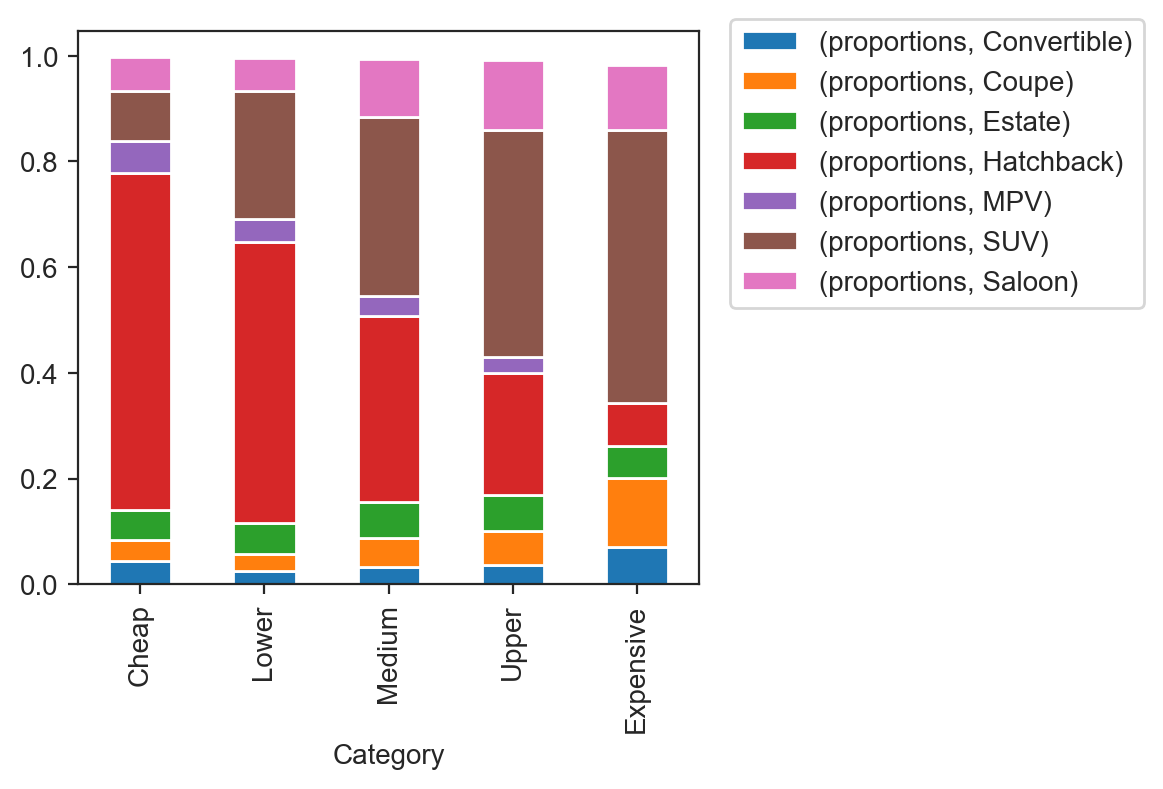

In [148]:
ax = aa3.unstack().plot.bar(stacked=True, color=colors)
plt.legend(loc= (1.05, 0.5)) 
plt.show
plt.tight_layout()
plt.savefig("prop.jpeg")

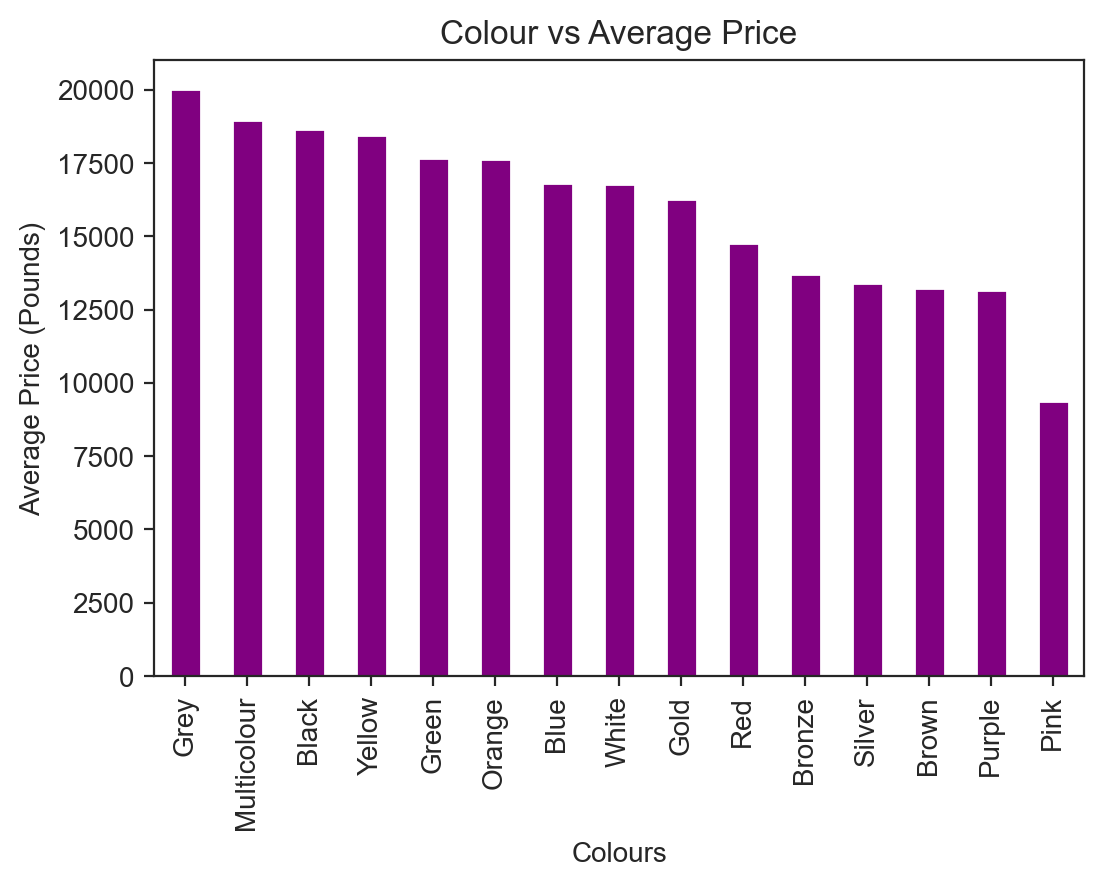

In [149]:
df = pd.DataFrame(adv.groupby(['Colour'])['Price'].mean().sort_values(ascending = False))
df.plot.bar(color='purple', legend=False,)
plt.title('Colour vs Average Price')
plt.xlabel("Colours")
plt.ylabel("Average Price (Pounds)");
plt.savefig('sfdss.jpeg', dpi=300, bbox_inches = "tight")
plt.show()

In [150]:
#IDENTICAL PREPROCESSING APART FROM NOT USING BFILL 

In [151]:
machine = pd.read_csv('adverts.csv')

In [152]:
machine.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [155]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
import matplotlib
warnings.filterwarnings('ignore')


#want to remove this for principles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import explained_variance_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import explained_variance_score
from sklearn.preprocessing import TargetEncoder
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import PredictionErrorDisplay
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

In [154]:
!pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.6/150.0 MB 13.3 MB/s eta 0:00:12
   - -------------------------------------- 4.5/150.0 MB 13.3 MB/s eta 0:00:11
   - -------------------------------------- 7.1/150.0 MB 12.1 MB/s eta 0:00:12
   -- ------------------------------------- 8.1/150.0 MB 10.8 MB/s eta 0:00:14
   -- ------------------------------------- 9.4/150.0 MB 9.6 MB/s eta 0:00:15
   --- ------------------------------------ 13.1/150.0 MB 10.8 MB/s eta 0:00:13
   ---- ----------------------------------- 16.0/150.0 MB 11.3 MB/s eta 0:00:12
   ---- ----------------------------------- 18.6/150.0 MB 11.5 MB/s eta 0:00:12
   ----- ---------------------------------- 20.7/150.0 MB 11.3 MB/s eta 0:00:12
   ------ --------------------------------- 23.6/150.0 MB 11.5 MB/s eta 0:00:11
   ------- -------------------------------- 28.0/150.0 MB 12.4 MB/s eta 0:00:10
   -------- ------------------------------- 32.0/150.0 

In [156]:
machine.info

<bound method DataFrame.info of         public_reference   mileage reg_code standard_colour standard_make  \
0        202006039777689       0.0      NaN            Grey         Volvo   
1        202007020778260  108230.0       61            Blue        Jaguar   
2        202007020778474    7800.0       17            Grey         SKODA   
3        202007080986776   45000.0       16           Brown      Vauxhall   
4        202007161321269   64000.0       64            Grey    Land Rover   
...                  ...       ...      ...             ...           ...   
402000   202010315652942    5179.0       69            Grey       Peugeot   
402001   202010315657341  110000.0       59             Red       Peugeot   
402002   202010315659271   52760.0       62           White        Nissan   
402003   202011015662436   10250.0       65             Red        Abarth   
402004   201512149444029   14000.0       14          Silver          Audi   

           standard_model vehicle_condition

In [157]:
machine.columns

Index(['public_reference', 'mileage', 'reg_code', 'standard_colour',
       'standard_make', 'standard_model', 'vehicle_condition',
       'year_of_registration', 'price', 'body_type', 'crossover_car_and_van',
       'fuel_type'],
      dtype='object')

In [158]:
machine.dtypes

public_reference           int64
mileage                  float64
reg_code                  object
standard_colour           object
standard_make             object
standard_model            object
vehicle_condition         object
year_of_registration     float64
price                      int64
body_type                 object
crossover_car_and_van       bool
fuel_type                 object
dtype: object

In [159]:
machine.shape

(402005, 12)

In [160]:
machine[['mileage', 'price']].describe().loc[['min', '25%', '50%', '75%', 'max', 'mean']] 

,mileage,price
min,0.000000,1.200000e+02
25%,10481.000000,7.495000e+03
50%,28629.500000,1.260000e+04
75%,56875.750000,2.000000e+04
max,999999.000000,9.999999e+06
mean,37743.595656,1.734197e+04


In [161]:
# Counting NaN values in all columns
nan_count = machine.isnull().sum()

print(nan_count)

public_reference             0
mileage                    127
reg_code                 31857
standard_colour           5378
standard_make                0
standard_model               0
vehicle_condition            0
year_of_registration     33311
price                        0
body_type                  837
crossover_car_and_van        0
fuel_type                  601
dtype: int64


In [162]:
missing_values_percentage = (machine.isnull().sum() / len(machine)) * 100
print(missing_values_percentage)

public_reference         0.000000
mileage                  0.031592
reg_code                 7.924528
standard_colour          1.337794
standard_make            0.000000
standard_model           0.000000
vehicle_condition        0.000000
year_of_registration     8.286215
price                    0.000000
body_type                0.208206
crossover_car_and_van    0.000000
fuel_type                0.149501
dtype: float64


In [163]:
#checking if public reference has any duplicates
boolean = machine['public_reference'].duplicated().any()
print(boolean)

False


In [164]:
machine = machine.set_index('public_reference')

In [165]:
machine.columns

Index(['mileage', 'reg_code', 'standard_colour', 'standard_make',
       'standard_model', 'vehicle_condition', 'year_of_registration', 'price',
       'body_type', 'crossover_car_and_van', 'fuel_type'],
      dtype='object')

In [166]:
machine.sample(5) 

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202009234120685,8895.0,19,White,Mercedes-Benz,E Class,USED,2019.0,62995,Estate,False,Petrol
202009214013047,66000.0,13,Black,Toyota,Auris,USED,2013.0,8995,Hatchback,False,Petrol Hybrid
202009043328864,8000.0,19,Blue,BMW,2 Series,USED,2019.0,19999,Coupe,False,Petrol
201908311698842,1300.0,20,Black,Fiat,Tipo,USED,2020.0,10995,Hatchback,False,Petrol
202009173866141,70740.0,62,Red,Nissan,Qashqai,USED,2013.0,6295,SUV,False,Diesel


In [167]:
(machine.loc[ machine['reg_code']== 'B' ])

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202008042070611,49585.0,B,NaN,Ferrari,308,USED,1984.0,54475,Convertible,False,Petrol
201809210743226,3900.0,B,Red,Toyota,Celica,USED,1984.0,23450,Coupe,False,Petrol
202003098187902,73330.0,B,Gold,Jaguar,Mark II,USED,NaN,24990,Saloon,False,Petrol
202009153772843,24000.0,B,Silver,MG,Metro,USED,1984.0,8995,Hatchback,False,Petrol
202010275489288,56109.0,B,Red,Jaguar,E-Type,USED,1964.0,119995,Coupe,False,Petrol
202008272998841,76000.0,B,Black,Rolls-Royce,Silver Spirit,USED,1985.0,8495,Saloon,False,Petrol
202010195173890,123000.0,B,Red,Citroen,2 CV,USED,1984.0,3999,Saloon,False,Petrol
202006170216087,91700.0,B,Red,Porsche,911,USED,1985.0,42995,Coupe,False,Petrol
202010044577681,53600.0,B,Red,Renault,5,USED,1985.0,4800,Hatchback,False,Petrol


In [168]:
machine.loc[[202008242869411]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202008242869411,3000.0,20,Red,Volvo,XC40,USED,2020.0,29895,SUV,False,Petrol


In [169]:
machine.loc[[202009234085081]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202009234085081,18107.0,19,Silver,Volkswagen,Golf,USED,2019.0,16000,Hatchback,False,Petrol


In [170]:
machine.loc[[202010104826185]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202010104826185,5972.0,69,White,Vauxhall,Corsa,USED,2019.0,10000,Hatchback,False,Petrol


In [171]:
machine.loc[[202002067009819]]

,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
public_reference,,,,,,,,,,,
202002067009819,0.0,NaN,Black,Fiat,500X,NEW,NaN,22300,SUV,False,Petrol


In [172]:
machine.columns

Index(['mileage', 'reg_code', 'standard_colour', 'standard_make',
       'standard_model', 'vehicle_condition', 'year_of_registration', 'price',
       'body_type', 'crossover_car_and_van', 'fuel_type'],
      dtype='object')

In [173]:
machine = machine.set_axis([
    'Mileage', 'Regcode', 'Colour', 'Make', 'Model',
       'Vehicle condition', 'Year of Registration', 'Price', 'Bodytype',
       'Crossover car and van', 'Fueltype'
], axis='columns')
#year_of_registration'

In [174]:
unique_years = sorted(machine['Year of Registration'].unique())
print(unique_years)

[np.float64(999.0), np.float64(1006.0), np.float64(1007.0), np.float64(1008.0), np.float64(1009.0), np.float64(1010.0), np.float64(1015.0), np.float64(1016.0), np.float64(1017.0), np.float64(1018.0), np.float64(1063.0), np.float64(1515.0), np.float64(1909.0), np.float64(1933.0), np.float64(1934.0), np.float64(1950.0), np.float64(1952.0), np.float64(1954.0), np.float64(1955.0), np.float64(1956.0), np.float64(1957.0), np.float64(1958.0), np.float64(1959.0), np.float64(1960.0), np.float64(1961.0), np.float64(1962.0), np.float64(1963.0), np.float64(1964.0), np.float64(1965.0), np.float64(1966.0), np.float64(1967.0), np.float64(1968.0), np.float64(1969.0), np.float64(1970.0), np.float64(1971.0), np.float64(1972.0), np.float64(1973.0), np.float64(1974.0), np.float64(1975.0), np.float64(1976.0), np.float64(1977.0), np.float64(1978.0), np.float64(1979.0), np.float64(1981.0), np.float64(1982.0), np.float64(1983.0), np.float64(1984.0), np.float64(1985.0), np.float64(1986.0), np.float64(1987.0), 

In [175]:
machine['Year of Registration'].value_counts().tail(50)

Year of Registration
1986.0    37
1973.0    29
1985.0    29
1972.0    25
1980.0    24
1970.0    24
1971.0    22
1979.0    22
1982.0    21
1984.0    19
1969.0    19
1968.0    17
1983.0    16
1978.0    15
1964.0    14
1965.0    14
1981.0    12
1976.0    12
1977.0    12
1962.0    10
1974.0     9
1967.0     9
1966.0     8
1961.0     7
1963.0     7
1975.0     6
1960.0     5
1957.0     5
1954.0     4
999.0      3
1955.0     3
1959.0     3
1956.0     3
1007.0     3
1958.0     3
1933.0     2
1009.0     2
1952.0     2
1515.0     1
1063.0     1
1016.0     1
1909.0     1
1010.0     1
1934.0     1
1008.0     1
1950.0     1
1018.0     1
1017.0     1
1006.0     1
1015.0     1
Name: count, dtype: int64

In [176]:
machine[machine[['Regcode','Year of Registration']].isna().all(1)]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
201911043995897,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
202008272998331,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
202001306737473,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
202003178531910,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
202010024501227,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
202010104843364,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
202010134960554,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol


In [177]:
machine = machine.loc[(machine['Year of Registration'] >= 1986) | pd.isna(machine['Year of Registration'])]

# Display the result
machine['Year of Registration'].value_counts().tail(50)

Year of Registration
2017.0    68790
2016.0    43483
2019.0    39236
2018.0    38300
2015.0    29019
2020.0    28683
2014.0    23666
2013.0    19117
2012.0    15312
2011.0    12614
2010.0    10828
2009.0     9011
2008.0     7297
2007.0     6694
2006.0     4729
2005.0     3385
2004.0     2510
2003.0     1731
2002.0     1083
2001.0      675
2000.0      447
1999.0      289
1998.0      249
1997.0      210
1996.0      147
1995.0      108
1994.0       97
1991.0       86
1992.0       79
1989.0       78
1990.0       75
1993.0       68
1988.0       68
1987.0       41
1986.0       37
Name: count, dtype: int64

In [178]:
machine['Year of Registration'].value_counts().tail(50)

Year of Registration
2017.0    68790
2016.0    43483
2019.0    39236
2018.0    38300
2015.0    29019
2020.0    28683
2014.0    23666
2013.0    19117
2012.0    15312
2011.0    12614
2010.0    10828
2009.0     9011
2008.0     7297
2007.0     6694
2006.0     4729
2005.0     3385
2004.0     2510
2003.0     1731
2002.0     1083
2001.0      675
2000.0      447
1999.0      289
1998.0      249
1997.0      210
1996.0      147
1995.0      108
1994.0       97
1991.0       86
1992.0       79
1989.0       78
1990.0       75
1993.0       68
1988.0       68
1987.0       41
1986.0       37
Name: count, dtype: int64

In [179]:
nan_count = machine.isnull().sum()

print(nan_count)

Mileage                    125
Regcode                  31811
Colour                    5323
Make                         0
Model                        0
Vehicle condition            0
Year of Registration     33311
Price                        0
Bodytype                   804
Crossover car and van        0
Fueltype                   577
dtype: int64


In [180]:
aq = len(machine['Vehicle condition'])
print(aq)

401553


In [181]:
machine['Vehicle condition'].unique()

array(['NEW', 'USED'], dtype=object)

In [182]:
machine['Vehicle condition'].value_counts()

Vehicle condition
USED    370304
NEW      31249
Name: count, dtype: int64

In [183]:
(machine['Vehicle condition'].value_counts() / aq) *100

Vehicle condition
USED    92.217964
NEW      7.782036
Name: count, dtype: float64

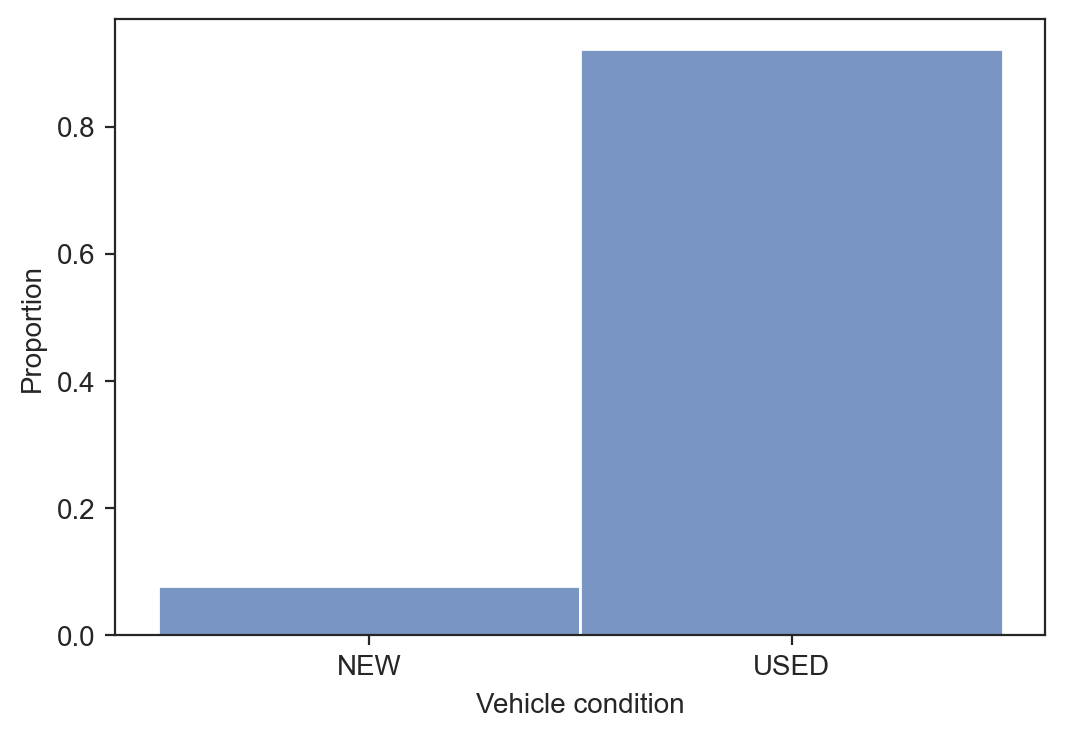

In [184]:
sns.histplot(machine['Vehicle condition'], stat='proportion');
plt.savefig("a.jpeg")

In [185]:
machine.head()

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [186]:
machine.dtypes

Mileage                  float64
Regcode                   object
Colour                    object
Make                      object
Model                     object
Vehicle condition         object
Year of Registration     float64
Price                      int64
Bodytype                  object
Crossover car and van       bool
Fueltype                  object
dtype: object

In [187]:
machine['Vehicle condition'].value_counts()

Vehicle condition
USED    370304
NEW      31249
Name: count, dtype: int64

In [188]:
machine[~(machine['Year of Registration'].ge(1986))]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
201911043995897,5.0,NaN,NaN,Nissan,X-Trail,NEW,NaN,27595,SUV,False,Diesel
202008272998331,0.0,NaN,White,Volkswagen,T-Cross,NEW,NaN,25000,SUV,False,Petrol
202001306737473,0.0,NaN,White,Fiat,Panda,NEW,NaN,13999,Hatchback,False,Petrol
202003178531910,0.0,NaN,NaN,Honda,Civic,NEW,NaN,19495,Hatchback,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
202010024501227,10.0,NaN,Silver,Mitsubishi,Shogun Sport,NEW,NaN,31999,SUV,False,Diesel
202010104843364,5.0,NaN,Red,BMW,Z4,NEW,NaN,47910,Convertible,False,Petrol
202010134960554,10.0,NaN,White,BMW,3 Series,NEW,NaN,35023,Saloon,False,Petrol


In [189]:
(machine.loc[ machine['Year of Registration']>=1986 ])

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel
202009304412074,16000.0,17,Blue,Audi,S5,USED,2017.0,29000,Convertible,False,Petrol
...,...,...,...,...,...,...,...,...,...,...,...
202010315652942,5179.0,69,Grey,Peugeot,208,USED,2019.0,10595,Hatchback,False,Petrol
202010315657341,110000.0,59,Red,Peugeot,107,USED,2009.0,2000,Hatchback,False,Petrol
202010315659271,52760.0,62,White,Nissan,Qashqai,USED,2012.0,7250,SUV,False,Petrol


In [190]:
machine['Vehicle condition'].value_counts()

Vehicle condition
USED    370304
NEW      31249
Name: count, dtype: int64

In [191]:
machine['Year of Registration'].value_counts().tail(40) # set the treshold from 1986

Year of Registration
2017.0    68790
2016.0    43483
2019.0    39236
2018.0    38300
2015.0    29019
2020.0    28683
2014.0    23666
2013.0    19117
2012.0    15312
2011.0    12614
2010.0    10828
2009.0     9011
2008.0     7297
2007.0     6694
2006.0     4729
2005.0     3385
2004.0     2510
2003.0     1731
2002.0     1083
2001.0      675
2000.0      447
1999.0      289
1998.0      249
1997.0      210
1996.0      147
1995.0      108
1994.0       97
1991.0       86
1992.0       79
1989.0       78
1990.0       75
1993.0       68
1988.0       68
1987.0       41
1986.0       37
Name: count, dtype: int64

In [192]:
machine['Vehicle condition'].value_counts()

Vehicle condition
USED    370304
NEW      31249
Name: count, dtype: int64

In [193]:
machine.loc[[202008242869411]]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202008242869411,3000.0,20,Red,Volvo,XC40,USED,2020.0,29895,SUV,False,Petrol


In [194]:
machine.loc[[202009234085081]]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202009234085081,18107.0,19,Silver,Volkswagen,Golf,USED,2019.0,16000,Hatchback,False,Petrol


In [195]:
machine.loc[[202010104826185]]

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010104826185,5972.0,69,White,Vauxhall,Corsa,USED,2019.0,10000,Hatchback,False,Petrol


In [196]:
machine['Fueltype'].unique()

array(['Petrol Plug-in Hybrid', 'Diesel', 'Petrol', 'Diesel Hybrid',
       'Petrol Hybrid', 'Electric', 'Diesel Plug-in Hybrid', nan,
       'Bi Fuel', 'Natural Gas'], dtype=object)

In [197]:
machine['Fueltype'].value_counts()

Fueltype
Petrol                   216516
Diesel                   158106
Petrol Hybrid             13601
Petrol Plug-in Hybrid      6160
Electric                   4783
Diesel Hybrid              1403
Bi Fuel                     221
Diesel Plug-in Hybrid       185
Natural Gas                   1
Name: count, dtype: int64

In [198]:
machine.loc[ machine['Fueltype']=='Natural Gas']

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010315647990,160000.0,55,White,Iveco,Daily,USED,2005.0,3795,Combi Van,True,Natural Gas


In [199]:
machine['Bodytype'].unique() 

array(['SUV', 'Saloon', 'Hatchback', 'Convertible', 'Limousine', 'Estate',
       'MPV', 'Coupe', nan, 'Pickup', 'Combi Van', 'Panel Van', 'Minibus',
       'Window Van', 'Camper', 'Car Derived Van', 'Chassis Cab'],
      dtype=object)

In [200]:
machine['Bodytype'].value_counts()

Bodytype
Hatchback          167287
SUV                115852
Saloon              36541
Estate              24683
Coupe               23154
MPV                 16026
Convertible         15903
Pickup                611
Combi Van             214
Limousine             157
Minibus               149
Camper                 67
Panel Van              59
Window Van             41
Chassis Cab             3
Car Derived Van         2
Name: count, dtype: int64

In [201]:
(machine.loc[ machine['Bodytype']=='Combi Van' ]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202011015668810,151000.0,59,Black,Volkswagen,Transporter Sportline,USED,2009.0,13000,Combi Van,True,Diesel
202010205209275,149000.0,05,White,Volkswagen,Transporter,USED,2005.0,8200,Combi Van,True,Diesel
202010145004133,96000.0,64,Grey,Volkswagen,Transporter,USED,2014.0,18750,Combi Van,True,Diesel
202008142497419,2658.0,69,White,Peugeot,Boxer,USED,2020.0,20058,Combi Van,False,Diesel
202002107163702,56000.0,62,Gold,Peugeot,Expert Tepee,USED,2012.0,6500,Combi Van,True,Diesel
202008293075951,31700.0,66,Grey,Fiat,Talento,USED,2016.0,13995,Combi Van,True,Diesel
202010215268466,65000.0,15,Grey,Vauxhall,Vivaro,USED,2015.0,23500,Combi Van,True,Diesel
201910163376428,12.0,NaN,Black,Nissan,e-NV200,NEW,NaN,32990,Combi Van,True,Electric
202010185136529,102000.0,09,Black,Volkswagen,Transporter Sportline,USED,2009.0,13295,Combi Van,True,Diesel


In [202]:
machine.loc[ machine['Bodytype']=='Car Derived Van']

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010175103802,193000.0,13,White,MINI,Clubvan,USED,2013.0,3995,Car Derived Van,True,Diesel
202006290651056,103000.0,NaN,White,Toyota,Granvia,USED,2012.0,10495,Car Derived Van,False,Diesel


In [203]:
machine['Colour'].value_counts()

Colour
Black          86260
White          70482
Grey           68212
Blue           59717
Silver         49291
Red            41934
Green           4474
Orange          4082
Yellow          2088
Brown           2004
Multicolour     1848
Beige           1531
Bronze          1327
Purple          1210
Gold             811
Pink             409
Turquoise        306
Maroon           158
Burgundy          63
Magenta           15
Navy               7
Indigo             1
Name: count, dtype: int64

In [204]:
domain_red = ['Red', 'Burgundy', 'Maroon']
domain_blue = ['Blue', 'Navy', 'Indigo', 'Turquoise']
domain_yellow = ['Yellow', 'Beige']
domain_purple = ['Purple', 'Magenta']

red_map = dict.fromkeys(domain_red, 'Red')
blue_map = dict.fromkeys(domain_blue, 'Blue')
yellow_map = dict.fromkeys(domain_yellow, 'Yellow')
purple_map = dict.fromkeys(domain_purple, 'Purple')
colour_scheme_map = {
    **red_map,
    **blue_map,
    **yellow_map,
    **purple_map,
    'Grey': 'Grey',
    #'Blue': 'Blue',
'Brown':'Brown',
#'Red':'Red',
'Bronze':'Bronze',
'Black':'Black',
'White':'White',
'Silver':'Silver',
#'Purple':'Purple',
'Green':'Green',
'Orange':'Orange',
#'Yellow':'Yellow',
'Gold':'Gold',
'Multicolour':'Multicolour',
'Pink':'Pink'
    

}
machine['Colour'] = machine['Colour'].map(colour_scheme_map)

In [205]:
machine['Colour'].value_counts().tail(50)

Colour
Black          86260
White          70482
Grey           68212
Blue           60031
Silver         49291
Red            42155
Green           4474
Orange          4082
Yellow          3619
Brown           2004
Multicolour     1848
Bronze          1327
Purple          1225
Gold             811
Pink             409
Name: count, dtype: int64

In [206]:
num_unique_instances = machine['Make'].nunique()

In [207]:
num_unique_instances

106

In [208]:
num_unique_instances1 = machine['Model'].nunique()

In [209]:
machine['Make'].value_counts().tail(50)

Make
Proton            25
Daimler           21
Caterham          21
Cadillac          15
Daewoo            10
Perodua           10
Hummer             9
LEVC               9
Austin             9
Bugatti            8
Replica            7
Lincoln            7
Westfield          6
Great Wall         6
Iveco              5
GMC                5
Holden             4
Maybach            4
Corvette           4
AC                 3
Ariel              3
Opel               3
Tiger              3
Lancia             2
Triumph            2
Dax                2
Zenos              2
Pilgrim            2
Aixam              2
BAC                2
Noble              2
Panther            1
Bristol            1
Carbodies          1
Reliant            1
Morris             1
Pagani             1
Beauford           1
Ultima             1
Mev                1
Datsun             1
Plymouth           1
AK                 1
Buick              1
Sebring            1
Radical            1
Pontiac            1
Jensen  

In [210]:
machine['Model'].value_counts().tail(50)

Model
MX-3            1
DB5             1
Crossline       1
340R            1
CE Class        1
Impian          1
Karmann         1
Sei             1
GS 430          1
222             1
19              1
Space Wagon     1
Sambar          1
C10             1
Seville         1
Tojeiro         1
DB2             1
President       1
3500            1
NV400           1
626             1
Tribute         1
Replica         1
Tempra          1
MPV             1
Sera            1
Tiida           1
Sparky          1
RX-7            1
Aero            1
Nomad           1
T Series        1
MGB GT          1
Rush            1
QX56            1
Primastar       1
Silver Cloud    1
Pajero Mini     1
Turbo RT        1
146             1
Plus Six        1
QX50            1
Daytona         1
Premacy         1
GMC             1
SS              1
Patrol GR       1
480             1
YRV             1
Z06             1
Name: count, dtype: int64

In [211]:
(machine.loc[ machine['Model']== 'Discovery' ])

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype
public_reference,,,,,,,,,,,
202010054616217,42333.0,17,Silver,Land Rover,Discovery,USED,2017.0,38990,SUV,False,Diesel
202010215258812,6679.0,68,Black,Land Rover,Discovery,USED,2019.0,54495,SUV,False,Diesel
202007171339614,92235.0,51,Gold,Land Rover,Discovery,USED,2001.0,5495,SUV,False,Diesel
202009284315780,61125.0,67,White,Land Rover,Discovery,USED,2017.0,36000,SUV,False,Diesel
202010134943201,10.0,NaN,Grey,Land Rover,Discovery,NEW,NaN,69499,SUV,False,Diesel
...,...,...,...,...,...,...,...,...,...,...,...
202010225312729,30000.0,17,Black,Land Rover,Discovery,USED,2017.0,35799,SUV,False,Diesel
202009113606969,33700.0,67,White,Land Rover,Discovery,USED,2018.0,40000,SUV,False,Diesel
202004078885601,4351.0,69,White,Land Rover,Discovery,USED,2020.0,44490,SUV,False,Diesel


In [212]:
machine['Milesperyear'] = machine['Mileage'] / (2020 - machine['Year of Registration']).replace(0, 1)

In [213]:
machine['Age'] = (2020 - machine['Year of Registration']).replace(0, 1)

In [214]:
machine['Crossover car and van'] = machine['Crossover car and van'].astype(int)

In [215]:
(machine.loc[ machine['Crossover car and van']==1 ]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age
public_reference,,,,,,,,,,,,,
202006300703207,7066.0,67,Purple,Volkswagen,Caddy Life,USED,2017.0,17975,MPV,1,Petrol,2355.333333,3.0
202010275504469,2879.0,20,Black,Nissan,Navara,USED,2020.0,29990,Pickup,1,Diesel,2879.000000,1.0
202010285515479,281500.0,06,Silver,Volkswagen,Caravelle,USED,2006.0,7650,MPV,1,Diesel,20107.142857,14.0
202011015668810,151000.0,59,Black,Volkswagen,Transporter Sportline,USED,2009.0,13000,Combi Van,1,Diesel,13727.272727,11.0
202005209437331,0.0,NaN,Blue,SsangYong,Musso,NEW,NaN,25631,Pickup,1,Diesel,NaN,NaN
202010074714694,108000.0,06,Silver,Isuzu,Rodeo,USED,2006.0,7500,Pickup,1,Diesel,7714.285714,14.0
202008102303002,72252.0,55,Green,Isuzu,Rodeo,USED,2005.0,3750,Pickup,1,Diesel,4816.800000,15.0
202008192681009,165000.0,D,Blue,Land Rover,90,USED,1987.0,10489,SUV,1,Diesel,5000.000000,33.0
202003017882700,3238.0,69,Silver,Mercedes-Benz,V Class,USED,2019.0,44000,MPV,1,Diesel,3238.000000,1.0


In [216]:
#x = sns.histplot(np.log10(machine.loc[ machine['Price']>0, 'Price']))
#ax.set_xticks(range(0,7))
#ax.set_xticklabels(np.power(10, range(0,7)));

In [217]:
#sns.histplot(data=machine.query("Price>100"), x='Price',
    #         common_norm=False, kde=True);

In [218]:
#sns.boxplot(data=machine, x='Price');
#plt.savefig('box.jpeg')

In [219]:
#num_samples = 10000
#bootstrap_samples = np.empty((num_samples, len(machine)))
#print(bootstrap_samples.shape)

In [220]:
#rng = np.random.default_rng(seed=42)

In [221]:
#for i in range(0, num_samples):
   #bootstrap_samples[i] = rng.choice(machine['Price'], len(machine))

In [222]:
#bootstrap_means = bootstrap_samples.mean(axis=1)
#bootstrap_means[:20], len(bootstrap_means)

In [223]:
#fig, ax = plt.subplots(figsize=(7,3))
#ax = sns.histplot(x=bootstrap_means, stat='proportion', bins=20)
#sns.rugplot(x=bootstrap_means, ax=ax, color="aqua", height=0.05, linewidth=0.5);

#ax.axvline(bootstrap_means.mean(), color="lightsalmon", linewidth=0.5)
#ax.axvline(np.percentile(bootstrap_means, 2.5), color="fuchsia", linewidth=0.5)
#ax.axvline(np.percentile(bootstrap_means, 50), color="fuchsia", linewidth=0.5)
#ax.axvline(np.percentile(bootstrap_means, 97.5), color="fuchsia", linewidth=0.5)

In [224]:
#So, these are the mean and the confidence interval (at 95% level) of
#print(machine['Price'].mean())
#print(np.percentile(bootstrap_means, 2.5))
#print(np.percentile(bootstrap_means, 97.5))
#print(np.percentile(bootstrap_means, 50))#

In [225]:
pq005 = machine['Price'].quantile(0.025)
pq995 = machine['Price'].quantile(0.975)
print(pq005,pq995)

1695.0 59995.0


In [226]:
machine.sort_values(['Price'], ascending=[False]).head(100)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age
public_reference,,,,,,,,,,,,,
202001226429470,950.0,NaN,Black,Ferrari,LaFerrari,USED,NaN,9999999,Coupe,0,Petrol,NaN,NaN
202007050883898,87450.0,NaN,Red,Ferrari,250,USED,NaN,9999999,Coupe,0,Petrol,NaN,NaN
201812223434109,3600.0,NaN,Grey,Lamborghini,Miura,USED,NaN,9999999,Coupe,0,Petrol,NaN,NaN
202009103539048,100.0,NaN,Grey,Maserati,3500,USED,NaN,9999999,Convertible,0,Petrol,NaN,NaN
202006180262926,4400.0,NaN,White,Porsche,959,USED,NaN,9999999,Coupe,0,Petrol,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
202010215260299,1250.0,67,Red,Aston Martin,Vanquish,USED,2018.0,465000,Convertible,0,Petrol,625.000000,2.0
202010215278726,50.0,70,Grey,Lamborghini,Aventador,USED,2020.0,464995,Convertible,0,Petrol,50.000000,1.0
202009294351394,21.0,18,Black,Aston Martin,Vanquish,USED,2018.0,455000,Convertible,0,Petrol,10.500000,2.0


In [227]:
ci1 = machine[(machine['Price'] >= pq005) & (machine['Price'] <= pq995)] #95% ci

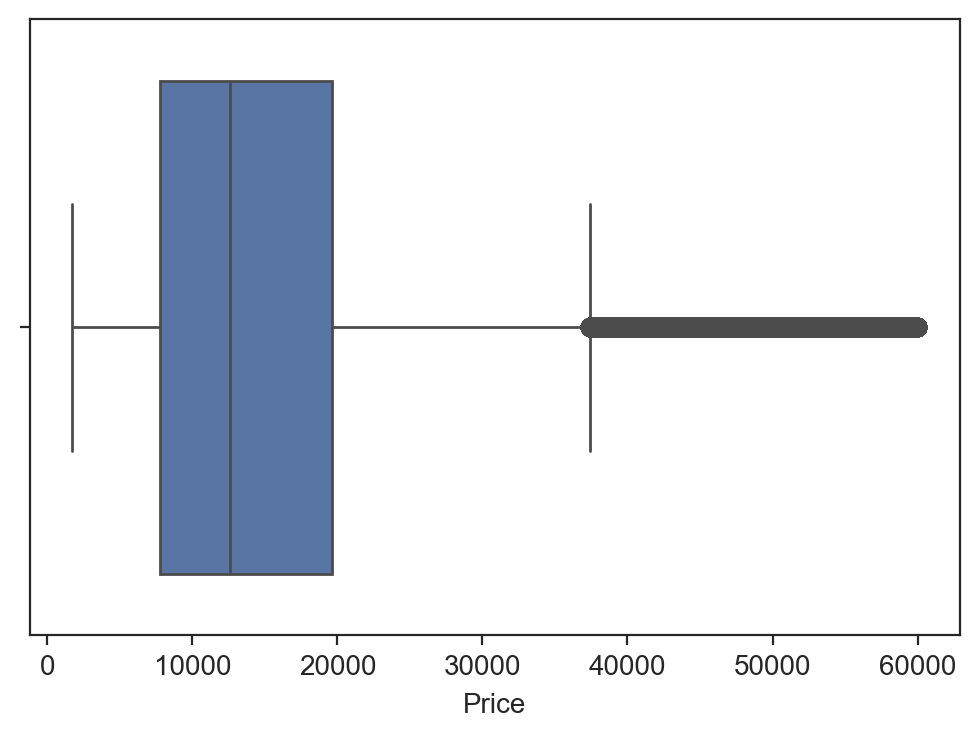

In [228]:
sns.boxplot(data=ci1, x='Price');
#5% confidence interval

In [229]:
pq006 = machine['Price'].quantile(0.005)
pq996 = machine['Price'].quantile(0.995)
print(pq006,pq996)

899.0 119970.0


In [230]:
ci2 = machine[(machine['Price'] >= pq005) & (machine['Price'] <= pq996)] #99% ci

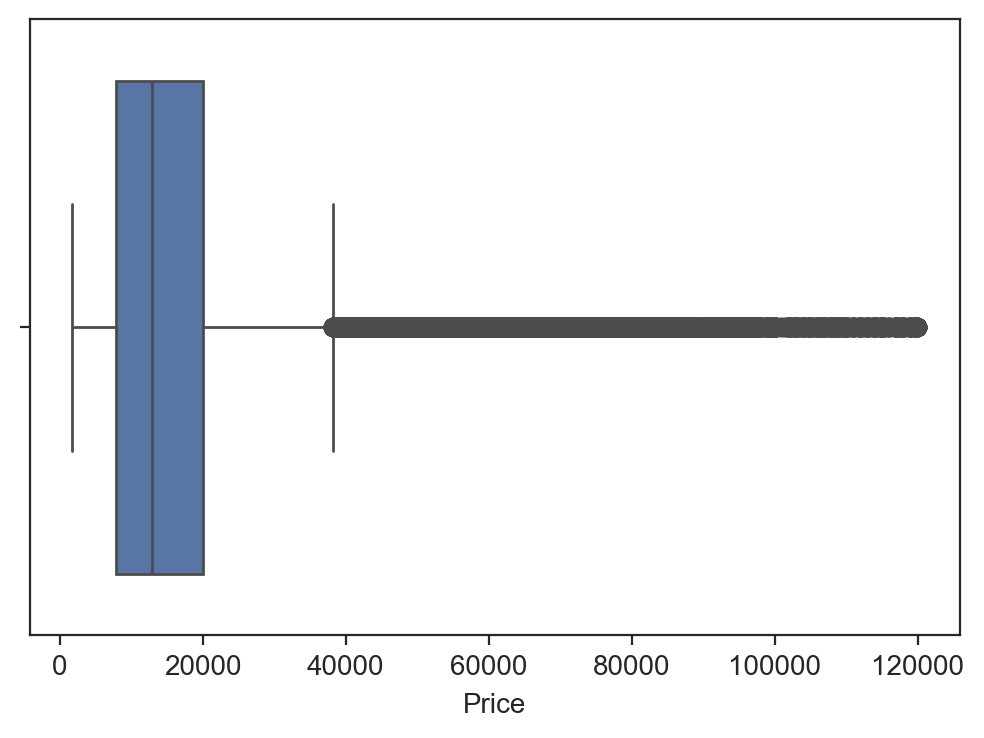

In [231]:
sns.boxplot(data=ci2, x='Price');

In [232]:
pq007 = machine['Price'].quantile(0.0005)
pq997 = machine['Price'].quantile(0.9995)
print(pq007,pq997)

495.0 299955.60000000114


In [233]:
ci3 = machine[(machine['Price'] >= pq007) & (machine['Price'] <= pq997)] #99.9% ci

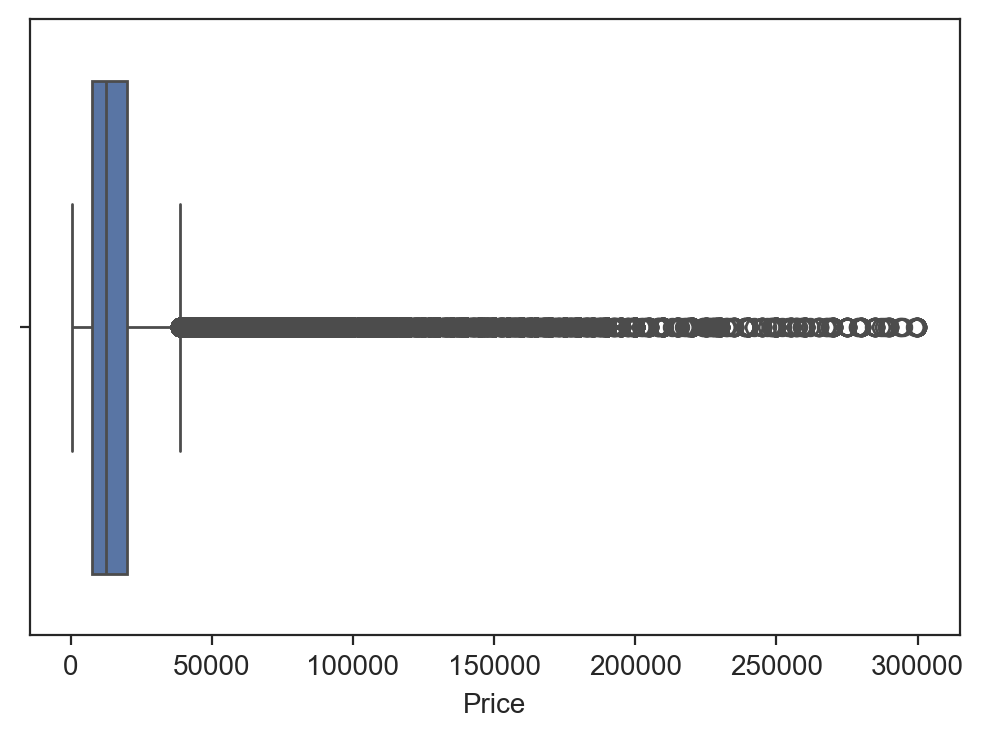

In [234]:
sns.boxplot(data=ci3, x='Price');

In [235]:
machine = machine[(machine['Price'] >= pq005) & (machine['Price'] <= pq995)] 
print(pq005,pq995)

1695.0 59995.0


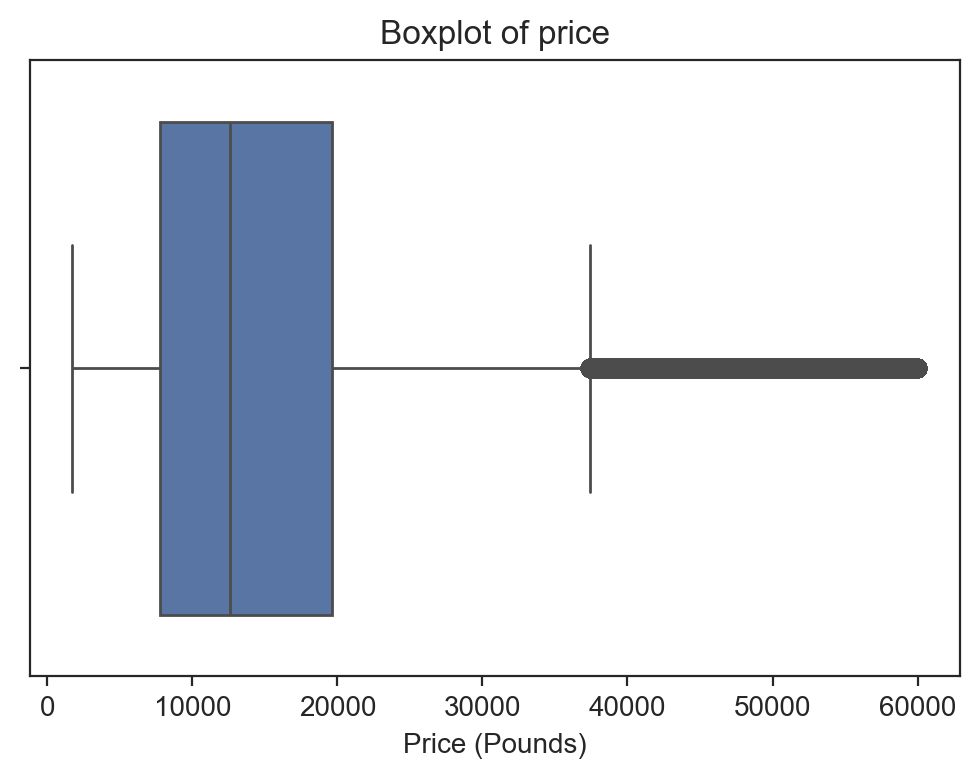

In [236]:
sns.boxplot(data=machine, x='Price');
plt.title('Boxplot of price')
plt.xlabel("Price (Pounds)")
plt.savefig('boxsfs.jpeg')

In [237]:
machine['Price'].describe().loc[['min', '25%', '50%', '75%', 'max']]

min     1695.0
25%     7750.0
50%    12599.0
75%    19604.0
max    59995.0
Name: Price, dtype: float64

In [238]:
machine.sort_values(['Price'], ascending=[False]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age
public_reference,,,,,,,,,,,,,
202010175100518,0.0,NaN,Black,Land Rover,Range Rover Velar,NEW,NaN,59995,SUV,0,Diesel,NaN,NaN
202009214014346,10.0,NaN,Black,BMW,8 Series Gran Coupe,NEW,NaN,59995,Saloon,0,Petrol,NaN,NaN
202009244161803,3845.0,69,Black,Land Rover,Discovery,USED,2019.0,59995,SUV,0,Diesel,3845.000000,1.0
202007141205015,3999.0,69,Black,Mercedes-Benz,A Class,USED,2019.0,59995,Hatchback,0,Petrol,3999.000000,1.0
202010225318110,29500.0,16,Blue,Land Rover,Range Rover Sport,USED,2016.0,59995,SUV,0,Petrol,7375.000000,4.0
202010165078004,0.0,NaN,Green,Land Rover,Defender 110,NEW,NaN,59995,SUV,0,Diesel,NaN,NaN
202009073406526,100.0,20,NaN,Maserati,Levante,USED,2020.0,59995,SUV,0,Petrol,100.000000,1.0
202009284319923,41000.0,67,Grey,Jaguar,F-Type,USED,2017.0,59995,Coupe,0,Petrol,13666.666667,3.0
202007171366123,5000.0,20,Black,Audi,Q7,USED,2020.0,59995,SUV,0,Petrol Plug-in Hybrid,5000.000000,1.0


In [239]:
max_price = machine['Price'].max()
min_price = machine['Price'].min()

In [240]:
sdd = machine['Price'].quantile(0.875)
print(sdd)

26991.0


In [241]:
machine['Category'] = pd.cut(
   machine['Price'],
    bins=[min_price, 7750.00, 12599.00, 19600.00, 26991.0, max_price+0.1],
    labels=['Cheap', 'Lower', 'Medium', 'Upper','Expensive'],
    right=False, 
    include_lowest=True)

In [242]:
machine.columns

Index(['Mileage', 'Regcode', 'Colour', 'Make', 'Model', 'Vehicle condition',
       'Year of Registration', 'Price', 'Bodytype', 'Crossover car and van',
       'Fueltype', 'Milesperyear', 'Age', 'Category'],
      dtype='object')

In [243]:
machine.sample(5)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age,Category
public_reference,,,,,,,,,,,,,,
202009183879543,60339.0,08,Red,Vauxhall,Astra,USED,2008.0,5790,Hatchback,0,Petrol,5028.250000,12.0,Cheap
202010285535896,35915.0,67,Silver,Volvo,XC60,USED,2017.0,27995,SUV,0,Diesel,11971.666667,3.0,Expensive
202010064644181,31588.0,66,Silver,MINI,Clubman,USED,2016.0,13700,Estate,0,Diesel,7897.000000,4.0,Medium
202009023229073,10.0,NaN,Silver,Volkswagen,Golf,NEW,NaN,25000,Hatchback,0,Petrol,NaN,NaN,Upper
202008262955858,6260.0,69,Blue,Volvo,V90,USED,2019.0,30495,Estate,0,Diesel,6260.000000,1.0,Expensive


In [244]:
machine['Vehicle condition'] = machine['Vehicle condition'].replace('USED', '0')
machine['Vehicle condition'] = machine['Vehicle condition'].replace('NEW', '1')

In [245]:
(machine.loc[ machine['Vehicle condition']==0 ]).head(50)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age,Category
public_reference,,,,,,,,,,,,,,


In [246]:
machine.sample(56)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age,Category
public_reference,,,,,,,,,,,,,,
202010175121874,46586.0,15,Grey,Mercedes-Benz,E Class,0,2015.0,16495,Estate,0,Diesel,9317.200000,5.0,Medium
202010195165533,5920.0,20,Black,Kia,Niro,0,2020.0,34200,SUV,0,Electric,5920.000000,1.0,Expensive
202009254191859,17500.0,69,Black,Volkswagen,Polo,0,2019.0,19000,Hatchback,0,Petrol,17500.000000,1.0,Medium
202009203987869,56360.0,63,Blue,Citroen,C3 Picasso,0,2014.0,4595,MPV,0,Diesel,9393.333333,6.0,Cheap
202010305625109,17360.0,66,White,Smart,fortwo,0,2016.0,6495,Coupe,0,Petrol,4340.000000,4.0,Cheap
202010285532999,99000.0,04,Black,Nissan,Elgrand,0,2004.0,4995,MPV,0,Petrol,6187.500000,16.0,Cheap
202006200350797,22790.0,66,White,Citroen,Grand C4 Picasso,0,2016.0,13550,MPV,0,Diesel,5697.500000,4.0,Medium
202008313138264,18021.0,18,Red,Honda,Civic,0,2018.0,12985,Hatchback,0,Petrol,9010.500000,2.0,Medium
202010144988685,0.0,NaN,NaN,Suzuki,Swift,1,NaN,17899,Hatchback,0,Petrol Hybrid,NaN,NaN,Medium


In [247]:
machine['Vehicle condition'] = machine['Vehicle condition'].astype(int)

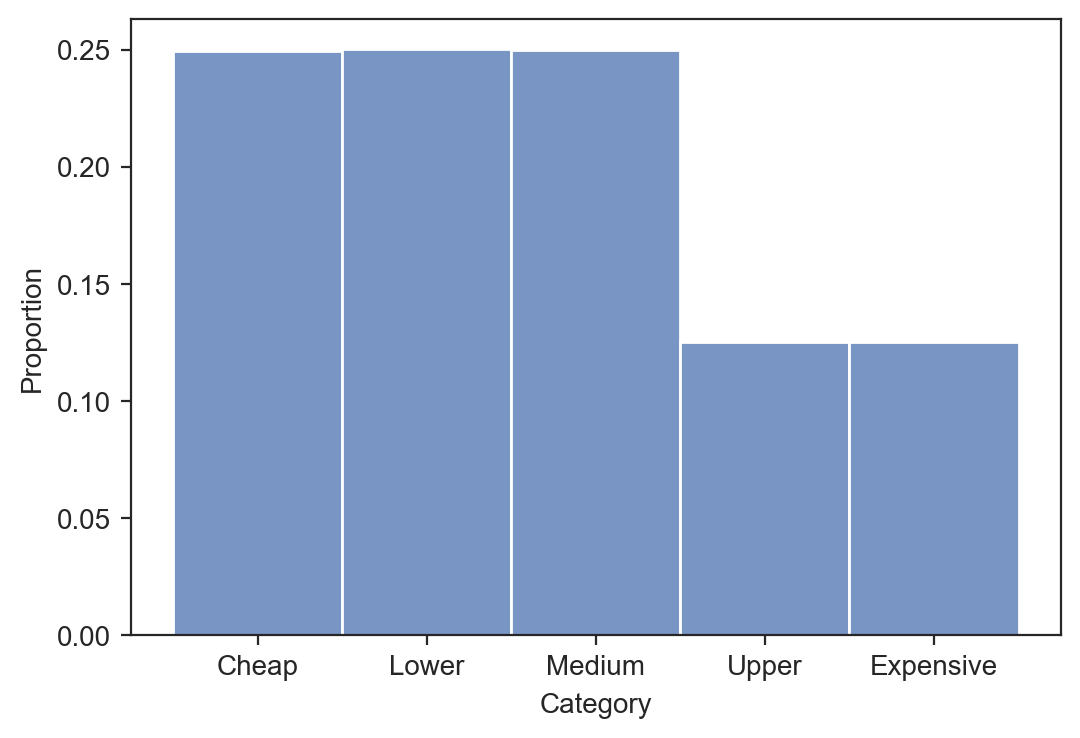

In [248]:
sns.histplot(machine['Category'], stat='proportion');

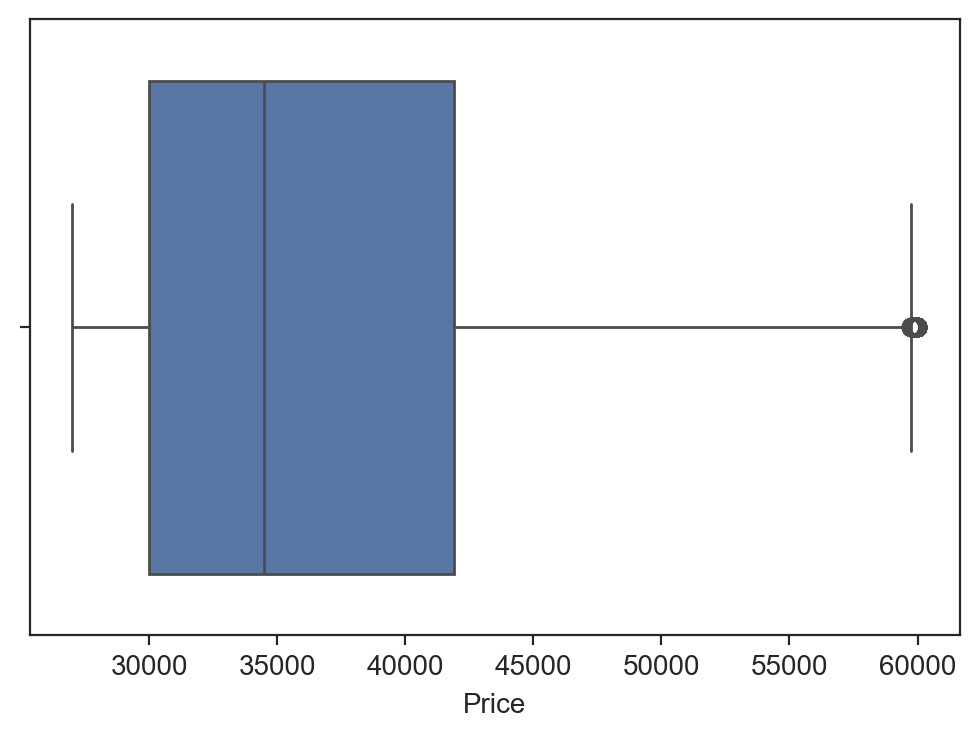

In [249]:
sns.boxplot(data= (machine.loc[ machine['Category']=='Expensive']), x='Price');

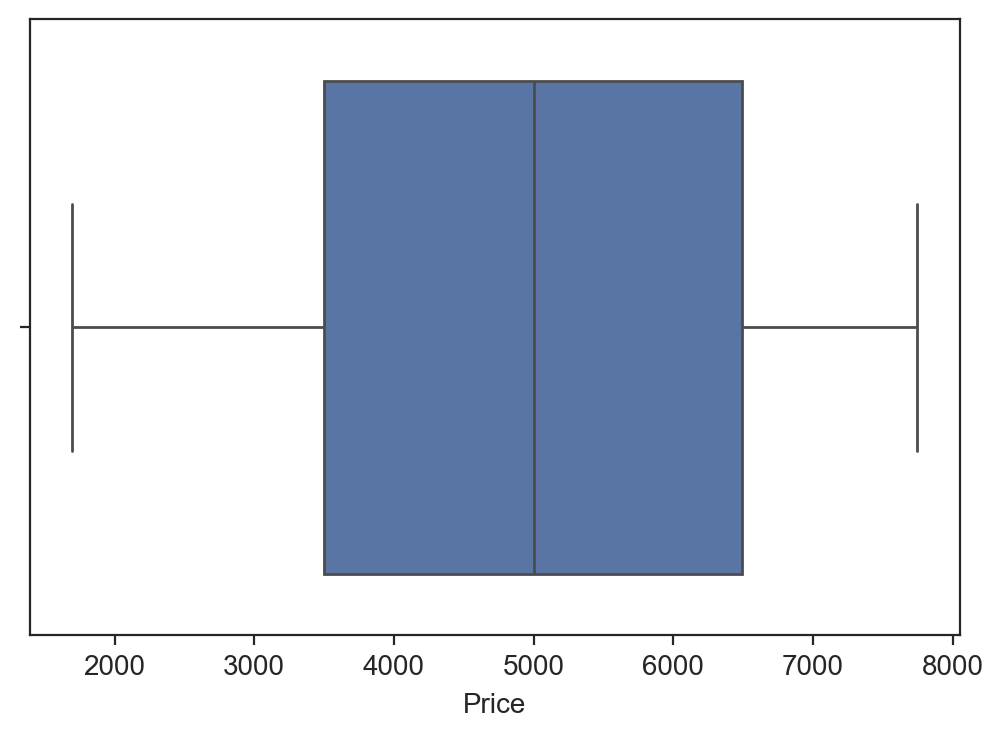

In [250]:
sns.boxplot(data=(machine.loc[ machine['Category']=='Cheap']), x='Price');

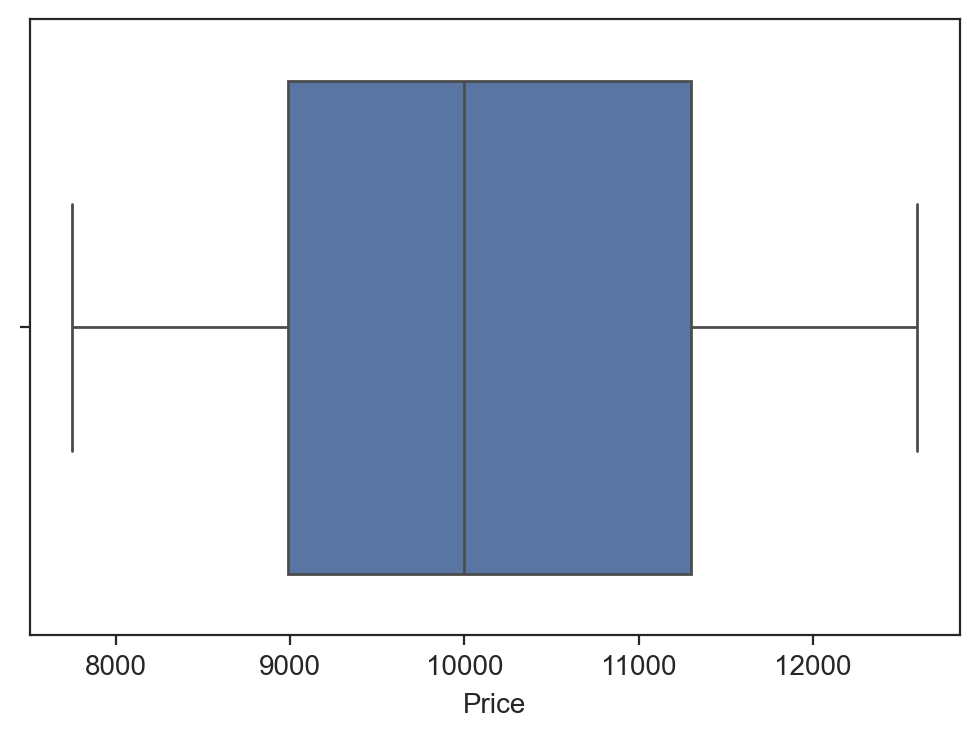

In [251]:
sns.boxplot(data=(machine.loc[ machine['Category']=='Lower']), x='Price');

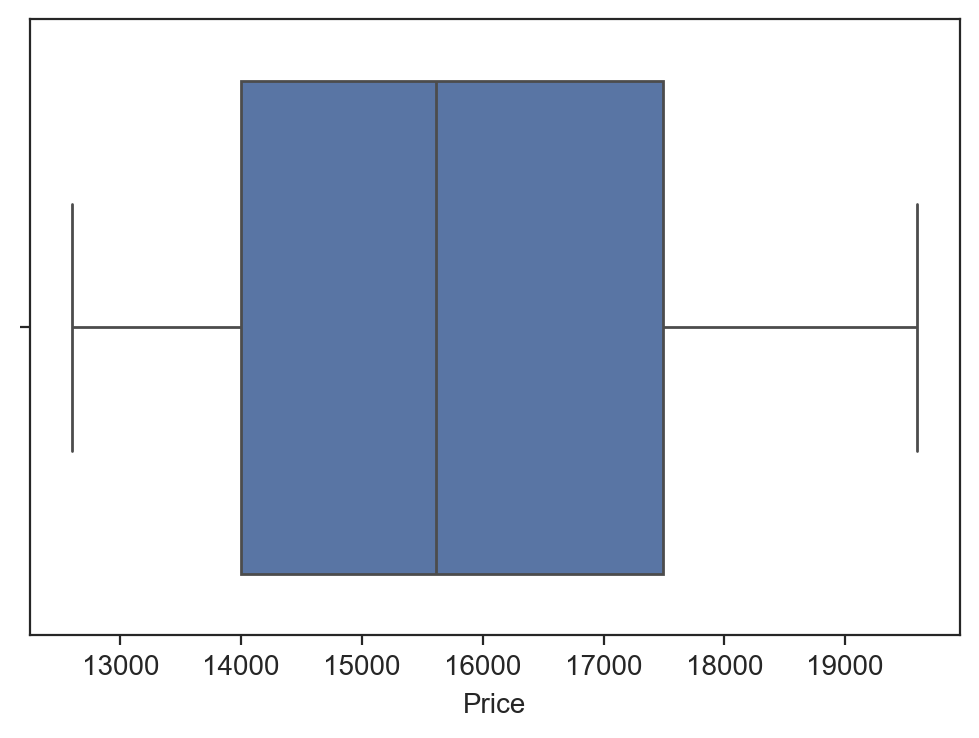

In [252]:
sns.boxplot(data=(machine.loc[ machine['Category']=='Medium']), x='Price');

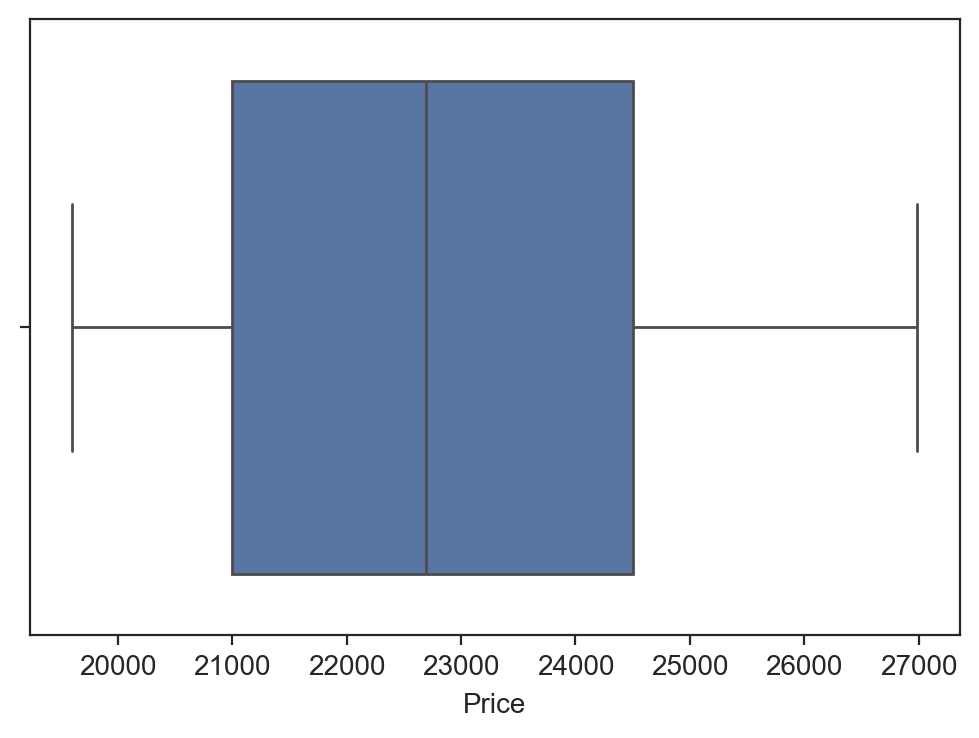

In [253]:
sns.boxplot(data=(machine.loc[ machine['Category']=='Upper']), x='Price');

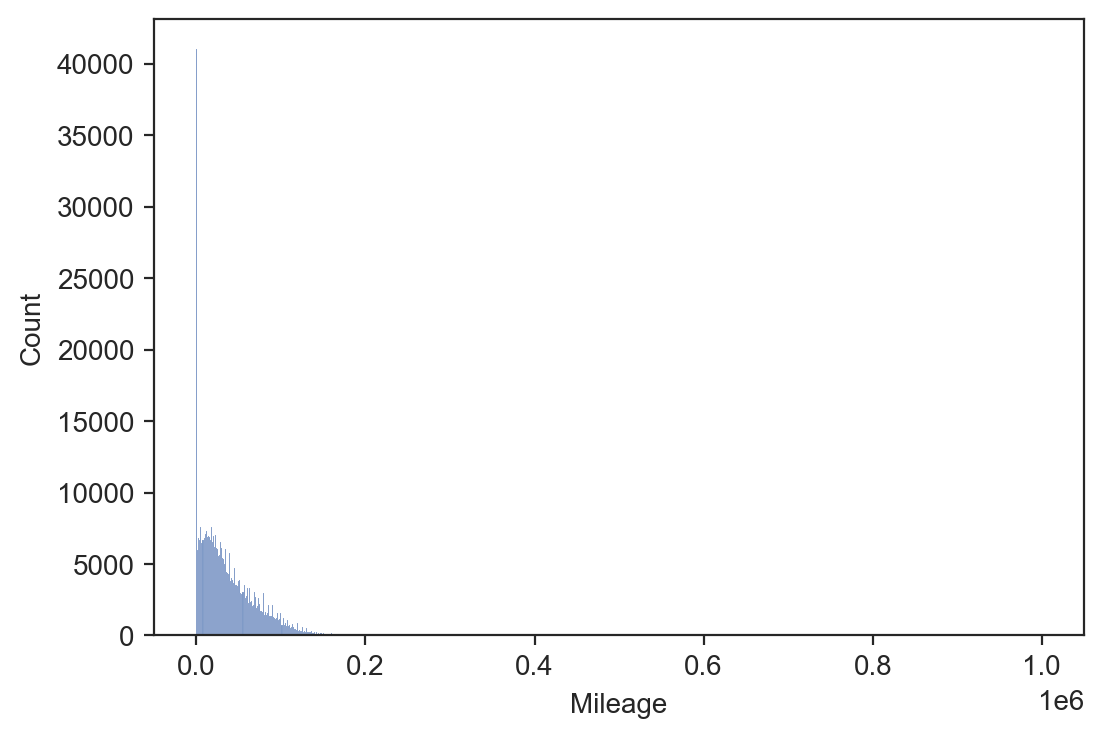

In [254]:
sns.histplot(data=machine, x='Mileage');

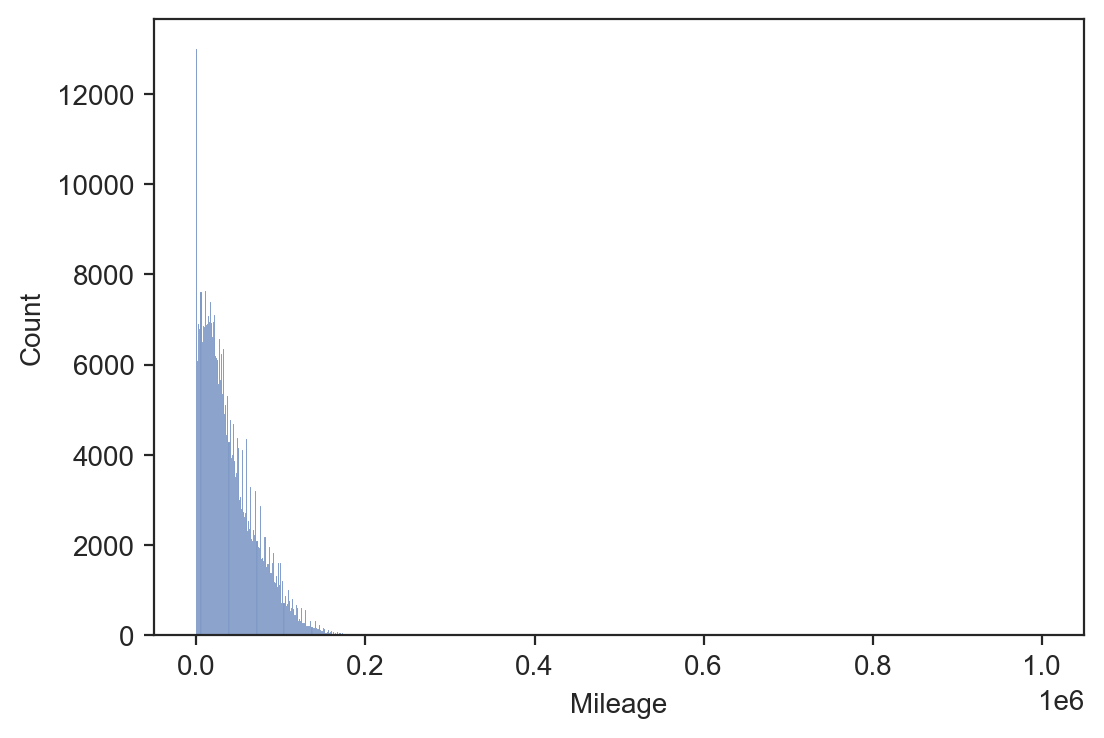

In [255]:
sns.histplot(data=(machine.loc[ machine['Vehicle condition']==0]), x='Mileage');

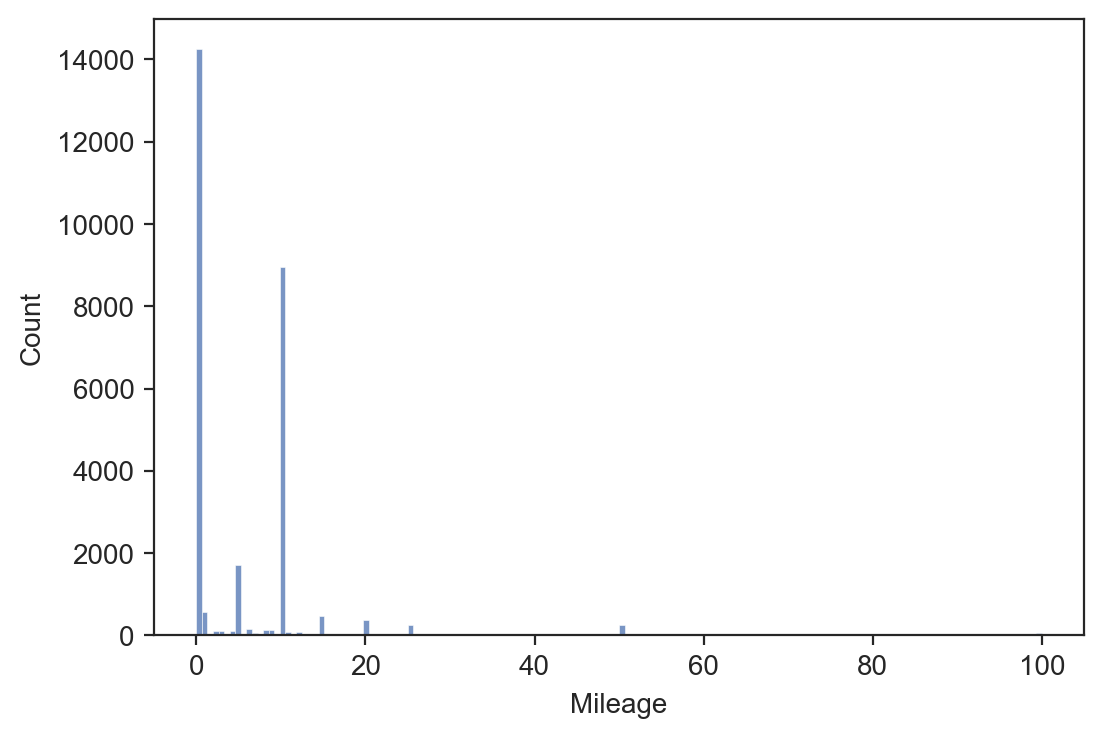

In [256]:
sns.histplot(data=(machine.loc[ machine['Vehicle condition']==1]), x='Mileage');

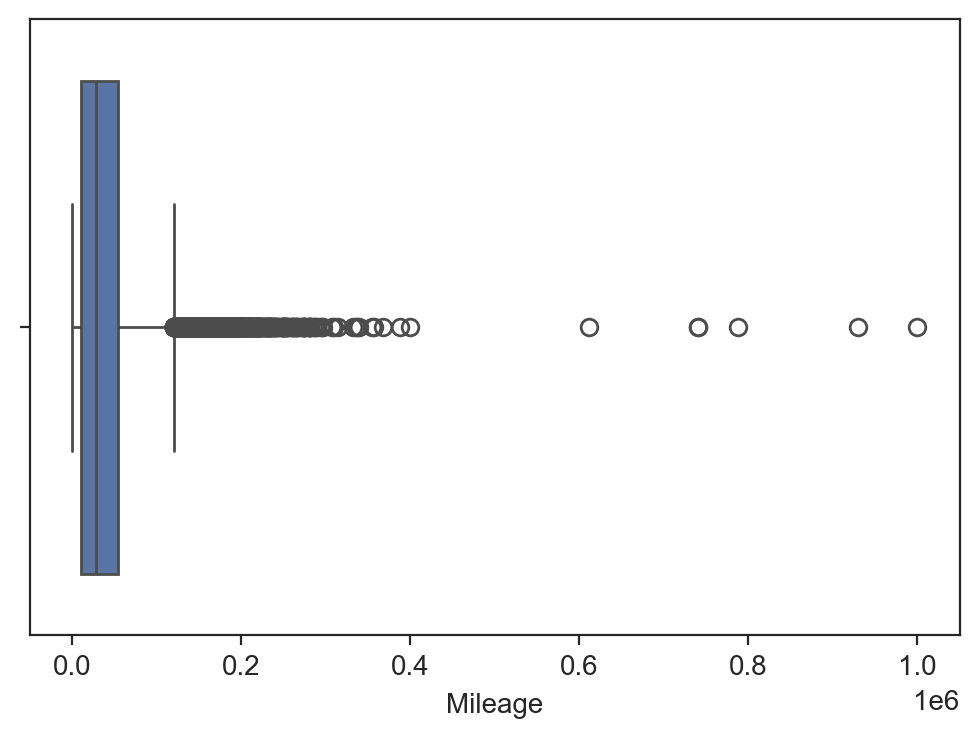

In [257]:
sns.boxplot(data=machine, x='Mileage');

In [258]:
machine.sort_values(['Mileage'], ascending=[False]).head(70)

,Mileage,Regcode,Colour,Make,Model,Vehicle condition,Year of Registration,Price,Bodytype,Crossover car and van,Fueltype,Milesperyear,Age,Category
public_reference,,,,,,,,,,,,,,
202008122406434,999999.0,63,White,Vauxhall,Astra,0,2013.0,9999,Hatchback,0,Diesel,142857.000000,7.0,Lower
202010285542410,930000.0,56,Blue,BMW,1 Series,0,2006.0,2500,Hatchback,0,Petrol,66428.571429,14.0,Cheap
202010064664710,788072.0,68,Blue,MINI,Countryman,0,2018.0,22875,SUV,0,Petrol,394036.000000,2.0,Upper
202009244163289,740000.0,11,White,Mercedes-Benz,E Class,0,2011.0,10500,Convertible,0,Diesel,82222.222222,9.0,Lower
202010215262290,740000.0,14,Blue,Volvo,XC90,0,2014.0,14795,SUV,0,Diesel,123333.333333,6.0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202009304399425,248000.0,15,Silver,Volkswagen,Transporter Shuttle,0,2015.0,11950,Minibus,1,Diesel,49600.000000,5.0,Lower
202009053349571,246000.0,14,Blue,Mercedes-Benz,E Class,0,2014.0,6950,Estate,0,Diesel,41000.000000,6.0,Cheap
202008132432020,245132.0,62,Silver,Volkswagen,Phaeton,0,2013.0,4989,Saloon,0,Diesel,35018.857143,7.0,Cheap


In [259]:
m007 = machine['Mileage'].quantile(0.0005)
m997 = machine['Mileage'].quantile(0.9995)
print(m007,m997)
mi3 = machine[(machine['Price'] <= pq997)]

0.0 201885.3309999999


In [260]:
m006 = machine['Mileage'].quantile(0.005)
m996 = machine['Mileage'].quantile(0.995)
print(m006,m996)

0.0 150000.0


In [261]:
machine = (machine.loc[ machine['Mileage']<=m996])

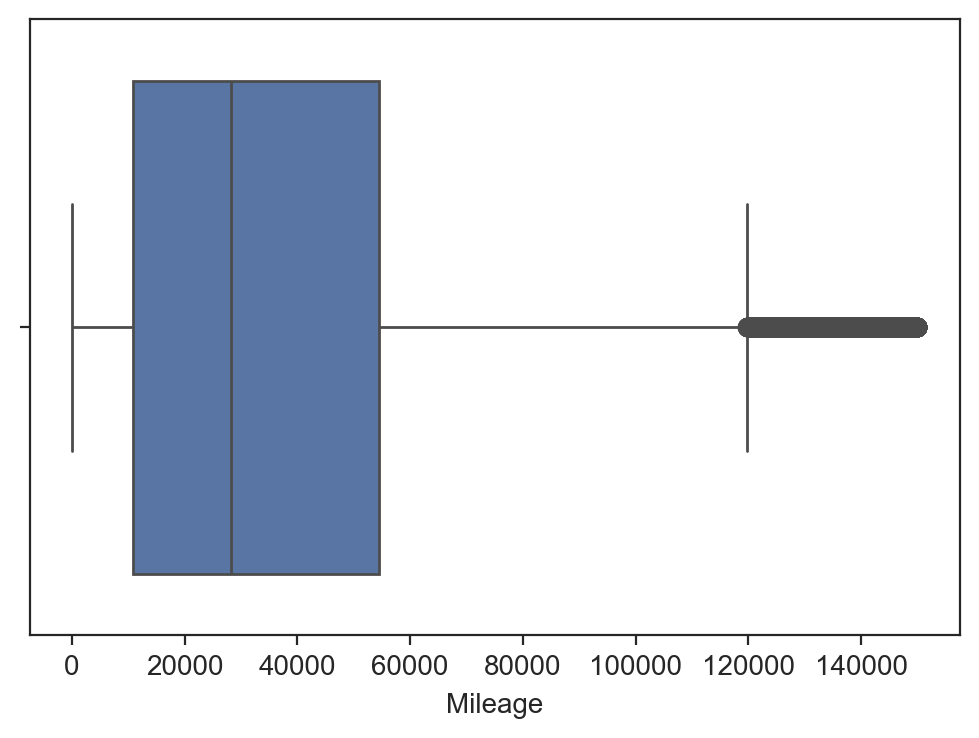

In [262]:
sns.boxplot(data=machine, x='Mileage');

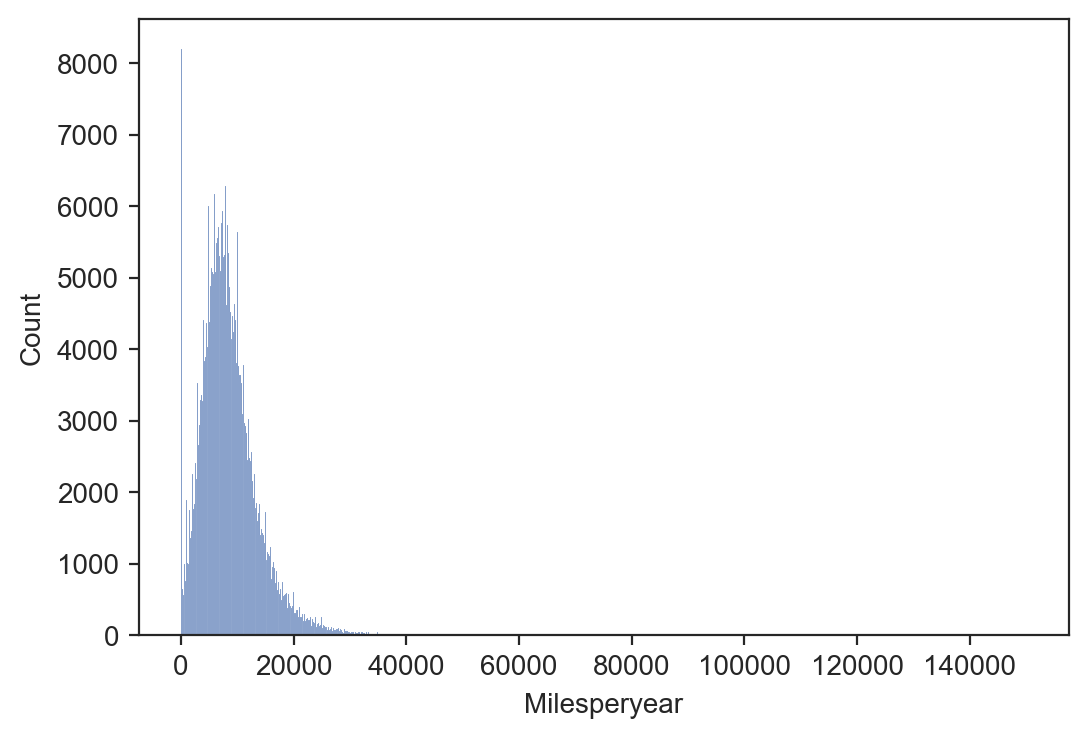

In [263]:
sns.histplot(data=machine, x='Milesperyear');
#appeas somewhat normally distrubted where values arent 0
#may need to remove 0

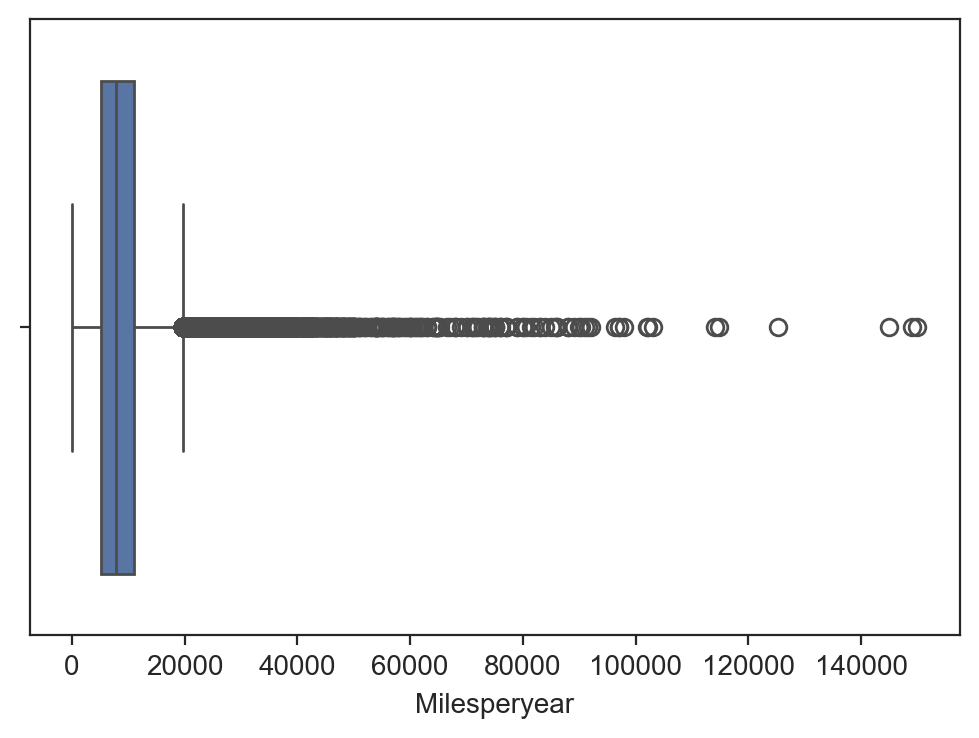

In [264]:
sns.boxplot(data=machine, x='Milesperyear');

In [ ]:
sns.histplot(data=machine.query("Milesperyear>10"), x='Milesperyear',
             common_norm=False, kde=True);

In [ ]:
machine.sample(5) 

In [ ]:
machine.columns

In [ ]:
plt.subplots(figsize=(8,6))
sns.heatmap(machine[features_to_corr].corr(), cmap="YlGnBu", annot=True)
plt.tight_layout()
plt.savefig('heatmap1.jpeg')

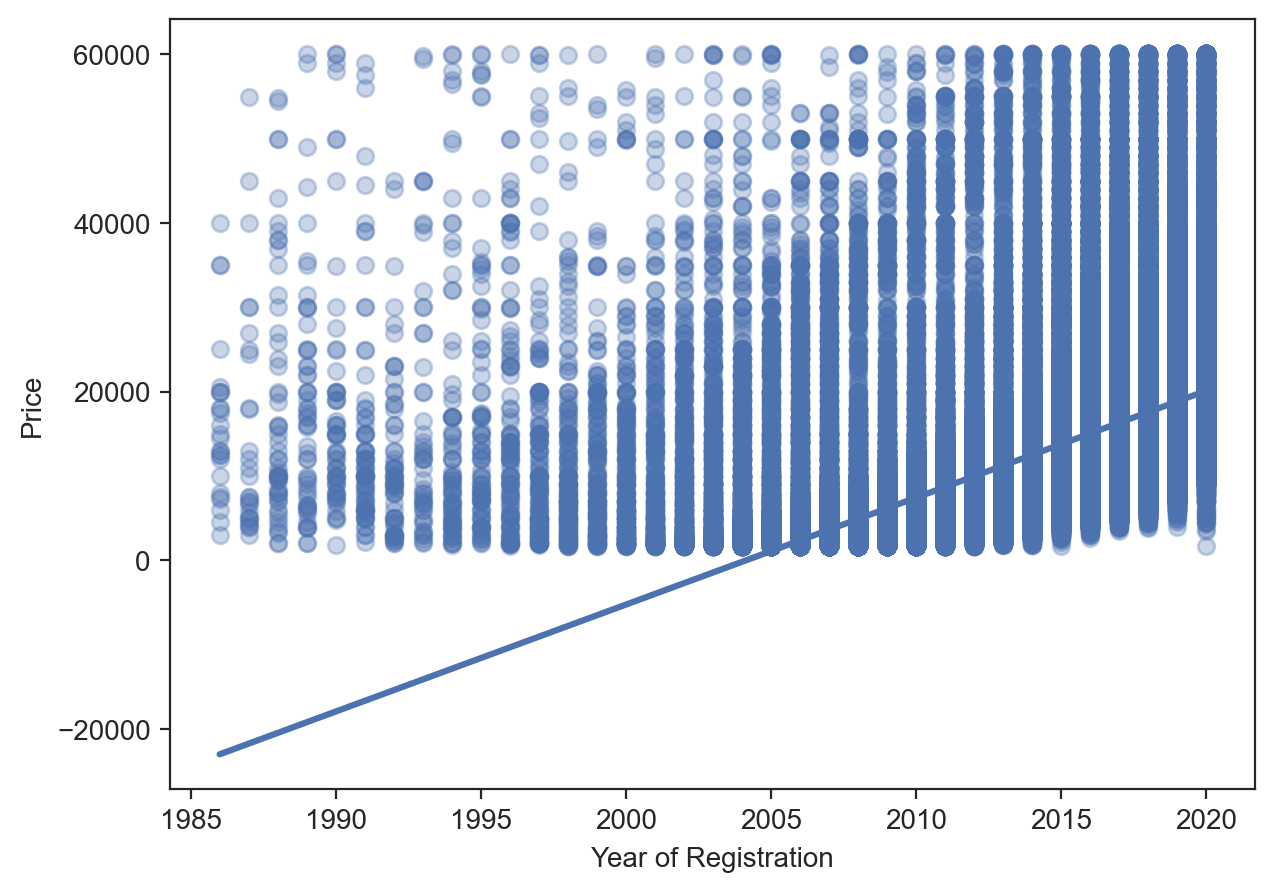

In [265]:
fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(
    data=machine, x='Year of Registration', y='Price',
    scatter_kws=dict(alpha=0.3), ax=ax, ci=None
);

In [266]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import RFECV
random_seed = 42
import shap
from sklearn.ensemble import VotingRegressor

In [267]:
shap.initjs()

In [268]:
def plot_est_feat_imp_barh(est, feat_names, ax=None, top_feat_k=10, style_kws={}):
    """ """
    if ax is None:
        fig, ax = plt.subplots()

    return pd.Series(
        est.feature_importances_,
        index=feat_names
    ).sort_values().tail(top_feat_k).plot.barh(**style_kws)

In [269]:
from sklearn.base import BaseEstimator, TransformerMixin

In [270]:
infrequent_model = machine['Model'].value_counts()[machine['Model'].value_counts() < 2].index.tolist()
infrequent_make = machine['Make'].value_counts()[machine['Make'].value_counts() < 2].index.tolist()

In [271]:
from sklearn.base import BaseEstimator, TransformerMixin

class GroupInfrequentCategories(BaseEstimator, TransformerMixin):
    def __init__(self, infrequent_categories):
        self.infrequent_categories = infrequent_categories
        self.feature_names_out_ = None

    def fit(self, X, y=None):
        self.feature_names_out_ = list(X.columns)  # Store the input feature names
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Apply transformations
        X_copy.loc[X_copy['Model'].isin(self.infrequent_categories), 'Model'] = 'OtherModel'
        X_copy.loc[X_copy['Make'].isin(self.infrequent_categories), 'Make'] = 'OtherMake'
        return X_copy

    def get_feature_names_out(self, input_features=None):
        # Return the stored output feature names
        return self.feature_names_out_


In [272]:
# Get the number of samples in your dataset
num_samples = len(machine)

# Calculate the number of samples to select (10% of the total)
num_samples_to_select = int(0.2 * num_samples)

# Generate random indices to select 10% of the data
random_indices = np.random.choice(num_samples, num_samples_to_select, replace=False)

# Select 10% of the data based on the random indices
random_10_percent_data = machine.iloc[random_indices]

In [273]:
#machine1 = machine[machine['Price'] < 30000]

In [274]:
#X1, y1 = machine1[cat_feat + num_feat], machine1['Price']

In [275]:
#X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=23343)

In [276]:
kfold_cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [277]:
#random_10_percent_data.head(5)

In [278]:
target = 'Price'
cat_feat = ['Colour', 'Make', 'Model', 'Bodytype','Fueltype']
num_feat = ['Year of Registration', 'Mileage', 'Vehicle condition', 'Milesperyear', 'Age']
#'Crossover car and van' Regcode

In [279]:
X, y = machine[cat_feat + num_feat], machine['Price']

In [280]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23343)

In [281]:
#X, y = random_10_percent_data[cat_feat + num_feat], random_10_percent_data['Price']

In [282]:
X_train.columns

Index(['Colour', 'Make', 'Model', 'Bodytype', 'Fueltype',
       'Year of Registration', 'Mileage', 'Vehicle condition', 'Milesperyear',
       'Age'],
      dtype='object')

In [283]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler())
    ]
)

In [284]:
numeric_transformer

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,feature_range,"(0, ...)"


In [285]:
numeric_transformer1 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()), 
        ("poly", PolynomialFeatures(3))  # Fixed syntax here
    ]
)


In [286]:
numeric_transformer1

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,feature_range,"(0, ...)"


In [287]:
numeric_transformer32 = Pipeline(
    steps=[
        ('imputer', KNNImputer(n_neighbors=2)),
        ("scaler", MinMaxScaler()), 
        ("poly", PolynomialFeatures(3))  
    ]
)


In [288]:
numeric_transformer4 = Pipeline(
    steps=[
        ('imputer', KNNImputer(n_neighbors=2)),
        ("scaler", MinMaxScaler())
    ]
)
#'imputer', KNNImputer(n_neighbors=2)

In [289]:
numeric_transformer4

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,2
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [290]:
numeric_transformer5 = Pipeline(
    steps=[
        ('imputer', KNNImputer(n_neighbors=2)),
        ("scaler", MinMaxScaler()), ("poly", PolynomialFeatures(3))
    ]
)

In [291]:
numeric_transformer5

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,n_neighbors,2
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [292]:
categorical_transformer1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ('infrequent_categories', GroupInfrequentCategories(infrequent_model)),
    ("encoder", TargetEncoder(target_type='continuous'))
])


In [293]:
categorical_transformer1

,steps,"[('imputer', ...), ('infrequent_categories', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,infrequent_categories,"['Turbo RT', 'Primastar', ...]"


In [294]:
categorical_transformer10 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(target_type='continuous')),
    ("scaler", MinMaxScaler())
    #("poly", PolynomialFeatures(degree=degree))
])
#"scaler", MinMaxScaler())

In [295]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_feat),
        ("cat", categorical_transformer1, cat_feat),
    ]
)

In [296]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [297]:
categorical_transformer12 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(target_type='continuous'))
])


In [298]:
#preprocessor5 = ColumnTransformer(
   # transformers=[
        #("num", numeric_transformer1, num_feat),
        #("cat", categorical_transformer1, cat_feat),
   # ]
#)

In [299]:
preprocessor5 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer32, num_feat),
        ("cat", categorical_transformer12, cat_feat),
    ]
)

In [300]:
preprocessor5

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,2
,weights,'uniform'


In [301]:
numeric_transformer6 = Pipeline(
    steps=[
        ('imputer', KNNImputer(n_neighbors=2)),
        ("scaler", MinMaxScaler()), ("poly", PolynomialFeatures(4))
    ]
)

In [302]:
numeric_transformer33 = Pipeline(
    steps=[
        ('imputer', KNNImputer(n_neighbors=2)),
        ("scaler", MinMaxScaler()), 
        ("poly", PolynomialFeatures(4))  # Fixed syntax here
    ]
)


In [303]:
preprocessor6 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer33, num_feat),
        ("cat", categorical_transformer1, cat_feat),
    ]
)

In [304]:
numeric_transformer10 = Pipeline(
    steps=[
        ('imputer', KNNImputer(n_neighbors=2)),
        ("poly", PolynomialFeatures(3)),
        ("scaler", MinMaxScaler())
          # Fixed syntax here
    ]
)



In [305]:
preprocessor50 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer10, num_feat),
        ("cat", categorical_transformer10, cat_feat),
    ]
)


In [306]:
preprocessor50

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,2
,weights,'uniform'


In [307]:
preprocessor4 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer5, num_feat),
        ("cat", categorical_transformer1, cat_feat),
    ]
)

In [308]:
preprocessor4

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,2
,weights,'uniform'


In [309]:
preprocessor1 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer5, num_feat),
        ("cat", categorical_transformer1, cat_feat),
    ]
)

In [310]:
preprocessor1

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,2
,weights,'uniform'


In [311]:
preprocessor5

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,2
,weights,'uniform'


In [312]:
numeric_transformer11 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
       # ("poly", PolynomialFeatures(3))
        #("scaler", MinMaxScaler())
         
    ]
)



In [313]:
preprocessor51 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer4, num_feat),
        ("cat", categorical_transformer10, cat_feat),
    ]
)

In [314]:
def custom_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    return r2, -mae  

In [315]:
def plot_actual_vs_predicted_joint(est, X, y):
    # """Needs tweaking, of course; similar to what latest sklearn versions can do; this one
    # uses seaborn's jointplot with the nice marginal histograms"""
    import seaborn as sns

    g = sns.jointplot(x=y, y=est.predict(X), alpha=0.5)
    # for the diagonal of correct predictions, need the lower-left and upper-right limits
    x0, x1 = g.ax_joint.get_xlim()
    y0, y1 = g.ax_joint.get_ylim()
    lims = [min(x0, y0), max(x1, y1)]  # more generic solution
    lims = [0, max(x1, y1)]
    g.ax_joint.set(xlim=lims, ylim=lims)
    g.ax_joint.plot(lims, lims, ':k', alpha=0.3, lw=1)
    g.ax_joint.set(xlabel='True Target Value')
    g.ax_joint.set(ylabel='Predicted Target Value')

    return g, g.ax_joint

In [316]:
#lasso_regressor = Lasso( alpha = 0.1, random_state=random_seed)

In [317]:
lasso_regressor = Lasso( random_state=random_seed) #will need to define once done

In [318]:
regre = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),  
        ("regr", Lasso())  
    ]
)

In [319]:
regre

,steps,"[('preprocessor', ...), ('regr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [320]:
regre.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [321]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regre, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

KeyboardInterrupt: 

In [ ]:
regre1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),  
        ("regr", Lasso())  
    ]
)

In [ ]:
regre1.fit(X_train, y_train)

In [ ]:
lasso_cv = LassoCV()

In [ ]:
regree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),  # Your preprocessor
        #("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1,
        #                                      scoring='neg_mean_squared_error',
        #                                      cv=5,
        #                                      n_features_to_select='auto')),  
        ("regr", Lasso())  
    ]
)

In [ ]:
regree.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regree, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso2 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA()),
    #("featsel", SelectKBest(score_func=mutual_info_regression, k= 10)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso2.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
regr_bestk1 = Pipeline([
    ("preprocessor", preprocessor5),
    ("featsel", SelectKBest(score_func=mutual_info_regression, k= 10)),
    ("regressor", lasso_regressor)
])

In [ ]:
regr_bestk1

In [ ]:
regr_bestk1.fit(X_train, y_train)

In [ ]:
regr_bestk1['featsel'].get_feature_names_out()

In [ ]:
#regr_bestk1['featsel'].transform(
   # regr_bestk['preprocessor'].transform(X_train)
#).head()

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_bestk1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))


In [ ]:
regr_rfe = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ("regr", Lasso())
    ]
)
#this works withoutfeatsel

In [ ]:
regr_rfe

In [ ]:
regr_rfe.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_rfe, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
regr_rfe['featsel'].get_feature_names_out()

In [ ]:
regr_rfe['regr'].coef_

In [ ]:
regr_sfs = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),  
        ("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1,
                                              scoring='neg_mean_squared_error',
                                              cv=5,
                                              n_features_to_select='auto')),  
        ("regr", Lasso())  
    ]
)

In [ ]:
regr_sfs

In [ ]:
regr_sfs.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_sfs, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso2 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=2)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso2

In [ ]:
lasso2.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso3 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=3)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso3.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso3, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso4 = Pipeline([
    ("preprocessor", preprocessor1),
    ("pca", PCA(n_components=4)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso4.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso4, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
preprocessed_features = lasso5['preprocessor'].transform(X_train)


feature_names_after_preprocessing = lasso5['preprocessor'].get_feature_names_out()


num_features = len(feature_names_after_preprocessing)
print("Number of features after preprocessing (including polynomial features):", num_features)

In [ ]:
lasso5 = Pipeline([
    ("preprocessor", preprocessor50),
    ("pca", PCA(n_components=21)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso5.fit(X_train, y_train)

In [ ]:
predictions = lasso5.predict(X_train)


mae = mean_absolute_error(y_train, predictions)
print("Mean Absolute Error:", mae)

In [ ]:
pca1 = PCA(n_components=40)
principal_components = pca.fit_transform(your_data)

In [ ]:
pca = lasso5.named_steps['pca']

In [ ]:
# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot the variance explained by each principal component
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Variance Explained by Principal Components')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
principal_components = pca.components_
pca.components_
#component_contributions_df.head(50)

In [ ]:
preprocessor5

In [ ]:
data_transformation5 = lasso5['preprocessor'].transform(X_test)

In [ ]:
data_transformation5

In [ ]:
data_transformation5 = lasso5['preprocessor5'].transform(X_test)

In [ ]:
#LASSO PCA

In [ ]:
lassoo = Pipeline([
    ("preprocessor", preprocessor5),
    #("pca", PCA(n_components=10)),
    ("regressor", lasso_regressor)
])

In [ ]:
lassoo.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lassoo, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso6 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=10)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso6.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso6, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso7 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=11)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso7.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso7, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso8 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=12)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso8.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso8, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso9 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=13)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso9.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso9, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso10 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=15)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso10.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso10, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso11 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=16)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso11.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso11, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso12 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=17)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso12.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso12, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso13 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=18)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso13.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso13, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso14 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=19)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso14.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso14, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso15 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=20)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso15.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso15, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso16 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=21)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso16.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso16, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
lasso17 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=22)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso17.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso17, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
preprocessor5

In [ ]:
lasso18 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=23)),
    ("regressor", lasso_regressor)
])

In [ ]:
lasso18.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    lasso18, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
jason

In [ ]:
regr_test = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
       # ("pca", PCA(n_components=22)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ("regr", Lasso())
    ]
)

In [ ]:
regr_test

In [ ]:
regr_test.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_test, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
regr_sfs1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
       # ("pca", PCA(n_components=15)),
        ("featsel", SequentialFeatureSelector(LinearRegression(),
                                              n_jobs=-1,
                                              scoring='neg_mean_squared_error',
                                              cv=5,
                                              n_features_to_select='auto')),
        ("regr", Lasso())  
    ]
)

In [ ]:
regr_sfs1.fit(X_train, y_train)
#obtain final scores again using pca 15

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_sfs1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
regr_test1

In [ ]:
regr_test1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=15)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ("regr", Lasso())
    ]
)

In [ ]:
preprocessor5

In [ ]:
regr_test1.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_test1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
rfecv_transformer = regr_test1.named_steps['featsel']


num_remaining_features_after_pca = rfecv_transformer.n_features_

print("Number of remaining features after PCA:", num_remaining_features_after_pca)

In [ ]:
explained_variance_ratios1 = regr_test1['pca'].explained_variance_ratio_


plt.plot(np.cumsum(explained_variance_ratios1))


plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')


num_components = len(explained_variance_ratios1)
plt.xticks(np.arange(0, num_components1, step=5))  
plt.xlim(0, num_components)  

plt.show()

In [ ]:
num_components1 = 61

In [ ]:
regr_test2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor6),
        ("pca", PCA(n_components=35)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ("regr", Lasso())
    ]
)

In [ ]:
regr_test2.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_test2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
regr_sfs2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=15)),
        ("featsel", SequentialFeatureSelector(LinearRegression(),
                                              n_jobs=-1,
                                              scoring='neg_mean_squared_error',
                                              cv=5,
                                              n_features_to_select='auto')),
        ("regr", Lasso())  # Final Lasso regressor
    ]
)

In [ ]:
regr_sfs2.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_sfs2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
regr_bestk2 = Pipeline([
    ("preprocessor", preprocessor5),
    ("pca", PCA(n_components=15)),
    ("featsel", SelectKBest(score_func=mutual_info_regression, k= 10)),
    ("regressor", lasso_regressor)
])

In [ ]:
regr_bestk2.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_bestk2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
stop here

In [ ]:
feature_names=X.columns.to_list()

In [ ]:
omari = pd.DataFrame(preprocessor.fit_transform(X_train, y_train),  
                     columns=preprocessor.get_feature_names_out())
                     #['year_of_registration', 'mileage', 'vehicle_condition', 'standard_colour', 'standard_make', 'standard_model', 'body_type','fuel_type'])
omari.head(5)

In [ ]:
randomforest_pipeline2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=25, n_estimators=120, min_samples_leaf=5, n_jobs=-1))
    ]
)

#randomforest_pipeline2.fit(X_train, y_train)


In [ ]:
randomforest_pipeline2

In [ ]:
randomforest_pipeline2.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipeline3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=25, n_estimators=120, min_samples_leaf=5, n_jobs=-1))
    ]
)

In [ ]:
randomforest_pipeline3

In [ ]:
randomforest_pipeline3.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline3, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#RANDOM FOREST

In [ ]:
random_forest_regressor = RandomForestRegressor(
    random_state=random_seed,
    bootstrap=True,
    max_depth=18,
    n_estimators=140,
    min_samples_leaf=5,
    n_jobs=-1
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
randomforestsfs = Pipeline(
    steps=[
        ("preprocessor", preprocessor51), 
        ("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1)),
        # ("pca", PCA(n_components=10)), 
        ('regressor', random_forest_regressor)
    ])

In [ ]:
randomforestsfs

In [ ]:
randomforestsfs.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforestsfs, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
X_train.shape

In [ ]:
randomforestsfs1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=10)),  # Your preprocessor
        ("featsel", SequentialFeatureSelector(
            LinearRegression(),  # SequentialFeatureSelector for feature selection
            n_jobs=-1
        )),
        ('regressor', random_forest_regressor)
    ]
)


In [ ]:
randomforestsfs1

In [ ]:
randomforestsfs1.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforestsfs1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforestrfe = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ('regressor', random_forest_regressor)
    ]
)

In [ ]:
randomforestrfe 

In [ ]:
randomforestrfe.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforestrfe, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipeline21 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=10)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        ('regressor', random_forest_regressor)
    ]
)

In [ ]:
randomforest_pipeline21.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline21, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipeline2132 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=10)),
        #("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        ('regressor', random_forest_regressor)
    ]
)

In [ ]:
randomforest_pipeline2132.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline2132, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipeline215 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        #("pca", PCA(n_components=10)),
        #("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        ('regressor', random_forest_regressor)
    ]
)

In [ ]:
randomforest_pipeline215.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline215, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforestrfe1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=12)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ('regressor', random_forest_regressor)
    ]
)

In [ ]:
randomforest_pipeline212 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=9)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        ('regressor', random_forest_regressor)
    ]
)

In [ ]:
randomforest_pipeline212.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline212, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforestrfe1.fit(X_train, y_train)

In [ ]:
#need to get polynomial preprocessor, pca=12 and run them in through feature selector. score to beat is 1647

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforestrfe1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforestk = Pipeline([
    ("preprocessor", preprocessor5),
    ("featsel", SelectKBest(score_func=mutual_info_regression, k= 10)),
    ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
])

In [ ]:
randomforestk.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforestk, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=2)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)

In [ ]:
randomforest_pipelinee2.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=3)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee3

In [ ]:
randomforest_pipelinee3.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee3, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee4 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=4)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee4.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee4, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee5 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=5)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee5.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee5, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee6 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=6)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee6.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee6, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee7 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=7)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee7.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee7, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee8 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=8)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee8.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee8, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee9 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=9)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee9.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee9, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee10 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=10)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=25, n_estimators=120, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee10.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee10, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee11 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=11)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee11.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee11, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee12 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=12)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee12.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee12, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee13 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=13)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee13.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee13, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee14 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=14)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee14.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee14, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
randomforest_pipelinee15 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=14)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=22, n_estimators=90, min_samples_leaf=5, n_jobs=-1))
    ]
)#n_components

In [ ]:
randomforest_pipelinee15.fit(X_train, y_train)

In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipelinee15, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
explained_variance_ratios = randomforest_pipeline8['pca'].explained_variance_ratio_


plt.plot(np.cumsum(explained_variance_ratios))


plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')


num_components = len(explained_variance_ratios)
plt.xticks(np.arange(0, num_components, step=2)) 
plt.xlim(0, num_components) 


plt.show()

In [ ]:
xgb1 = Pipeline(
  steps=[
        ("preprocessor", preprocessor),
      ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=1,
    gamma=0,
    gpu_id=None,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=13,
    min_child_weight=1,
    missing=np.nan,
    monotone_constraints=None,
    n_estimators=100,
    n_jobs= -1,
    num_parallel_tree=None,
    #random_state=None,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=1,
    tree_method=None,
    validate_parameters=None,
    verbosity=None
))])

In [ ]:
xgb1

In [ ]:
xgb1.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgb1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgb = Pipeline(
  steps=[
        ("preprocessor", preprocessor5),
      ('regressor', XGBRegressor(random_state=random_seed)
)])

In [ ]:
xgb

In [ ]:
xgb.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgb, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=1)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb1.fit(X_train, y_train)

In [ ]:
xgbb1.score(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=2)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb2.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=3)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb3.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb3, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb4 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=4)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb4.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb4, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb5 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=5)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb5.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb5, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb6 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=6)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb6.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb6, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb7 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=7)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb7.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb7, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb8 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=8)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb8.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb8, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb9 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=9)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb9.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb9, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb10 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=10)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components. #code will fail after here

In [ ]:
xgbb10.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb10, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
#xgbsfs

In [ ]:
xgbb11 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=11)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb11.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb11, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
preprocessor9

In [ ]:
preprocessor50

In [ ]:
numeric_transformer11 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
       # ("poly", PolynomialFeatures(3))
        #("scaler", MinMaxScaler())
          # Fixed syntax here
    ]
)
preprocessor51 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer11, num_feat),
        ("cat", categorical_transformer10, cat_feat),
    ]
)


In [ ]:
preprocessor51 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer11, num_feat),
        ("cat", categorical_transformer10, cat_feat),
    ]
)


In [ ]:
preprocessor51

In [ ]:
xgbb12 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=12)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb12.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb12, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb13 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=13)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb13.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb13, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb14 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=14)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb14.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb14, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbb15 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=15)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=10,
    min_child_weight=3,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=1,
    reg_lambda=1
))])#n_components

In [ ]:
xgbb15.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbb15, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbfinal = Pipeline(
    steps=[
        ("preprocessor", preprocessor1),
        ('regressor', XGBRegressor(
            learning_rate=0.1,  
            n_estimators=150,  
            max_depth=11, 
            min_child_weight=5,  
            subsample=1.0,  
            colsample_bytree=1.0,  
            reg_alpha=1.0,  
            reg_lambda=1.0,  
            gamma=0.5,  
            random_state=random_seed  
        ))
    ]
)

In [ ]:
xgbfinal

In [ ]:
xgbfinal.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbfinal, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mea
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
param_grid1 = {
    'regressor__learning_rate': [ 0.1, 0.01],  
    'regressor__n_estimators': [100, 125, 150, 175, 200,],  
    'regressor__max_depth': [8, 9, 10, 11, 12, 13, 14, 15],  
    'regressor__min_child_weight': [1, 3, 5, 7],  
    'regressor__subsample': [1.0],  
    'regressor__colsample_bytree': [1.0],  
    'regressor__reg_alpha': [ 0.1, 1.0],  
    'regressor__reg_lambda': [ 0.1, 1.0],  
    'regressor__gamma': [0, 0.1, 0.5],  
    #'regressor__scale_pos_weight': [1, 2, 3]  
}

In [ ]:
pipe_cv2 = GridSearchCV(
    xgb,
    param_grid=param_grid1,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose = 50,
    return_train_score=True
)

In [ ]:
add2 = pipe_cv2.fit(X_train, y_train)

In [ ]:
gs_results1 = pipe_cv2.cv_results_

In [ ]:
# Convert the results to a pandas DataFrame
add2_df = pd.DataFrame(gs_results)
selected_columns = [
    'mean_test_score', 'rank_test_score', 'param_regressor__max_depth', 'param_regressor__learning_rate', 'param_regressor__min_child_weight',  'param_regressor__n_estimators',
    'param_regressor__reg_lambda', 'param_regressor__reg_alpha',
    'mean_train_score', 'param_regressor__n_estimators'
    #'mean_test_score', 'std_test_score', 'rank_test_score', #'param_regressor__bootstrap', 'param_regressor__max_depth', #'param_regressor__min_samples_leaf', 'param_regressor__n_estimators'
] 
add2_df = add2_df[selected_columns].sort_values('rank_test_score').head(50)

In [ ]:
add2_df = pd.DataFrame(gs_results1)

In [ ]:
add2_df

In [ ]:
selected_columns1 = [
    'rank_test_score','mean_test_score', 'mean_train_score', 'param_regressor__max_depth', 'param_regressor__n_estimators', 'param_regressor__learning_rate', 'param_regressor__min_child_weight', #'param_regressor__n_estimators',
    'param_regressor__reg_lambda', 'param_regressor__reg_alpha' #'rank_train_score' #'param_regressor__n_estimators' 'param_regressor__n_estimators'
    #'mean_train_score', #'std_train_score', 'param_regressor__gamma',
    #'mean_test_score', 'std_test_score', 'rank_test_score', #'param_regressor__bootstrap', 'param_regressor__max_depth', #'param_regressor__min_samples_leaf', 'param_regressor__n_estimators'
] 

In [ ]:
selected_columns1 = [
    'mean_test_score', 'mean_train_score', 'rank_test_score', 'regressor__max_depth', 'regressor__learning_rate', 'regressor__min_child_weight', 'regressor__n_estimators',
    'regressor__reg_lambda', 'regressor__reg_alpha', 'regressor__gamma'
]


In [ ]:
add2_df = add2_df[selected_columns1].sort_values('rank_test_score').head(50)

In [ ]:
add2_df.to_csv('gridsearch_results.csv', index=False)

In [ ]:
add2_df.head(50)

In [ ]:
add4_df = add2_df[selected_columns1].sort_values('rank_train_score').head(50)



In [ ]:
run from here

In [ ]:
XGBRegressor = XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.1,
    max_delta_step=None,
    max_depth=9,
    min_child_weight=1,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=0.1,
    reg_lambda=1)

In [ ]:
#with pca and sfs
xgb = Pipeline(
    steps=[
        ("preprocessor", preprocessor51), 
        #("pca", PCA(n_components=10)),# Your preprocessor
        #("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1)),
        ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
    ]
)

In [ ]:
xgbsfs.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgb, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
#with pca and sfs
xgb1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51), 
        ("pca", PCA(n_components=10)),# Your preprocessor
        #("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1)),# SequentialFeatureSelector for feature selection
        ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
    ]
)

In [ ]:
xgb1.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgb1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
#without pca and sfs
xgbsfs = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),  # Your preprocessor
        ("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1)),# SequentialFeatureSelector for feature selection
        ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
    ]
)

In [ ]:
xgbsfs

In [ ]:
xgbsfs.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbsfs, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
#with pca and sfs
xgbsfs1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51), 
        ("pca", PCA(n_components=10)),# Your preprocessor
        ("featsel", SequentialFeatureSelector(LinearRegression(), n_jobs=-1)),# SequentialFeatureSelector for feature selection
        ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
    ]
)

In [ ]:
xgbsfs1.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbsfs1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbrfe= Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
    ]
)

In [ ]:
xgbrfe

In [ ]:
xgbrfe.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbrfe, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbrfe1= Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=10)),
        #("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
    ]
)

In [ ]:
xgbrfe1.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbrfe1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbk = Pipeline([
    ("preprocessor", preprocessor5),
    ("featsel", SelectKBest(score_func=mutual_info_regression, k= 10)),
    ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
])

In [ ]:
xgbk

In [ ]:
xgbk.fit(X_train, y_train)

In [ ]:
 # Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbk, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgbkk = Pipeline([
    ("preprocessor", preprocessor5),
   # ("featsel", SelectKBest(score_func=mutual_info_regression, k= 10)),
    ("pca", PCA()),
    ('regressor', XGBRegressor(random_state=random_seed, n_jobs=-1))
])

In [ ]:
xgbkk

In [ ]:
xgbkk.fit(X_train, y_train)

In [ ]:
 # Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgbkk, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
#plt.plot(
  #  np.cumsum(xgbkk['pca'].explained_variance_ratio_)
#)
#plt.xlabel('number of components')
#plt.ylabel('cumulative explained variance');

In [ ]:
#explained_variance_ratios = xgbk['pca'].explained_variance_ratio_


#plt.plot(np.cumsum(explained_variance_ratios))


#plt.xlabel('Number of Components')
#plt.ylabel('Cumulative Explained Variance')


#num_components = len(explained_variance_ratios)
#plt.xticks(np.arange(0, num_components, step=2))  
#plt.xlim(0, num_components)  

# Display the plot
#plt.show()

In [ ]:
randomforest_pipelinefinal.score(X_train, y_train), randomforest_pipelinefinal.score(X_test, y_test)

In [ ]:
randomforest_pipeline3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ('regressor', RandomForestRegressor(random_state=random_seed))
    ]
)


In [ ]:
preprocessor

In [ ]:
randomforest_pipeline3

In [ ]:
randomforest_pipeline3.fit(X_train, y_train)

In [ ]:
mean_absolute_error(y_test, randomforest_pipeline3.predict(X_test))

In [ ]:
param_grid2 = {
    'regressor__n_estimators': [ 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170], 
    'regressor__max_depth': [18, 19, 20, 21, 22, 23, 24, 25],  
    'regressor__min_samples_leaf': [ 5, 6, 7],  
    'regressor__bootstrap': [True]
    
}

In [ ]:
gs_cv = GridSearchCV(
    randomforest_pipeline3,  
    param_grid2,  
    cv=kfold_cv,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs = -1,
    verbose = 50
)

In [ ]:
ADD3 = gs_cv.fit(X_train, y_train)

In [ ]:
gs_results = gs_cv.cv_results_


add2_df = pd.DataFrame(gs_results)
selected_columns = [
    'param_regressor__max_depth', 'param_regressor__min_samples_leaf', 'param_regressor__n_estimators',
   # 'param_regressor___learning_rate',
    'mean_train_score', 'std_train_score',
    'mean_test_score', 'std_test_score', 'rank_test_score', 'param_regressor__bootstrap', 'param_regressor__max_depth', #'param_regressor__min_samples_leaf', 'param_regressor__n_estimators'
] 

In [ ]:
gs_results3 = gs_cv.cv_results_

In [ ]:
add3_df = pd.DataFrame(gs_results3)

In [ ]:
selected_columns = [
    'rank_test_score', 'mean_test_score', 'mean_train_score', 'param_regressor__max_depth', 'param_regressor__min_samples_leaf', 'param_regressor__n_estimators',
   # 'param_regressor___learning_rate',
    'std_train_score',
    'std_test_score', 'param_regressor__bootstrap'
] 

In [ ]:
add3_df = add3_df[selected_columns].sort_values('rank_test_score').head(50)

In [ ]:
add3_df.to_csv('randomforestgridsearch_results.csv', index=False)

In [ ]:
add3_df.head(50)

In [ ]:
xgb123 = Pipeline(
  steps=[
        ("preprocessor", preprocessor9),
      ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=1,
    gamma=0,
    gpu_id=None,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.300000012,
    max_delta_step=None,
    max_depth=13,
    min_child_weight=1,
    missing=np.nan,
    monotone_constraints=None,
    n_estimators=100,
    n_jobs= -1,
    num_parallel_tree=None,
    #random_state=None,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=1,
    tree_method=None,
    validate_parameters=None,
    verbosity=None
))])

In [ ]:
original_feature_names = preprocessor.get_feature_names_out()

In [ ]:
omari = pd.DataFrame(preprocessor.fit_transform(X_train, y_train),  
                     columns=preprocessor.get_feature_names_out())

In [ ]:
l
feature_importances = xgb123.named_steps['regressor'].feature_importances_


component_contributions = principal_components * feature_importances.reshape(-1, 1)


component_contributions_df = pd.DataFrame(component_contributions, columns=original_feature_names)


component_contributions_df.head(50)


In [ ]:
pca = xgb123.named_steps['pca']
original_feature_names = preprocessor9.get_feature_names_out()
principal_components = pca.components_

In [ ]:
plt.matshow(pca.components_, cmap='coolwarm')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components");

In [ ]:
feature_importances = xgb123.named_steps['regressor'].feature_importances_


pca = xgb123.named_steps['pca']
principal_components = pca.components_


component_importances = principal_components * feature_importances.reshape(-1, 1)


component_importances_df = pd.DataFrame(component_importances, columns=original_feature_names)


component_importances_df.head(10)

In [ ]:
plt.matshow(pca.components_, cmap='coolwarm')
plt.yticks([0, 1, 2], ["First component", "Second component", "Third component"])
plt.colorbar()
plt.xticks(range(len(original_feature_names)),
           original_feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components");

In [ ]:
n_components = 10


plt.figure(figsize=(15, 10))
plt.matshow(pca.components_[:n_components], cmap='plasma')
plt.yticks(range(n_components), [f"Component {i+1}" for i in range(n_components)])
plt.colorbar()


plt.xticks(range(len(original_feature_names)), original_feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal Components")
plt.title("Principal Components vs. Original Features")
plt.show()

In [ ]:
principle_components

In [ ]:
original_feature_names = preprocessor9.get_feature_names_out()

In [ ]:
original_feature_names

In [ ]:
principal_components = pca.components_

In [ ]:
pca.components_

In [ ]:
component_contributions_df.head(50)

In [ ]:
pca = randomforest_pipeline212.named_steps['pca']
principal_components = pca.components_
pca.components_
component_contributions_df.head(50)

In [ ]:
xgb1234 = Pipeline(
    steps=[
        ("preprocessor", preprocessor51),
        ("pca", PCA(n_components=10)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.1,
    max_delta_step=None,
    max_depth=9,
    min_child_weight=1,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=0.1,
    reg_lambda=1
))])#n_components

In [ ]:
xgb1234.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgb1234, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))


In [ ]:
feature_importances1 = xgb1234.named_steps['regressor'].feature_importances_


pca1 = xgb1234.named_steps['pca']
principal_components1 = pca1.components_


component_importances1 = principal_components1 * feature_importances1.reshape(-1, 1)


component_importances_df1 = pd.DataFrame(component_importances1, columns=original_feature_names)


component_importances_df1.head(10)

In [ ]:
n_components = 10

# Plot the principal components
plt.figure(figsize=(15, 10))
plt.matshow(pca1.components_[:n_components], cmap='coolwarm')
plt.yticks(range(n_components), [f"Component {i+1}" for i in range(n_components)])
plt.colorbar()

# Rotate x-axis labels for better readability
plt.xticks(range(len(original_feature_names)), original_feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal Components")
plt.title("Principal Components vs. Original Features")
plt.show()

In [ ]:
regr_sfs1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=15)),
        ("featsel", SequentialFeatureSelector(LinearRegression(),
                                              n_jobs=-1,
                                              scoring='neg_mean_squared_error',
                                              cv=5,
                                              n_features_to_select='auto')),
        ("regr", Lasso())  
    ]
)

In [ ]:
regr_sfs1.fit(X_train, y_train)

In [ ]:
regr_sfs1

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_sfs1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))
#it has performed worse with a knn inmputer

In [ ]:
PredictionErrorDisplay.from_estimator(
    regr_sfs1, X_test, y_test, kind="actual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);
plt.savefig('gfgfg.jpeg')

In [ ]:
explainer3 = shap.Explainer(regr_sfs1["regr"])

In [ ]:
data_transformation2 = randomforest_pipeline212['preprocessor'].transform(X_test)
data_transformation2 = randomforest_pipeline212.named_steps['featsel'].transform(data_transformation2)


In [ ]:
shap_values3 = explainer(data_transformation2)

In [ ]:
shap.plots.beeswarm(shap_values3)
plt.savefig('global randomforest.png')

In [ ]:
shap.plots.waterfall(shap_values3[5])
plt.savefig('waterfall_plot.png')

In [ ]:
explained_variance_ratios = regr_sfs1['pca'].explained_variance_ratio_


plt.plot(np.cumsum(explained_variance_ratios))


plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')


num_components = len(explained_variance_ratios)
plt.xticks(np.arange(0, num_components, step=2)) 
plt.xlim(0, num_components) 

# Display the plot
plt.show()

In [ ]:
FINAL MODEL PERFORMANCES - RUN FROM HERE

In [322]:
regr_test1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("pca", PCA(n_components=15)),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        #('poly', PolynomialFeatures((3, 3), include_bias=False)),
        ("regr", Lasso())
    ]
)

In [323]:
regr_test1.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    regr_test1, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
rfecv_transformer = regr_test1.named_steps['featsel']


num_remaining_features_after_pca = rfecv_transformer.n_features_

print("Number of remaining features after PCA:", num_remaining_features_after_pca)

In [ ]:
explained_variance_ratios1 = regr_test1['pca'].explained_variance_ratio_


plt.plot(np.cumsum(explained_variance_ratios1))


plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')


num_components = len(explained_variance_ratios1)
plt.xticks(np.arange(0, num_components1, step=5)) 
plt.xlim(0, num_components)  


plt.show()

In [ ]:
preprocessor9 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer4, num_feat),
        ("cat", categorical_transformer1, cat_feat),
    ]
)

In [ ]:
preprocessor9

In [ ]:
xgb123 = Pipeline(
    steps=[
        ("preprocessor", preprocessor9),
        ("pca", PCA(n_components=10)),
        ('regressor', XGBRegressor(random_state=random_seed, objective='reg:squarederror',
    base_score=None,
    booster='gbtree',
    gamma=0.5,
    importance_type='gain',
    interaction_constraints=None,
    learning_rate=0.1,
    max_delta_step=None,
    max_depth=9,
    min_child_weight=1,
    n_estimators=175,
    n_jobs= -1,
    reg_alpha=0.1,
    reg_lambda=1
))])#n_components

In [ ]:
xgb123['pca'].get_feature_names_out()

In [ ]:
xgb123.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    xgb123, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
xgb123

In [ ]:
original_feature_names = xgb123.named_steps['preprocessor'].get_feature_names_out()


In [ ]:

pca_component_names = [f"PCA_Component_{i+1}" for i in range(10)]  

pca_feature_mapping = dict(zip(pca_component_names, original_feature_names))

print(pca_feature_mapping)

In [ ]:
explainer2 = shap.Explainer(xgb123["regressor"])


In [ ]:
data_transformation3 = xgb123.named_steps['preprocessor'].transform(X_test)
data_transformation3 = xgb123.named_steps['pca'].transform(data_transformation3)


In [ ]:
shap_values1 = explainer2(data_transformation3)

In [ ]:
shap.plots.waterfall(shap_values1[5], feature_names=pca_feature_mapping)
plt.savefig('waterfall_plotlocalxgb.png')

In [ ]:
shap.plots.waterfall(shap_values1[5])
plt.savefig('waterfall_plotlocalxgb.png')

In [ ]:

#global xgb
shap.plots.beeswarm(shap_values1)
plt.savefig('global xgb.png')

In [ ]:
explained_variance_ratios = xgb123['pca'].explained_variance_ratio_


plt.plot(np.cumsum(explained_variance_ratios))


plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')


num_components = len(explained_variance_ratios)
plt.xticks(np.arange(0, num_components, step=2)) 
plt.xlim(0, num_components)  

# Display the plot
plt.show()

In [ ]:
preprocessor9

In [ ]:
randomforest_pipeline212 = Pipeline(
    steps=[
        ("preprocessor", preprocessor9),
        ("featsel", RFECV(LinearRegression(), step=1, cv=5, n_jobs=-1)),
        ('regressor', RandomForestRegressor(random_state=random_seed, bootstrap=True, max_depth=18, n_estimators=140, min_samples_leaf=5, n_jobs=-1))
    ]
)

In [ ]:
randomforest_pipeline212.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    randomforest_pipeline212, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
PredictionErrorDisplay.from_estimator(
    randomforest_pipeline212, X_test, y_test, kind="actual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);
plt.savefig('randomforest.jpeg')

In [ ]:
data_transformation2 = randomforest_pipeline212['preprocessor'].transform(X_test)
data_transformation2 = randomforest_pipeline212.named_steps['featsel'].transform(data_transformation2)

In [ ]:
selected_feature_indices = randomforest_pipeline212.named_steps['featsel'].get_support()


original_feature_names = randomforest_pipeline212.named_steps['preprocessor'].get_feature_names_out()


selected_feature_name1 = [original_feature_names[i] for i, selected in enumerate(selected_feature_indices) if selected]


transformed_data_with_names1 = pd.DataFrame(data_transformation2, columns=selected_feature_name1)

In [ ]:
transformed_data_with_names1

In [ ]:
explainer = shap.Explainer(randomforest_pipeline212["regressor"])


In [ ]:
data_transformation2 = randomforest_pipeline212['preprocessor'].transform(X_test)
data_transformation2 = randomforest_pipeline212.named_steps['featsel'].transform(data_transformation2)

In [ ]:
selected_feature_names = randomforest_pipeline212.named_steps['featsel'].get_feature_names_out()

transformed_data_with_names = pd.DataFrame(data_transformation2, columns=selected_feature_names)

In [ ]:
transformed_data_with_names 

In [ ]:
shap_values = explainer(transformed_data_with_names1)

In [ ]:
shap.plots.beeswarm(shap_values)
plt.savefig('global randomforest.png')


In [ ]:
#individual instance
shap.plots.waterfall(shap_values[5])
plt.savefig('waterfall_plot.png')

In [ ]:
fig, ax = plt.subplots(figsize=(15,15), constrained_layout=True)
PartialDependenceDisplay.from_estimator(
    (randomforest_pipeline212["regressor"]), transformed_data_with_names1,
    features=['num__Year of Registration', 'num__Mileage', 'num__Age', 'num__Vehicle condition', 'num__Milesperyear', 'cat__Colour', 'cat__Make', 'cat__Model', 'cat__Bodytype', 'cat__Fueltype'],
    kind='average', grid_resolution=20000, ax=ax, n_cols=2
)

In [ ]:
fig, ax = plt.subplots(figsize=(15,15), constrained_layout=True)
PartialDependenceDisplay.from_estimator(
    (randomforest_pipeline212["regressor"]), transformed_data_with_names1,
    features=['num__Year of Registration', 'num__Mileage', 'num__Age', 'cat__Make', 'cat__Model', 'num__Vehicle condition'],
    kind='average', grid_resolution=20000, ax=ax, n_cols=2
)

In [ ]:
fig.savefig('partial_dependence_plot.jpeg')

In [ ]:
fig, ax = plt.subplots(figsize=(5,5)) #constrained_layout=True)
PartialDependenceDisplay.from_estimator(
    (randomforest_pipeline212["regressor"]), transformed_data_with_names1,
    features=['num__Year of Registration', 'num__Mileage', 'num__Age', 'num__Vehicle condition', 'num__Milesperyear', 'cat__Colour', 'cat__Make', 'cat__Model', 'cat__Bodytype', 'cat__Fueltype'],
    kind='average', grid_resolution=50, ax=ax, n_cols=2
)

In [ ]:
from sklearn.inspection import plot_partial_dependence
import matplotlib.pyplot as plt

In [ ]:
print(sklearn.__version__)

In [ ]:
features = ['num__Year of Registration', 'num__Mileage', 'num__Age', 'num__Vehicle condition', 
            'num__Milesperyear', 'cat__Colour', 'cat__Make', 'cat__Model', 'cat__Bodytype', 'cat__Fueltype']

fig, axs = plt.subplots(nrows=len(features) // 2, ncols=2, figsize=(15, 15), constrained_layout=True)

for feature, ax in zip(features, axs.flatten()):
    plot_partial_dependence(randomforest_pipeline212["regressor"], transformed_data_with_names1, [feature], 
                            kind='average', grid_resolution=20000, ax=ax)
    ax.set_title(feature)

plt.show()

In [ ]:
data_transformation2

In [ ]:
#predicition error display for linear model

In [ ]:
ensemble = VotingRegressor(
    [
        ("xgb_regressor", xgb123),
        ('randomforestregressor', randomforest_pipeline212)
    ]
)
#ensemble.fit(X_train, y_train)

In [ ]:
ensemble

In [ ]:
ensemble.fit(X_train, y_train)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    ensemble, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

In [ ]:
PredictionErrorDisplay.from_estimator(
    ensemble, X_test, y_test, kind="actual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);
plt.savefig('ensemble.jpeg')

In [ ]:
ped = PredictionErrorDisplay.from_estimator(
    ensemble, X_test, y_test, kind="actual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
)

# Get predicted and true values
predicted_values = ped.ax_.collections[0].get_offsets()[:, 1]
true_values = ped.ax_.collections[0].get_offsets()[:, 0]

In [ ]:
param_grid_ensemble = {
    'randomforestregressor__regressor__n_estimators': [70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170],
    'randomforestregressor__regressor__max_depth': [18, 19, 20, 21, 22, 23, 24, 25],
    'randomforestregressor__regressor__min_samples_leaf': [5, 6, 7],
    'randomforestregressor__regressor__bootstrap': [True],
    'xgb_regressor__regressor__learning_rate': [0.1, 0.01],
    'xgb_regressor__regressor__n_estimators': [100, 125, 150, 175, 200],
    'xgb_regressor__regressor__max_depth': [8, 9, 10, 11, 12, 13, 14, 15],
    'xgb_regressor__regressor__min_child_weight': [1, 3, 5, 7],
    'xgb_regressor__regressor__subsample': [1.0],
    'xgb_regressor__regressor__colsample_bytree': [1.0],
    'xgb_regressor__regressor__reg_alpha': [0.1, 1.0],
    'xgb_regressor__regressor__reg_lambda': [0.1, 1.0],
    'xgb_regressor__regressor__gamma': [0, 0.1, 0.5]
}

In [ ]:
param_grid_ensemble = {
    'randomforestregressor__n_estimators': [70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170],
    'randomforestregressor__max_depth': [18, 19, 20, 21, 22, 23, 24, 25],
    'randomforestregressor__min_samples_leaf': [5, 6, 7],
    'randomforestregressor__bootstrap': [True],
    'xgb_regressor__learning_rate': [0.1, 0.01],
    'xgb_regressor__n_estimators': [100, 125, 150, 175, 200],
    'xgb_regressor__max_depth': [8, 9, 10, 11, 12, 13, 14, 15],
    'xgb_regressor__min_child_weight': [1, 3, 5, 7],
    'xgb_regressor__subsample': [1.0],
    'xgb_regressor__colsample_bytree': [1.0],
    'xgb_regressor__reg_alpha': [0.1, 1.0],
    'xgb_regressor__reg_lambda': [0.1, 1.0],
    'xgb_regressor__gamma': [0, 0.1, 0.5]
}

In [ ]:
param_grid_rf = {
    'randomforestregressor__n_estimators': [70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170],
    'randomforestregressor__max_depth': [18, 19, 20, 21, 22, 23, 24, 25],
    'randomforestregressor__min_samples_leaf': [5, 6, 7],
    'randomforestregressor__bootstrap': [True]
}

param_grid_xgb = {
    'xgb_regressor__learning_rate': [0.1, 0.01],
    'xgb_regressor__n_estimators': [100, 125, 150, 175, 200],
    'xgb_regressor__max_depth': [8, 9, 10, 11, 12, 13, 14, 15],
    'xgb_regressor__min_child_weight': [1, 3, 5, 7],
    'xgb_regressor__subsample': [1.0],
    'xgb_regressor__colsample_bytree': [1.0],
    'xgb_regressor__reg_alpha': [0.1, 1.0],
    'xgb_regressor__reg_lambda': [0.1, 1.0],
    'xgb_regressor__gamma': [0, 0.1, 0.5]
}


grid_search_rf = GridSearchCV(estimator=eclf, param_grid=param_grid_ensemble, verbose=50, scoring='neg_mean_absolute_error',
    return_train_score=True, n_jobs=-1, cv=5)

In [ ]:
gs_cv = GridSearchCV(
    randomforest_pipeline3,  
    param_grid2,  
    cv=kfold_cv,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    n_jobs = -1,
    verbose = 50
)

In [ ]:
afd = grid_search_rf.fit(X_train, y_train)

In [ ]:
df = pd.DataFrame({'Predicted': predicted_values, 'True': true_values})


print(df)

In [ ]:
df['Absolute_Difference'] = abs(df['Predicted'] - df['True'])


df_sorted = df.sort_values(by='Absolute_Difference', ascending=False)


print(df_sorted)

In [ ]:
ensemble2 = VotingRegressor(
    [
       # ("lasso_regressor", regr_sfs1),
        ("xgb_regressor", xgb123),
        ('randomforestregressor', randomforest_pipeline212)
    ]
)

In [ ]:
ensemble2.fit(X_train1, y_train1)

In [ ]:
# Run cross-validation with the custom scoring function
scoring = {'r2': make_scorer(r2_score), 'mae': make_scorer(mean_absolute_error)}
scores = cross_validate(
    ensemble2, X_train, y_train, cv=5,
    scoring=scoring,
    return_train_score=True  # Return training scores as well
)

# Extract the R^2 scores, MAE scores, and training scores from the cross-validation results
r2_scores = scores['test_r2']
mae_scores = scores['test_mae']
train_r2_scores = scores['train_r2']
train_mae_scores = scores['train_mae']

# Compute mean and standard deviation of the scores
r2_mean = r2_scores.mean()
r2_std = r2_scores.std()
mae_mean = mae_scores.mean()
mae_std = mae_scores.std()

# Compute mean and standard deviation of training scores
train_r2_mean = train_r2_scores.mean()
train_r2_std = train_r2_scores.std()
train_mae_mean = train_mae_scores.mean()
train_mae_std = train_mae_scores.std()

print("Test R^2 Score: {:.2f} +/- {:.2f}".format(r2_mean, r2_std))
print("Test Mean Absolute Error: {:.2f} +/- {:.2f}".format(mae_mean, mae_std))
print("Train R^2 Score: {:.2f} +/- {:.2f}".format(train_r2_mean, train_r2_std))
print("Train Mean Absolute Error: {:.2f} +/- {:.2f}".format(train_mae_mean, train_mae_std))

Ensemble